Rendering high-quality animation...
Export complete!


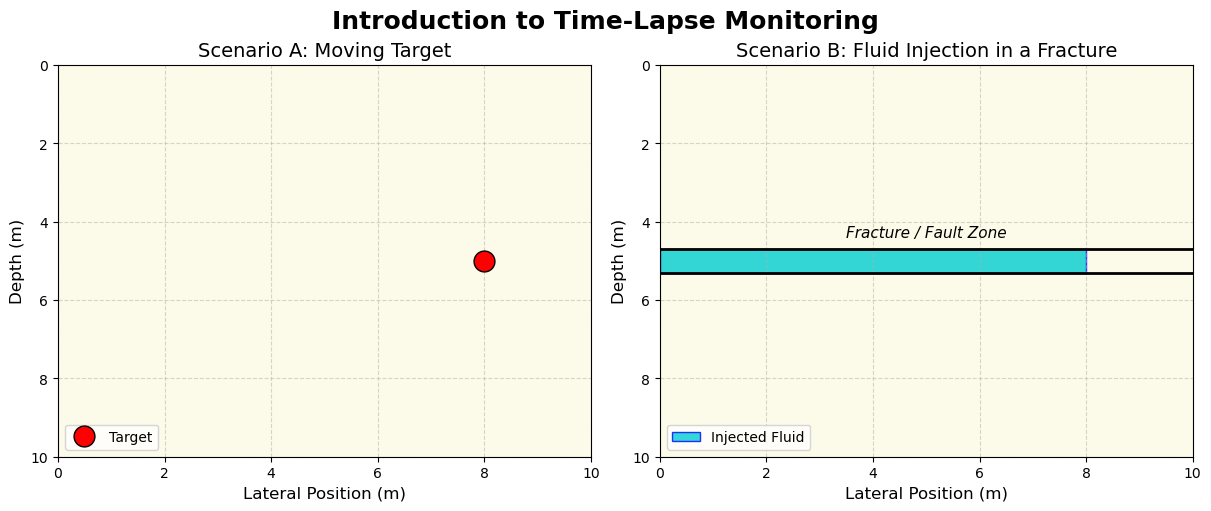

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FFMpegWriter, FuncAnimation

# ==========================================
# 1. Setup Parameters
# ==========================================
num_frames = 60
x_start = 2.0
x_end = 8.0
x_positions = np.linspace(x_start, x_end, num_frames)
z_depth = 5.0

# ==========================================
# 2. Figure Setup
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle('Introduction to Time-Lapse Monitoring', fontsize=18, fontweight='bold')

# --- Panel 1: Moving Point Scatterer ---
ax1.set_title('Scenario A: Moving Target', fontsize=14)
ax1.set_xlim(0, 10)
ax1.set_ylim(10, 0) # Inverted depth axis
ax1.set_xlabel('Lateral Position (m)', fontsize=12)
ax1.set_ylabel('Depth (m)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

# Add a light background color to represent the subsurface
ax1.axhspan(0, 10, facecolor='#f0e68c', alpha=0.2) 

# Scatterer marker
scatterer, = ax1.plot([], [], 'ro', markersize=15, markeredgecolor='black', label='Target')
ax1.legend(loc='lower left')

# --- Panel 2: Fluid Front in a Fracture ---
ax2.set_title('Scenario B: Fluid Injection in a Fracture', fontsize=14)
ax2.set_xlim(0, 10)
ax2.set_ylim(10, 0)
ax2.set_xlabel('Lateral Position (m)', fontsize=12)
ax2.set_ylabel('Depth (m)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

# Add a light background color to represent the subsurface
ax2.axhspan(0, 10, facecolor='#f0e68c', alpha=0.2)

# Draw the fracture boundaries (static lines)
fracture_top = 4.7
fracture_bottom = 5.3
ax2.plot([0, 10], [fracture_top, fracture_top], 'k-', linewidth=2)
ax2.plot([0, 10], [fracture_bottom, fracture_bottom], 'k-', linewidth=2)
ax2.text(5.0, 4.4, 'Fracture / Fault Zone', ha='center', fontsize=11, style='italic')

# Fluid patch (starts with 0 width)
fluid = patches.Rectangle((0, fracture_top), 0, fracture_bottom - fracture_top, 
                          facecolor='#00ced1', edgecolor='blue', alpha=0.8, label='Injected Fluid')
ax2.add_patch(fluid)
ax2.legend(loc='lower left')

# Time indicator text
time_text = fig.text(0.5, 0.88, '', ha='center', va='top', fontsize=14, 
                     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# ==========================================
# 3. Animation Logic
# ==========================================
def init():
    scatterer.set_data([], [])
    fluid.set_width(0)
    time_text.set_text('')
    return scatterer, fluid, time_text

def update(frame):
    current_x = x_positions[frame]
    
    # Update Scenario A (Scatterer moves to current_x)
    scatterer.set_data([current_x], [z_depth])
    
    # Update Scenario B (Fluid flows from left edge x=0 up to current_x)
    fluid.set_width(current_x)
    
    # Update Time
    time_text.set_text(f'Time-Lapse Step: {frame + 1} / {num_frames}')
    
    return scatterer, fluid, time_text

# Set repeat=False so the animation plays once and stops on the final frame
ani = FuncAnimation(fig, update, frames=num_frames, init_func=init, 
                    blit=True, interval=60, repeat=False)

print("Rendering high-quality animation...")

# 2. Define a high-quality video writer
# A bitrate of 5000-8000 kbps yields a very clean 1080p-style video
high_res_writer = FFMpegWriter(fps=15, bitrate=8000)

# 3. Save the animation with a high DPI
# Note: Increasing DPI and bitrate will increase rendering time and file size
ani.save('Timelapse_Intro_HighRes.mp4', writer=high_res_writer, dpi=300)

print("Export complete!")

plt.show()

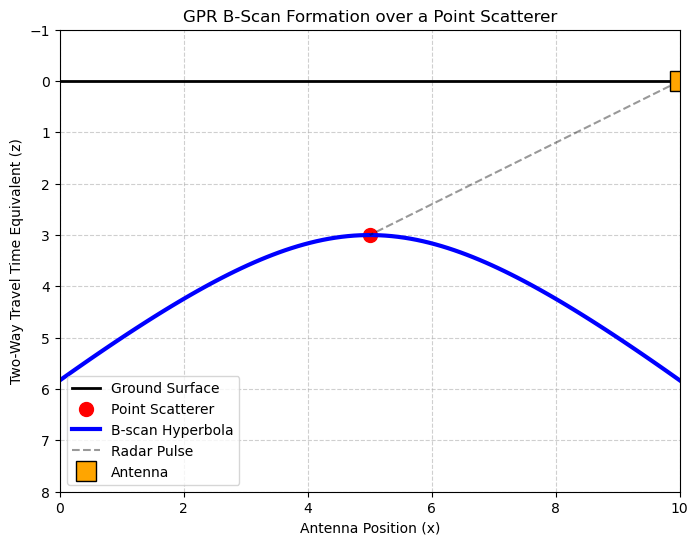

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 1. Setup Parameters
# ==========================================
x_start, x_end = 0, 10                # Survey line (meters)
num_frames = 100                      # Number of steps the antenna takes
x_antenna = np.linspace(x_start, x_end, num_frames)

# Position of the buried point scatterer
x_target = 5.0
z_target = 3.0

# Calculate the hyperbolic travel-time equivalent (depth)
# Using the Pythagorean theorem: distance = sqrt((x - x_target)^2 + z_target^2)
z_trace = np.sqrt((x_antenna - x_target)**2 + z_target**2)

# ==========================================
# 2. Figure Setup
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

# Invert the Y-axis so depth goes down
ax.set_xlim(x_start, x_end)
ax.set_ylim(8, -1) 
ax.set_xlabel('Antenna Position (x)')
ax.set_ylabel('Two-Way Travel Time Equivalent (z)')
ax.set_title('GPR B-Scan Formation over a Point Scatterer')
ax.grid(True, linestyle='--', alpha=0.6)

# Draw the ground surface and the buried target
ax.axhline(0, color='black', linewidth=2, label='Ground Surface')
ax.plot(x_target, z_target, 'ro', markersize=10, label='Point Scatterer')

# Initialize the empty graphical elements that will move
trace_line, = ax.plot([], [], 'b-', linewidth=3, label='B-scan Hyperbola')
pulse_line, = ax.plot([], [], 'k--', alpha=0.4, label='Radar Pulse')
antenna, = ax.plot([], [], 's', color='orange', markersize=15, markeredgecolor='black', label='Antenna')

ax.legend(loc='lower left')

# ==========================================
# 3. Animation Logic
# ==========================================
def init():
    """Initialize a clean frame."""
    trace_line.set_data([], [])
    antenna.set_data([], [])
    pulse_line.set_data([], [])
    return trace_line, antenna, pulse_line

def update(frame):
    """Update the frame for each step of the antenna."""
    current_x = x_antenna[frame]
    
    # 1. Move the antenna box along the surface
    antenna.set_data([current_x], [0])
    
    # 2. Draw the raypath from the antenna to the scatterer
    pulse_line.set_data([current_x, x_target], [0, z_target])
    
    # 3. Progressively draw the hyperbola up to the current antenna position
    trace_line.set_data(x_antenna[:frame+1], z_trace[:frame+1])
    
    return trace_line, antenna, pulse_line

# Create the animation
ani = FuncAnimation(fig, update, frames=num_frames, init_func=init, blit=True, interval=50)

# ==========================================
# 4. Save and Display
# ==========================================
# Uncomment the line below to save it as a GIF for your PowerPoint/Keynote!
ani.save('GPR_Bscan_Animation.gif', writer='pillow', fps=20)

plt.show()

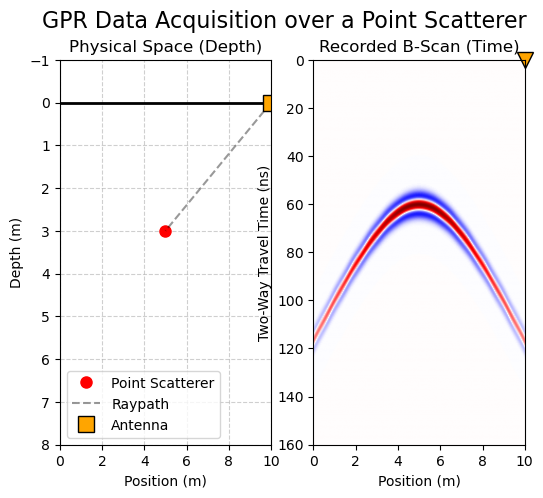

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
x_start, x_end = 0, 10                # Survey line length (meters)
num_traces = 200                      # Number of A-scans (frames)
x_antenna = np.linspace(x_start, x_end, num_traces)

# Physical target location 
x_target = 5.0
z_target = 3.0
velocity = 0.1                        # Speed of light in medium (m/ns)

# Time axis (Two-Way Travel Time in nanoseconds)
t_max = 160                           # Max recording time (ns)
num_samples = 400
time_axis = np.linspace(0, t_max, num_samples)

# Ricker Wavelet Parameters
f_c = 0.1                             # Center frequency in GHz (100 MHz)

def ricker_wavelet(t, f):
    """Generates a Ricker wavelet centered at t=0."""
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

# Pre-calculate the full B-scan 2D matrix
full_b_scan = np.zeros((num_samples, num_traces))

for i, x in enumerate(x_antenna):
    # Calculate physical distance
    distance = np.sqrt((x - x_target)**2 + z_target**2)
    # Calculate Two-Way Travel Time (TWT)
    twt = (2 * distance) / velocity
    
    # Calculate geometric attenuation (2-way spherical spreading ~ 1/r^2)
    # Normalized so the amplitude is exactly 1.0 at the apex (closest approach)
    attenuation = (z_target / distance)**2
    
    # Add an attenuated Ricker wavelet centered at the specific TWT
    full_b_scan[:, i] = ricker_wavelet(time_axis - twt, f_c) * attenuation

# We will fill this blank canvas frame-by-frame during the animation
display_b_scan = np.zeros_like(full_b_scan)

# ==========================================
# 2. Figure Setup
# ==========================================
# Use constrained_layout=True to properly pack the panels and eliminate dead space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 5), constrained_layout=False)
fig.suptitle('GPR Data Acquisition over a Point Scatterer', fontsize=16)

# --- Panel 1: Physical Space (x vs z) ---
ax1.set_xlim(x_start, x_end)
ax1.set_ylim(8, -1)  # Inverted depth axis
ax1.set_xlabel('Position (m)')
ax1.set_ylabel('Depth (m)')
ax1.set_title('Physical Space (Depth)')
ax1.grid(True, linestyle='--', alpha=0.6)

ax1.axhline(0, color='black', linewidth=2)  # Ground surface
ax1.plot(x_target, z_target, 'ro', markersize=8, label='Point Scatterer')

# Moving elements for Panel 1
ray_path, = ax1.plot([], [], 'k--', alpha=0.4, label='Raypath')
antenna1, = ax1.plot([], [], 's', color='orange', markersize=12, markeredgecolor='black', label='Antenna')
ax1.legend(loc='lower left')

# --- Panel 2: Radargram / B-Scan (x vs TWT) ---
ax2.set_xlabel('Position (m)')
ax2.set_ylabel('Two-Way Travel Time (ns)')
ax2.set_title('Recorded B-Scan (Time)')

# Use imshow to display the evolving B-scan matrix
im = ax2.imshow(display_b_scan, aspect='auto', cmap='seismic', 
                extent=[x_start, x_end, t_max, 0], vmin=-1, vmax=1)

# Moving elements for Panel 2
antenna2, = ax2.plot([], [], 'v', color='orange', markersize=12, markeredgecolor='black', clip_on=False)

# ==========================================
# 3. Animation Logic
# ==========================================
def init():
    """Initialize a clean frame."""
    ray_path.set_data([], [])
    antenna1.set_data([], [])
    antenna2.set_data([], [])
    display_b_scan.fill(0)  # Reset the image matrix
    im.set_data(display_b_scan)
    return ray_path, antenna1, antenna2, im

def update(frame):
    """Update the frame for each trace."""
    current_x = x_antenna[frame]
    
    # Update Panel 1 (Physical)
    antenna1.set_data([current_x], [0])
    ray_path.set_data([current_x, x_target], [0, z_target])
    
    # Update Panel 2 (Radargram)
    antenna2.set_data([current_x], [0])  # Marker pointing down at the top of the B-scan
    
    # Copy the current trace from the pre-calculated B-scan into the display matrix
    display_b_scan[:, frame] = full_b_scan[:, frame]
    im.set_data(display_b_scan)
    
    return ray_path, antenna1, antenna2, im

ani = FuncAnimation(fig, update, frames=num_traces, init_func=init, blit=True, interval=50, repeat = False)

# ==========================================
# 4. Save and Display
# ==========================================
# Uncomment the line below to save it as a GIF
ani.save('GPR_Bscan_Wavelet_Animation.gif', writer='pillow', fps=20)

plt.show()

Rendering animation...


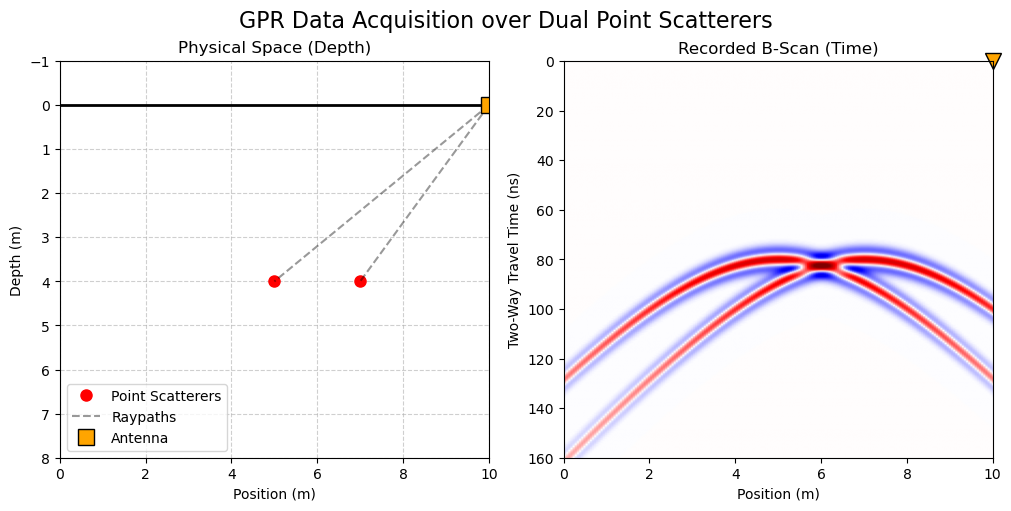

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
x_start, x_end = 0, 10                # Survey line length (meters)
num_traces = 200                      # Number of A-scans (frames)
x_antenna = np.linspace(x_start, x_end, num_traces)

# Physical target locations (using the coordinates from our previous wavefield example)
x_tgt1, z_tgt1 = 5.0, 4.0
x_tgt2, z_tgt2 = 7.0, 4.0
velocity = 0.1                        # Speed of light in medium (m/ns)

# Time axis (Two-Way Travel Time in nanoseconds)
t_max = 160                           # Max recording time (ns)
num_samples = 400
time_axis = np.linspace(0, t_max, num_samples)

# Ricker Wavelet Parameters
f_c = 0.1                             # Center frequency in GHz (100 MHz)

def ricker_wavelet(t, f):
    """Generates a Ricker wavelet centered at t=0."""
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

# Pre-calculate the full B-scan 2D matrix
full_b_scan = np.zeros((num_samples, num_traces))

for i, x in enumerate(x_antenna):
    # Calculate physical distances to both targets
    dist1 = np.sqrt((x - x_tgt1)**2 + z_tgt1**2)
    dist2 = np.sqrt((x - x_tgt2)**2 + z_tgt2**2)
    
    # Calculate Two-Way Travel Time (TWT) for both
    twt1 = (2 * dist1) / velocity
    twt2 = (2 * dist2) / velocity
    
    # Calculate geometric attenuation (2-way spherical spreading ~ 1/r^2)
    att1 = (z_tgt1 / dist1)**2
    att2 = (z_tgt2 / dist2)**2
    
    # Add both attenuated Ricker wavelets (Superposition)
    wave1 = ricker_wavelet(time_axis - twt1, f_c) * att1
    wave2 = ricker_wavelet(time_axis - twt2, f_c) * att2
    
    full_b_scan[:, i] = wave1 + wave2

# We will fill this blank canvas frame-by-frame during the animation
display_b_scan = np.zeros_like(full_b_scan)

# ==========================================
# 2. Figure Setup
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
fig.suptitle('GPR Data Acquisition over Dual Point Scatterers', fontsize=16)

# --- Panel 1: Physical Space (x vs z) ---
ax1.set_xlim(x_start, x_end)
ax1.set_ylim(8, -1)  # Inverted depth axis
ax1.set_xlabel('Position (m)')
ax1.set_ylabel('Depth (m)')
ax1.set_title('Physical Space (Depth)')
ax1.grid(True, linestyle='--', alpha=0.6)

ax1.axhline(0, color='black', linewidth=2)  # Ground surface
# Plot both scatterers
ax1.plot([x_tgt1, x_tgt2], [z_tgt1, z_tgt2], 'ro', markersize=8, label='Point Scatterers')

# Moving elements for Panel 1 (Two raypaths now)
ray_path1, = ax1.plot([], [], 'k--', alpha=0.4)
ray_path2, = ax1.plot([], [], 'k--', alpha=0.4, label='Raypaths')
antenna1, = ax1.plot([], [], 's', color='orange', markersize=12, markeredgecolor='black', label='Antenna')
ax1.legend(loc='lower left')

# --- Panel 2: Radargram / B-Scan (x vs TWT) ---
ax2.set_xlabel('Position (m)')
ax2.set_ylabel('Two-Way Travel Time (ns)')
ax2.set_title('Recorded B-Scan (Time)')

# Max amplitude can be slightly higher due to constructive interference
vmax = np.max(np.abs(full_b_scan)) * 0.8 
im = ax2.imshow(display_b_scan, aspect='auto', cmap='seismic', 
                extent=[x_start, x_end, t_max, 0], vmin=-vmax, vmax=vmax)

# Moving elements for Panel 2
antenna2, = ax2.plot([], [], 'v', color='orange', markersize=12, markeredgecolor='black', clip_on=False)

# ==========================================
# 3. Animation Logic
# ==========================================
def init():
    """Initialize a clean frame."""
    ray_path1.set_data([], [])
    ray_path2.set_data([], [])
    antenna1.set_data([], [])
    antenna2.set_data([], [])
    display_b_scan.fill(0)  
    im.set_data(display_b_scan)
    return ray_path1, ray_path2, antenna1, antenna2, im

def update(frame):
    """Update the frame for each trace."""
    current_x = x_antenna[frame]
    
    # Update Panel 1 (Physical space)
    antenna1.set_data([current_x], [0])
    ray_path1.set_data([current_x, x_tgt1], [0, z_tgt1])
    ray_path2.set_data([current_x, x_tgt2], [0, z_tgt2])
    
    # Update Panel 2 (Radargram)
    antenna2.set_data([current_x], [0])  
    
    # Copy the current trace from the pre-calculated B-scan into the display matrix
    display_b_scan[:, frame] = full_b_scan[:, frame]
    im.set_data(display_b_scan)
    
    return ray_path1, ray_path2, antenna1, antenna2, im

ani = FuncAnimation(fig, update, frames=num_traces, init_func=init, blit=True, interval=50)

# ==========================================
# 4. Save and Display
# ==========================================
print("Rendering animation...")
# Uncomment the line below to save it as a GIF
ani.save('GPR_Dual_Scatterer_Bscan.gif', writer='pillow', fps=20)

plt.show()

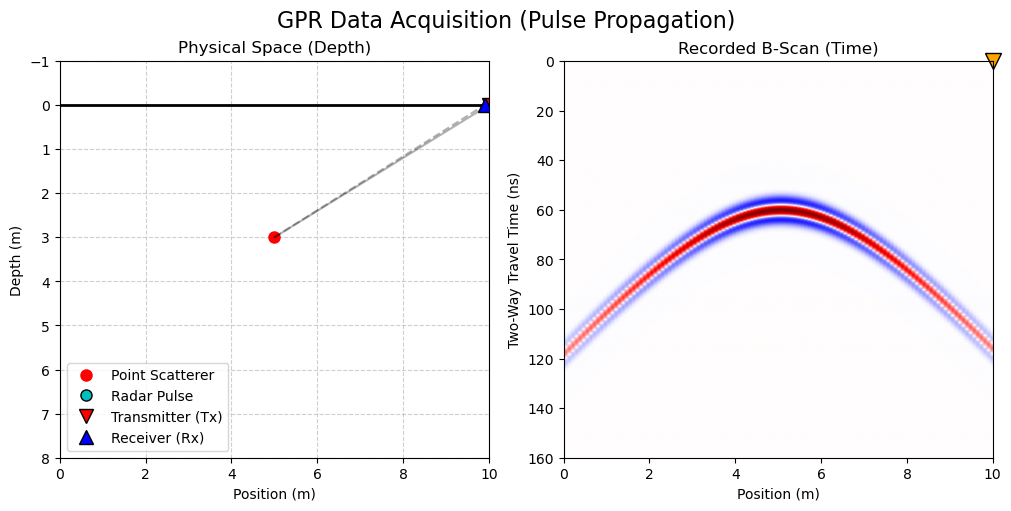

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
x_start, x_end = 0, 10                # Survey line length (meters)
num_traces = 120                       # Fewer traces to keep the animation duration manageable
frames_per_trace = 10                 # Sub-frames to animate the pulse traveling down and up
total_frames = num_traces * frames_per_trace

x_source = np.linspace(x_start, x_end, num_traces)
rx_offset = 0.1                       # Receiver trailing by 10 cm
x_receiver = x_source - rx_offset

# Physical target location
x_target = 5.0
z_target = 3.0
velocity = 0.1                        # Speed of light in medium (m/ns)

# Time axis (Two-Way Travel Time in nanoseconds)
t_max = 160                           # Max recording time (ns)
num_samples = 400
time_axis = np.linspace(0, t_max, num_samples)

# Ricker Wavelet Parameters
f_c = 0.1                             # Center frequency in GHz (100 MHz)

def ricker_wavelet(t, f):
    """Generates a Ricker wavelet centered at t=0."""
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

# Pre-calculate the full B-scan 2D matrix
full_b_scan = np.zeros((num_samples, num_traces))

for i in range(num_traces):
    # Calculate physical distances for the down and up legs
    dist_down = np.sqrt((x_source[i] - x_target)**2 + z_target**2)
    dist_up = np.sqrt((x_receiver[i] - x_target)**2 + z_target**2)
    
    # Calculate Total Two-Way Travel Time (TWT)
    twt = (dist_down + dist_up) / velocity
    
    # Calculate geometric attenuation (spherical spreading)
    attenuation = (z_target / ((dist_down + dist_up)/2))**2
    
    # Add an attenuated Ricker wavelet centered at the specific TWT
    full_b_scan[:, i] = ricker_wavelet(time_axis - twt, f_c) * attenuation

# Blank canvas for the evolving B-scan
display_b_scan = np.zeros_like(full_b_scan)

# ==========================================
# 2. Figure Setup
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
fig.suptitle('GPR Data Acquisition (Pulse Propagation)', fontsize=16)

# --- Panel 1: Physical Space (x vs z) ---
ax1.set_xlim(x_start, x_end)
ax1.set_ylim(8, -1)  # Inverted depth axis
ax1.set_xlabel('Position (m)')
ax1.set_ylabel('Depth (m)')
ax1.set_title('Physical Space (Depth)')
ax1.grid(True, linestyle='--', alpha=0.6)

ax1.axhline(0, color='black', linewidth=2)  # Ground surface
ax1.plot(x_target, z_target, 'ro', markersize=8, label='Point Scatterer')

# Moving elements for Panel 1 (Tx, Rx, Raypaths, and the Pulse)
ray_down, = ax1.plot([], [], 'k-', alpha=0.3)
ray_up, = ax1.plot([], [], 'k--', alpha=0.3)
pulse_dot, = ax1.plot([], [], 'co', markersize=8, markeredgecolor='k', zorder=5, label='Radar Pulse')
tx_antenna, = ax1.plot([], [], 'v', color='red', markersize=10, markeredgecolor='black', label='Transmitter (Tx)')
rx_antenna, = ax1.plot([], [], '^', color='blue', markersize=10, markeredgecolor='black', label='Receiver (Rx)')
ax1.legend(loc='lower left')

# --- Panel 2: Radargram / B-Scan (x vs TWT) ---
ax2.set_xlabel('Position (m)')
ax2.set_ylabel('Two-Way Travel Time (ns)')
ax2.set_title('Recorded B-Scan (Time)')

# Display the evolving B-scan matrix
im = ax2.imshow(display_b_scan, aspect='auto', cmap='seismic', 
                extent=[x_start, x_end, t_max, 0], vmin=-1, vmax=1)

# Progress indicator mapping the antenna position to the radargram
scan_cursor, = ax2.plot([], [], 'v', color='orange', markersize=12, markeredgecolor='black', clip_on=False)

# ==========================================
# 3. Animation Logic
# ==========================================
def init():
    """Initialize a clean frame."""
    ray_down.set_data([], [])
    ray_up.set_data([], [])
    pulse_dot.set_data([], [])
    tx_antenna.set_data([], [])
    rx_antenna.set_data([], [])
    scan_cursor.set_data([], [])
    display_b_scan.fill(0) 
    im.set_data(display_b_scan)
    return ray_down, ray_up, pulse_dot, tx_antenna, rx_antenna, scan_cursor, im

def update(frame):
    """Update the frame for each sub-step."""
    # Determine which trace we are on, and where the pulse is in its journey
    trace_idx = frame // frames_per_trace
    sub_idx = frame % frames_per_trace
    
    ctx = x_source[trace_idx]
    crx = x_receiver[trace_idx]
    
    # Update Antenna positions (Static for the duration of the sub-frames)
    tx_antenna.set_data([ctx], [0])
    rx_antenna.set_data([crx], [0])
    scan_cursor.set_data([ctx], [0])
    
    # Calculate pulse propagation position
    fraction = sub_idx / (frames_per_trace - 1)
    
    if fraction <= 0.5:
        # Pulse is going DOWN (Tx -> Target)
        f_down = fraction * 2
        px = ctx + f_down * (x_target - ctx)
        pz = 0 + f_down * (z_target - 0)
        
        # Draw only the down raypath
        ray_down.set_data([ctx, x_target], [0, z_target])
        ray_up.set_data([], [])
    else:
        # Pulse is going UP (Target -> Rx)
        f_up = (fraction - 0.5) * 2
        px = x_target + f_up * (crx - x_target)
        pz = z_target + f_up * (0 - z_target)
        
        # Keep down raypath, draw up raypath
        ray_down.set_data([ctx, x_target], [0, z_target])
        ray_up.set_data([x_target, crx], [z_target, 0])
        
    pulse_dot.set_data([px], [pz])
    
    # Update the B-scan ONLY when the pulse arrives back at the receiver
    if sub_idx == frames_per_trace - 1:
        display_b_scan[:, trace_idx] = full_b_scan[:, trace_idx]
        im.set_data(display_b_scan)
        pulse_dot.set_data([], []) # Hide the pulse momentarily upon arrival
        
    return ray_down, ray_up, pulse_dot, tx_antenna, rx_antenna, scan_cursor, im

# Interval of 40ms gives a smooth 25 frames per second
ani = FuncAnimation(fig, update, frames=total_frames, init_func=init, blit=True, interval=40)

# ==========================================
# 4. Save and Display
# ==========================================
# Uncomment to export for the presentation slide
writer = PillowWriter(fps=25)
ani.save('GPR_Pulse_Propagation.gif', writer=writer)

plt.show()

Rendering animation... This is doing a 2D field calculation per frame, so it may take ~10-20 seconds.


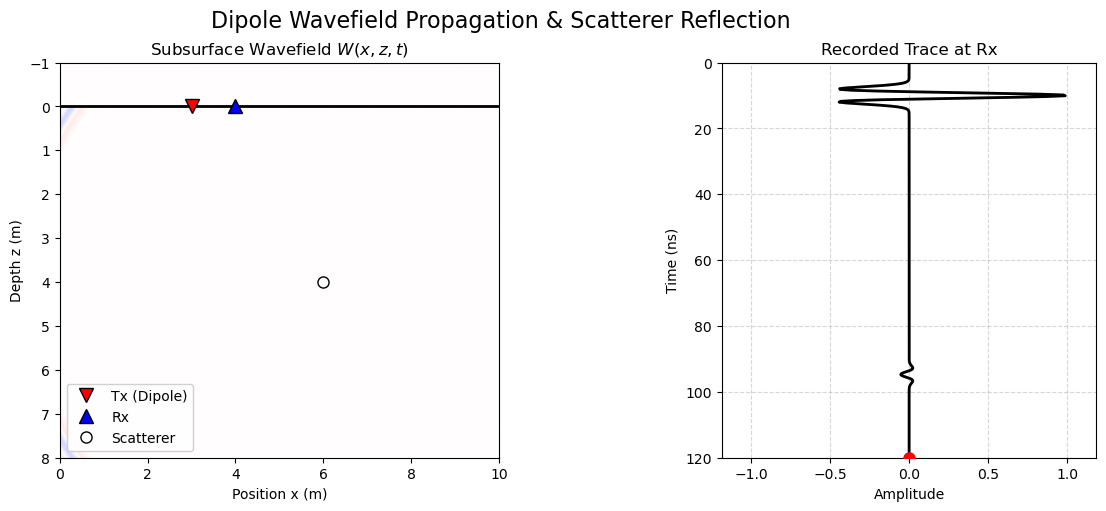

In [2]:
import numpy as np
# import matplotlib.subplots as subplots
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
# Space definitions
x_start, x_end = 0, 10
z_start, z_end = -1, 8  # -1 to show a bit of "air" above the ground
nx, nz = 250, 200
x = np.linspace(x_start, x_end, nx)
z = np.linspace(z_start, z_end, nz)
X, Z = np.meshgrid(x, z)

# Geometry
x_tx, z_tx = 3.0, 0.0      # Transmitter (Dipole)
x_rx, z_rx = 4.0, 0.0      # Receiver
x_tgt, z_tgt = 6.0, 4.0    # Point Scatterer

# Medium properties
v = 0.1                    # Velocity (m/ns)
f_c = 0.2                  # Center frequency (GHz) - higher for sharper visual waves

# Time definitions
t_max = 120                # Total simulation time (ns)
num_frames = 100
time_steps = np.linspace(0, t_max, num_frames)

# ==========================================
# 2. Wavefield & A-Scan Functions
# ==========================================
def ricker(t, f):
    """Normalized Ricker wavelet."""
    tau = np.pi * f * t
    return (1 - 2 * tau**2) * np.exp(-tau**2)

# Calculate distances
# Distance from Tx to everywhere in the grid
R_tx = np.sqrt((X - x_tx)**2 + (Z - z_tx)**2) + 1e-6 
# Distance from Target to everywhere in the grid
R_tgt = np.sqrt((X - x_tgt)**2 + (Z - z_tgt)**2) + 1e-6
# Distance from Tx directly to Target
Dist_tx_to_tgt = np.sqrt((x_tgt - x_tx)**2 + (z_tgt - z_tx)**2)

# Dipole Directivity (Simplified): Max energy downwards (z-direction), zero along the surface
# We clamp Z to be >= 0 so the wave only propagates into the ground
Z_ground = np.clip(Z, 0, None)
directivity_tx = Z_ground / R_tx

# Pre-calculate the A-Scan at the Receiver for Panel 2
# Time array for a highly sampled trace
t_trace = np.linspace(0, t_max, 500)
dist_tx_to_rx = np.sqrt((x_rx - x_tx)**2 + (z_rx - z_tx)**2)
dist_tgt_to_rx = np.sqrt((x_rx - x_tgt)**2 + (z_rx - z_tgt)**2)

# Direct wave arriving at Rx (attenuated by distance)
trace_direct = ricker(t_trace - dist_tx_to_rx/v, f_c) * (1.0 / dist_tx_to_rx)
# Reflected wave arriving at Rx (attenuated by two-way geometric spreading and reflection coefficient)
reflection_coef = -0.5
trace_reflected = ricker(t_trace - (Dist_tx_to_tgt + dist_tgt_to_rx)/v, f_c) * (1.0 / (Dist_tx_to_tgt + dist_tgt_to_rx)) * reflection_coef
# Total A-scan trace
a_scan = trace_direct + trace_reflected

# ==========================================
# 3. Figure Setup
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [2, 1]}, constrained_layout=True)
fig.suptitle('Dipole Wavefield Propagation & Scatterer Reflection', fontsize=16)

# --- Panel 1: 2D Wavefield ---
ax1.set_title('Subsurface Wavefield $W(x, z, t)$')
ax1.set_xlabel('Position x (m)')
ax1.set_ylabel('Depth z (m)')
ax1.set_xlim(x_start, x_end)
ax1.set_ylim(z_end, z_start) # Invert depth axis

# Draw ground line and markers
ax1.axhline(0, color='black', linewidth=2, linestyle='-')
ax1.plot(x_tx, z_tx, 'v', color='red', markersize=10, markeredgecolor='k', label='Tx (Dipole)')
ax1.plot(x_rx, z_rx, '^', color='blue', markersize=10, markeredgecolor='k', label='Rx')
ax1.plot(x_tgt, z_tgt, 'wo', markersize=8, markeredgecolor='k', label='Scatterer')
ax1.legend(loc='lower left', framealpha=0.9)

# Wavefield image container
# vmin/vmax set a tight color threshold to make the wavefronts pop visually
im_wave = ax1.imshow(np.zeros_like(X), extent=[x_start, x_end, z_end, z_start], 
                     cmap='seismic', vmin=-0.15, vmax=0.15, aspect='equal')

# --- Panel 2: Recorded A-Scan ---
ax2.set_title('Recorded Trace at Rx')
ax2.set_xlabel('Amplitude')
ax2.set_ylabel('Time (ns)')
ax2.set_ylim(t_max, 0) # Invert time axis to match depth visually
ax2.set_xlim(-np.max(np.abs(a_scan))*1.2, np.max(np.abs(a_scan))*1.2)
ax2.grid(True, linestyle='--', alpha=0.5)

# Plot static full trace in light grey, and a dynamic solid line
ax2.plot(a_scan, t_trace, color='grey', alpha=0.3, linewidth=2)
trace_line, = ax2.plot([], [], color='black', linewidth=2)
time_dot, = ax2.plot([], [], 'ro', markersize=8, zorder=5)

# ==========================================
# 4. Animation Logic
# ==========================================
def update(frame):
    t = time_steps[frame]
    
    # 1. Calculate Primary Wave from Tx (Traveling outward)
    # The geometric spreading is approx 1/sqrt(R) in 2D, but we use 1/(R+0.5) to avoid infinite amplitudes near the source
    W_direct = ricker(t - R_tx/v, f_c) * directivity_tx / (R_tx + 0.5)
    
    # 2. Calculate Secondary Wave from Target (Only exists after direct wave hits the target)
    t_hit = Dist_tx_to_tgt / v
    W_scattered = np.zeros_like(X)
    
    if t > t_hit:
        # The scatterer acts as an isotropic Huygens source
        W_scattered = ricker(t - (t_hit + R_tgt/v), f_c) * reflection_coef / (R_tgt + 0.5)
        # Apply an extra attenuation factor so the reflection isn't unrealistically bright compared to the source
        W_scattered *= (1.0 / (Dist_tx_to_tgt + 0.5))

    # Total Wavefield
    W_total = W_direct + W_scattered
    
    # Mask out the "air" above z=0 so the wave only propagates downward
    W_total[Z < 0] = 0
    im_wave.set_data(W_total)
    
    # Update Trace Panel
    # Find the index in the highly sampled trace array closest to the current time
    idx = (np.abs(t_trace - t)).argmin()
    trace_line.set_data(a_scan[:idx], t_trace[:idx])
    time_dot.set_data([a_scan[idx]], [t])
    
    return im_wave, trace_line, time_dot

ani = FuncAnimation(fig, update, frames=num_frames, interval=40, blit=True)

print("Rendering animation... This is doing a 2D field calculation per frame, so it may take ~10-20 seconds.")

# Uncomment to export for your slide presentation:
writer = PillowWriter(fps=25)
ani.save('Dipole_Wavefield_Scattering.gif', writer=writer)

plt.show()

Rendering dual-scatterer animation... This will take a moment.


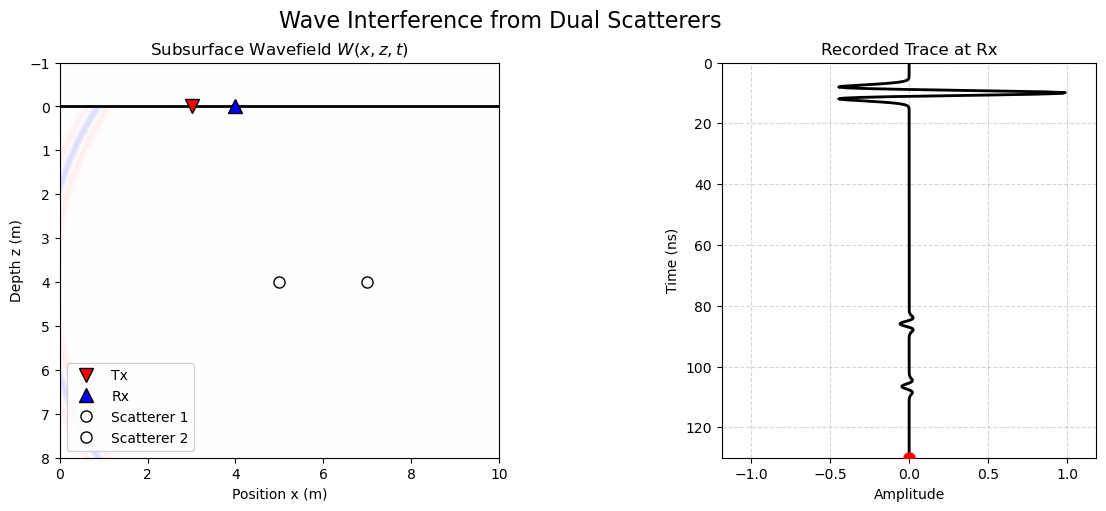

In [4]:
import numpy as np
# import matplotlib.subplots as subplots
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
# Space definitions
x_start, x_end = 0, 10
z_start, z_end = -1, 8  # -1 to show a bit of "air" above the ground
nx, nz = 250, 200
x = np.linspace(x_start, x_end, nx)
z = np.linspace(z_start, z_end, nz)
X, Z = np.meshgrid(x, z)

# Geometry
x_tx, z_tx = 3.0, 0.0        # Transmitter (Dipole)
x_rx, z_rx = 4.0, 0.0        # Receiver
x_tgt1, z_tgt1 = 5.0, 4.0    # Scatterer 1
x_tgt2, z_tgt2 = 7.0, 4.0    # Scatterer 2 (Laterally displaced)

# Medium properties
v = 0.1                      # Velocity (m/ns)
f_c = 0.2                    # Center frequency (GHz)

# Time definitions
t_max = 130                  # Extended slightly to ensure both reflections fully record
num_frames = 110
time_steps = np.linspace(0, t_max, num_frames)

# ==========================================
# 2. Wavefield & A-Scan Functions
# ==========================================
def ricker(t, f):
    """Normalized Ricker wavelet."""
    tau = np.pi * f * t
    return (1 - 2 * tau**2) * np.exp(-tau**2)

# Calculate distances in the grid
R_tx = np.sqrt((X - x_tx)**2 + (Z - z_tx)**2) + 1e-6 
R_tgt1 = np.sqrt((X - x_tgt1)**2 + (Z - z_tgt1)**2) + 1e-6
R_tgt2 = np.sqrt((X - x_tgt2)**2 + (Z - z_tgt2)**2) + 1e-6

# Specific raypath distances
Dist_tx_to_tgt1 = np.sqrt((x_tgt1 - x_tx)**2 + (z_tgt1 - z_tx)**2)
Dist_tx_to_tgt2 = np.sqrt((x_tgt2 - x_tx)**2 + (z_tgt2 - z_tx)**2)

# Dipole Directivity (Max energy downwards)
Z_ground = np.clip(Z, 0, None)
directivity_tx = Z_ground / R_tx

# Pre-calculate the A-Scan at the Receiver for Panel 2
t_trace = np.linspace(0, t_max, 500)
dist_tx_to_rx = np.sqrt((x_rx - x_tx)**2 + (z_rx - z_tx)**2)
dist_tgt1_to_rx = np.sqrt((x_rx - x_tgt1)**2 + (z_rx - z_tgt1)**2)
dist_tgt2_to_rx = np.sqrt((x_rx - x_tgt2)**2 + (z_rx - z_tgt2)**2)

reflection_coef = -0.5

# Calculate individual trace components
trace_direct = ricker(t_trace - dist_tx_to_rx/v, f_c) * (1.0 / dist_tx_to_rx)
trace_reflected1 = ricker(t_trace - (Dist_tx_to_tgt1 + dist_tgt1_to_rx)/v, f_c) * (1.0 / (Dist_tx_to_tgt1 + dist_tgt1_to_rx)) * reflection_coef
trace_reflected2 = ricker(t_trace - (Dist_tx_to_tgt2 + dist_tgt2_to_rx)/v, f_c) * (1.0 / (Dist_tx_to_tgt2 + dist_tgt2_to_rx)) * reflection_coef

# Total A-scan trace includes direct wave and both reflections
a_scan = trace_direct + trace_reflected1 + trace_reflected2

# ==========================================
# 3. Figure Setup
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [2, 1]}, constrained_layout=True)
fig.suptitle('Wave Interference from Dual Scatterers', fontsize=16)

# --- Panel 1: 2D Wavefield ---
ax1.set_title('Subsurface Wavefield $W(x, z, t)$')
ax1.set_xlabel('Position x (m)')
ax1.set_ylabel('Depth z (m)')
ax1.set_xlim(x_start, x_end)
ax1.set_ylim(z_end, z_start) 

# Draw ground line and markers
ax1.axhline(0, color='black', linewidth=2, linestyle='-')
ax1.plot(x_tx, z_tx, 'v', color='red', markersize=10, markeredgecolor='k', label='Tx')
ax1.plot(x_rx, z_rx, '^', color='blue', markersize=10, markeredgecolor='k', label='Rx')
ax1.plot(x_tgt1, z_tgt1, 'wo', markersize=8, markeredgecolor='k', label='Scatterer 1')
ax1.plot(x_tgt2, z_tgt2, 'wo', markersize=8, markeredgecolor='k', label='Scatterer 2')
ax1.legend(loc='lower left', framealpha=0.9)

im_wave = ax1.imshow(np.zeros_like(X), extent=[x_start, x_end, z_end, z_start], 
                     cmap='seismic', vmin=-0.15, vmax=0.15, aspect='equal')

# --- Panel 2: Recorded A-Scan ---
ax2.set_title('Recorded Trace at Rx')
ax2.set_xlabel('Amplitude')
ax2.set_ylabel('Time (ns)')
ax2.set_ylim(t_max, 0) 
ax2.set_xlim(-np.max(np.abs(a_scan))*1.2, np.max(np.abs(a_scan))*1.2)
ax2.grid(True, linestyle='--', alpha=0.5)

ax2.plot(a_scan, t_trace, color='grey', alpha=0.3, linewidth=2)
trace_line, = ax2.plot([], [], color='black', linewidth=2)
time_dot, = ax2.plot([], [], 'ro', markersize=8, zorder=5)

# ==========================================
# 4. Animation Logic
# ==========================================
def update(frame):
    t = time_steps[frame]
    
    # 1. Direct Wave
    W_direct = ricker(t - R_tx/v, f_c) * directivity_tx / (R_tx + 0.5)
    
    # 2. Scatterer 1 Reflection
    t_hit1 = Dist_tx_to_tgt1 / v
    W_scattered1 = np.zeros_like(X)
    if t > t_hit1:
        W_scattered1 = ricker(t - (t_hit1 + R_tgt1/v), f_c) * reflection_coef / (R_tgt1 + 0.5)
        W_scattered1 *= (1.0 / (Dist_tx_to_tgt1 + 0.5))

    # 3. Scatterer 2 Reflection
    t_hit2 = Dist_tx_to_tgt2 / v
    W_scattered2 = np.zeros_like(X)
    if t > t_hit2:
        W_scattered2 = ricker(t - (t_hit2 + R_tgt2/v), f_c) * reflection_coef / (R_tgt2 + 0.5)
        W_scattered2 *= (1.0 / (Dist_tx_to_tgt2 + 0.5))

    # Total Wavefield Superposition
    W_total = W_direct + W_scattered1 + W_scattered2
    
    # Mask out the "air" 
    W_total[Z < 0] = 0
    im_wave.set_data(W_total)
    
    # Update Trace Panel
    idx = (np.abs(t_trace - t)).argmin()
    trace_line.set_data(a_scan[:idx], t_trace[:idx])
    time_dot.set_data([a_scan[idx]], [t])
    
    return im_wave, trace_line, time_dot

ani = FuncAnimation(fig, update, frames=num_frames, interval=40, blit=True)

print("Rendering dual-scatterer animation... This will take a moment.")

# Uncomment to export:
writer = PillowWriter(fps=25)
ani.save('Dual_Scatterer_Wavefield.gif', writer=writer)

plt.show()

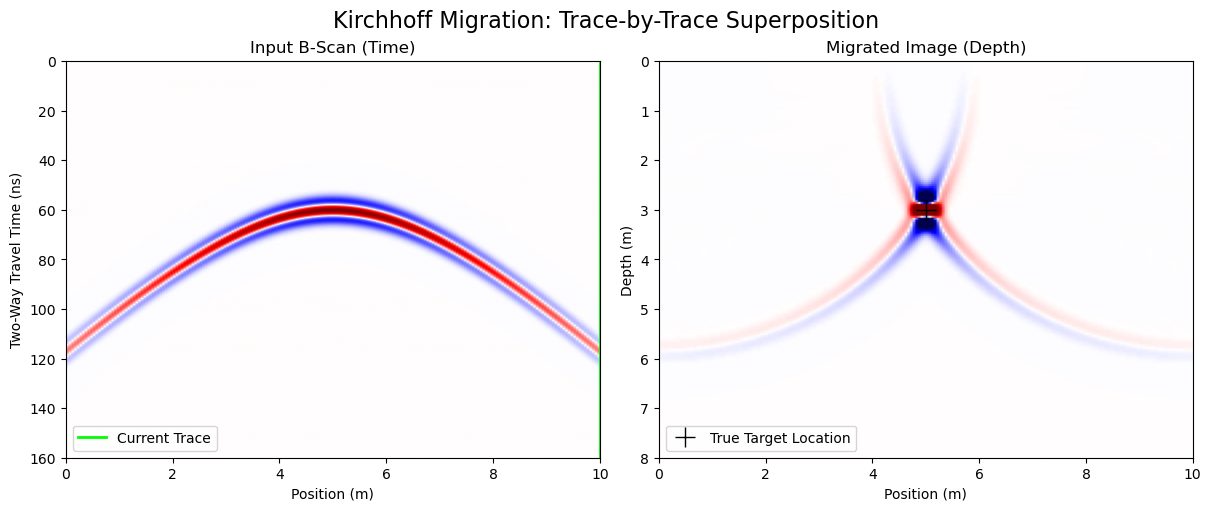

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 1. Setup Parameters & Generate B-Scan
# ==========================================
nx, nz = 200, 200
x_start, x_end = 0, 10                 # Survey line (m)
z_start, z_end = 0, 8                  # Depth range (m)
v = 0.1                                # Velocity (m/ns)

x_pos = np.linspace(x_start, x_end, nx)
z_pos = np.linspace(z_start, z_end, nz)

# Target location
x_target = 5.0
z_target = 3.0

# Time axis setup
t_max = 160 
nt = 400
time_axis = np.linspace(0, t_max, nt)
f_c = 0.1 # Center frequency of Ricker wavelet

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

# Create the unmigrated B-scan
b_scan = np.zeros((nt, nx))
for i, x in enumerate(x_pos):
    dist = np.sqrt((x - x_target)**2 + z_target**2)
    twt = 2 * dist / v
    attenuation = (z_target / dist)**2
    b_scan[:, i] = ricker(time_axis - twt, f_c) * attenuation

# ==========================================
# 2. Setup Migration Grid
# ==========================================
# Create a 2D grid of the subsurface for migration
X, Z = np.meshgrid(x_pos, z_pos)

# Initialize the empty migrated image
migrated_image = np.zeros((nz, nx))

# ==========================================
# 3. Figure Setup
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle('Kirchhoff Migration: Trace-by-Trace Superposition', fontsize=16)

# --- Panel 1: Unmigrated B-Scan ---
ax1.set_title('Input B-Scan (Time)')
ax1.set_xlabel('Position (m)')
ax1.set_ylabel('Two-Way Travel Time (ns)')
im1 = ax1.imshow(b_scan, aspect='auto', cmap='seismic', 
                 extent=[x_start, x_end, t_max, 0], vmin=-1, vmax=1)

# A vertical line to show which trace is currently being processed
current_trace_line = ax1.axvline(x_start, color='lime', linewidth=2, label='Current Trace')
ax1.legend(loc='lower left')

# --- Panel 2: Migrated Image ---
ax2.set_title('Migrated Image (Depth)')
ax2.set_xlabel('Position (m)')
ax2.set_ylabel('Depth (m)')
ax2.set_xlim(x_start, x_end)
ax2.set_ylim(z_end, z_start) # Inverted depth axis

# We set vmax to ~15 because amplitudes will stack constructively up to roughly that value
im2 = ax2.imshow(migrated_image, aspect='auto', cmap='seismic', 
                 extent=[x_start, x_end, z_end, z_start], vmin=-15, vmax=15)
                 
# Draw a crosshair at the true target location to watch the PSF collapse onto it
ax2.plot(x_target, z_target, 'k+', markersize=15, label='True Target Location')
ax2.legend(loc='lower left')

# ==========================================
# 4. Animation Logic
# ==========================================
def init():
    current_trace_line.set_xdata([x_start])
    migrated_image.fill(0)
    im2.set_data(migrated_image)
    return current_trace_line, im2

def update(frame):
    global migrated_image
    
    # 1. Get the position and data of the current trace
    x_tr = x_pos[frame]
    trace_data = b_scan[:, frame]
    
    # 2. Update the vertical line on the B-scan
    current_trace_line.set_xdata([x_tr])
    
    # 3. Calculate distance and travel time from this trace to EVERY pixel in the subsurface
    distance = np.sqrt((X - x_tr)**2 + Z**2)
    distance[distance == 0] = 1e-6  # Prevent division by zero
    t_grid = 2 * distance / v
    
    # 4. Kirchhoff mapping: extract amplitudes from the trace at the calculated times
    # We interpolate the 1D trace data onto the 2D grid of travel times
    contribution = np.interp(t_grid.ravel(), time_axis, trace_data).reshape(nz, nx)
    
    # Add an obliquity/directivity factor (Z / distance) to suppress horizontal artifacts
    obliquity = Z / distance
    contribution *= obliquity
    
    # 5. Superpose (add) this trace's contribution to the total migrated image
    migrated_image += contribution
    
    # Update the plot
    im2.set_data(migrated_image)
    
    return current_trace_line, im2

# Run the animation
ani = FuncAnimation(fig, update, frames=nx, init_func=init, blit=True, interval=50)

# ==========================================
# 5. Save and Display
# ==========================================
# Uncomment to save the animation
ani.save('Kirchhoff_Migration_Collapse.gif', writer='pillow', fps=15)

plt.show()

Rendering animation...


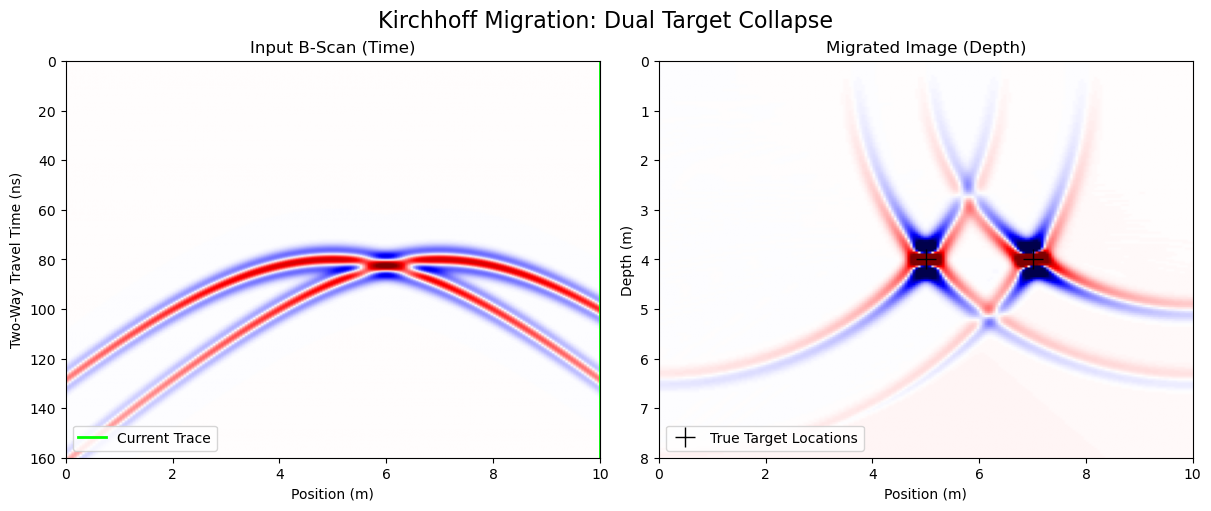

In [23]:
import numpy as np
# import matplotlib.subplots as subplots
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ==========================================
# 1. Setup Parameters & Generate B-Scan
# ==========================================
nx, nz = 200, 200
x_start, x_end = 0, 10                 # Survey line (m)
z_start, z_end = 0, 8                  # Depth range (m)
v = 0.1                                # Velocity (m/ns)

x_pos = np.linspace(x_start, x_end, nx)
z_pos = np.linspace(z_start, z_end, nz)

# Target locations (Dual Scatterers)
x_tgt1, z_tgt1 = 5.0, 4.0
x_tgt2, z_tgt2 = 7.0, 4.0

# Time axis setup
t_max = 160 
nt = 400
time_axis = np.linspace(0, t_max, nt)
f_c = 0.1 # Center frequency of Ricker wavelet

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

# Create the unmigrated B-scan (Superposition of both targets)
b_scan = np.zeros((nt, nx))
for i, x in enumerate(x_pos):
    # Target 1
    dist1 = np.sqrt((x - x_tgt1)**2 + z_tgt1**2)
    twt1 = 2 * dist1 / v
    att1 = (z_tgt1 / dist1)**2
    
    # Target 2
    dist2 = np.sqrt((x - x_tgt2)**2 + z_tgt2**2)
    twt2 = 2 * dist2 / v
    att2 = (z_tgt2 / dist2)**2
    
    # Add both to the trace
    b_scan[:, i] = (ricker(time_axis - twt1, f_c) * att1) + \
                   (ricker(time_axis - twt2, f_c) * att2)

# ==========================================
# 2. Setup Migration Grid
# ==========================================
# Create a 2D grid of the subsurface for migration
X, Z = np.meshgrid(x_pos, z_pos)

# Initialize the empty migrated image
migrated_image = np.zeros((nz, nx))

# ==========================================
# 3. Figure Setup
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle('Kirchhoff Migration: Dual Target Collapse', fontsize=16)

# --- Panel 1: Unmigrated B-Scan ---
ax1.set_title('Input B-Scan (Time)')
ax1.set_xlabel('Position (m)')
ax1.set_ylabel('Two-Way Travel Time (ns)')
# Slightly widened vmin/vmax to account for constructive interference
vmax_bscan = np.max(np.abs(b_scan)) * 0.8
im1 = ax1.imshow(b_scan, aspect='auto', cmap='seismic', 
                 extent=[x_start, x_end, t_max, 0], vmin=-vmax_bscan, vmax=vmax_bscan)

# A vertical line to show which trace is currently being processed
current_trace_line = ax1.axvline(x_start, color='lime', linewidth=2, label='Current Trace')
ax1.legend(loc='lower left')

# --- Panel 2: Migrated Image ---
ax2.set_title('Migrated Image (Depth)')
ax2.set_xlabel('Position (m)')
ax2.set_ylabel('Depth (m)')
ax2.set_xlim(x_start, x_end)
ax2.set_ylim(z_end, z_start) # Inverted depth axis

# We set vmax to ~15 because amplitudes will stack constructively up to roughly that value
im2 = ax2.imshow(migrated_image, aspect='auto', cmap='seismic', 
                 extent=[x_start, x_end, z_end, z_start], vmin=-15, vmax=15)
                 
# Draw crosshairs at the true target locations to watch the PSFs collapse
ax2.plot([x_tgt1, x_tgt2], [z_tgt1, z_tgt2], 'k+', markersize=15, label='True Target Locations')
ax2.legend(loc='lower left')

# ==========================================
# 4. Animation Logic
# ==========================================
def init():
    current_trace_line.set_xdata([x_start])
    migrated_image.fill(0)
    im2.set_data(migrated_image)
    return current_trace_line, im2

def update(frame):
    global migrated_image
    
    # 1. Get the position and data of the current trace
    x_tr = x_pos[frame]
    trace_data = b_scan[:, frame]
    
    # 2. Update the vertical line on the B-scan
    current_trace_line.set_xdata([x_tr])
    
    # 3. Calculate distance and travel time from this trace to EVERY pixel in the subsurface
    distance = np.sqrt((X - x_tr)**2 + Z**2)
    distance[distance == 0] = 1e-6  # Prevent division by zero
    t_grid = 2 * distance / v
    
    # 4. Kirchhoff mapping: extract amplitudes from the trace at the calculated times
    # We interpolate the 1D trace data onto the 2D grid of travel times
    contribution = np.interp(t_grid.ravel(), time_axis, trace_data).reshape(nz, nx)
    
    # Add an obliquity/directivity factor (Z / distance) to suppress horizontal artifacts
    obliquity = Z / distance
    contribution *= obliquity
    
    # 5. Superpose (add) this trace's contribution to the total migrated image
    migrated_image += contribution
    
    # Update the plot
    im2.set_data(migrated_image)
    
    return current_trace_line, im2

# Run the animation
ani = FuncAnimation(fig, update, frames=nx, init_func=init, blit=True, interval=50)

# ==========================================
# 5. Save and Display
# ==========================================
print("Rendering animation...")
# Uncomment to save the animation
ani.save('Kirchhoff_Migration_Dual_Target.gif', writer='pillow', fps=15)

plt.show()

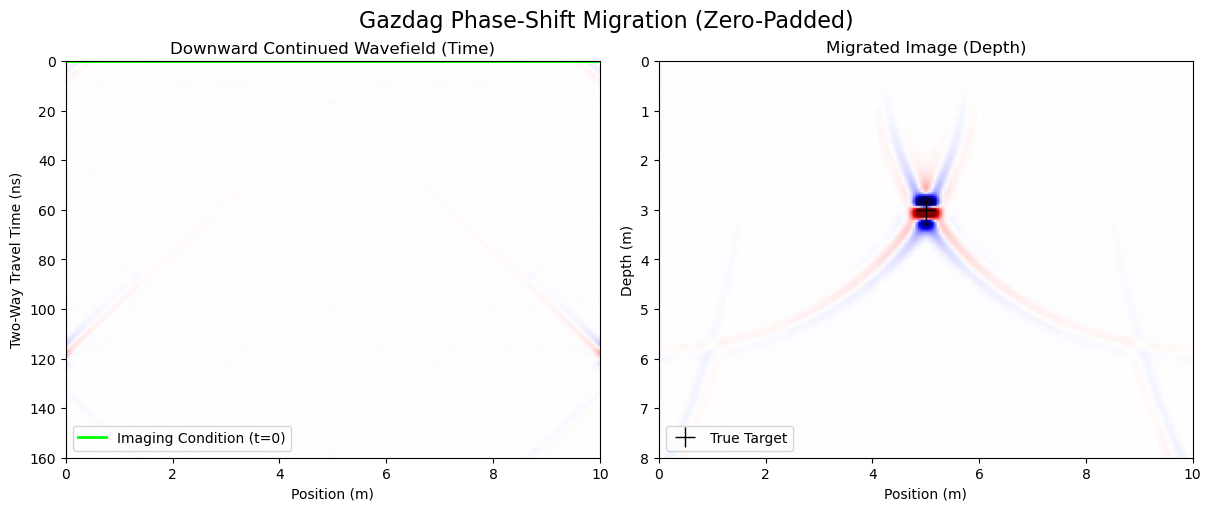

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 1. Setup Parameters & Generate B-Scan
# ==========================================
nx, nz = 200, 200
x_start, x_end = 0, 10
z_start, z_end = 0, 8
v = 0.1             
v_mig = v / 2       

x_pos = np.linspace(x_start, x_end, nx)
z_pos = np.linspace(z_start, z_end, nz)
dx = x_pos[1] - x_pos[0]

t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)
dt = time_axis[1] - time_axis[0]

x_target, z_target = 5.0, 3.0
f_c = 0.1

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

b_scan = np.zeros((nt, nx))
for i, x in enumerate(x_pos):
    dist = np.sqrt((x - x_target)**2 + z_target**2)
    b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2

# ==========================================
# 2. Gazdag Setup & ANTI-WRAPPING PADDING
# ==========================================
# Pad the time axis by 100% and spatial axis by 50% on each side
pad_t = nt
pad_x = nx // 2

nt_pad = nt + pad_t
nx_pad = nx + (2 * pad_x)

# Apply padding (zeros) to the B-scan
b_scan_padded = np.pad(b_scan, ((0, pad_t), (pad_x, pad_x)), mode='constant')

# 2D FFT of the PADDED B-scan
P_fk = np.fft.fft2(b_scan_padded)
freqs = np.fft.fftfreq(nt_pad, d=dt)
kxs = np.fft.fftfreq(nx_pad, d=dx)

KX, F = np.meshgrid(kxs, freqs)
omega = 2 * np.pi * F
kx = 2 * np.pi * KX

# Evanescent filter and wavenumber calculation
kz_sq = (omega / v_mig)**2 - kx**2
kz = np.where(kz_sq >= 0, np.sqrt(np.maximum(kz_sq, 0)), 0)
kz = np.sign(omega) * kz 

migrated_image = np.zeros((nz, nx))

# ==========================================
# 3. Figure Setup
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle('Gazdag Phase-Shift Migration (Zero-Padded)', fontsize=16)

ax1.set_title('Downward Continued Wavefield (Time)')
ax1.set_xlabel('Position (m)')
ax1.set_ylabel('Two-Way Travel Time (ns)')
im1 = ax1.imshow(b_scan, aspect='auto', cmap='seismic', extent=[x_start, x_end, t_max, 0], vmin=-1, vmax=1)
t0_line = ax1.axhline(0, color='lime', linewidth=2, label='Imaging Condition (t=0)')
ax1.legend(loc='lower left')

ax2.set_title('Migrated Image (Depth)')
ax2.set_xlabel('Position (m)')
ax2.set_ylabel('Depth (m)')
im2 = ax2.imshow(migrated_image, aspect='auto', cmap='seismic', extent=[x_start, x_end, z_end, z_start], vmin=-1, vmax=1)
ax2.plot(x_target, z_target, 'k+', markersize=15, label='True Target')
ax2.legend(loc='lower left')

# ==========================================
# 4. Animation Logic
# ==========================================
def update(frame):
    current_z = z_pos[frame]
    
    # Phase shift in the padded f-k domain
    phase_shift = np.exp(1j * kz * current_z)
    P_shifted_fk = P_fk * phase_shift
    
    # Transform back to padded space-time domain
    P_shifted_xt_padded = np.real(np.fft.ifft2(P_shifted_fk))
    
    # CROP back to the physical grid dimensions
    P_shifted_xt = P_shifted_xt_padded[0:nt, pad_x:pad_x+nx]
    
    # Imaging condition: t=0 slice
    migrated_image[frame, :] = P_shifted_xt[0, :]
    
    im1.set_data(P_shifted_xt)
    im2.set_data(migrated_image)
    return im1, im2, t0_line

ani = FuncAnimation(fig, update, frames=nz, interval=50, blit=True)
ani.save('Gazdag_Corrected.gif', writer='pillow', fps=20)
plt.show()

Rendering Gazdag animation...


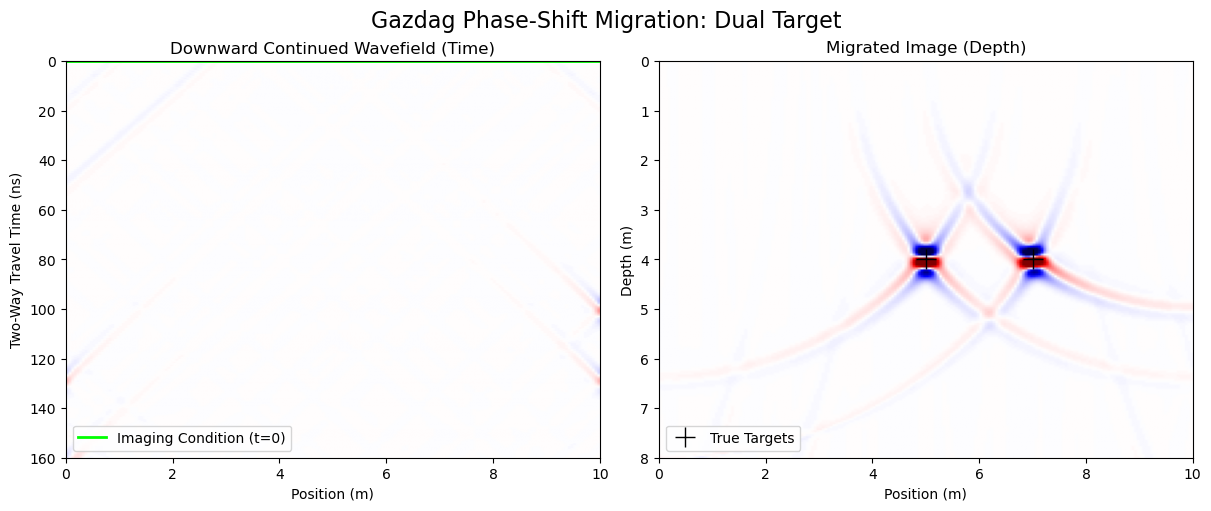

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 1. Setup Parameters & Generate B-Scan
# ==========================================
nx, nz = 200, 200
x_start, x_end = 0, 10
z_start, z_end = 0, 8
v = 0.1             
v_mig = v / 2       

x_pos = np.linspace(x_start, x_end, nx)
z_pos = np.linspace(z_start, z_end, nz)
dx = x_pos[1] - x_pos[0]

t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)
dt = time_axis[1] - time_axis[0]

# Dual Targets
x_tgt1, z_tgt1 = 5.0, 4.0
x_tgt2, z_tgt2 = 7.0, 4.0
f_c = 0.1

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

# Create unmigrated B-scan with both targets
b_scan = np.zeros((nt, nx))
for i, x in enumerate(x_pos):
    dist1 = np.sqrt((x - x_tgt1)**2 + z_tgt1**2)
    dist2 = np.sqrt((x - x_tgt2)**2 + z_tgt2**2)
    
    b_scan[:, i] = (ricker(time_axis - (2 * dist1 / v), f_c) * (z_tgt1 / dist1)**2) + \
                   (ricker(time_axis - (2 * dist2 / v), f_c) * (z_tgt2 / dist2)**2)

# ==========================================
# 2. Gazdag Setup & ANTI-WRAPPING PADDING
# ==========================================
# Pad the time axis by 100% and spatial axis by 50% on each side
pad_t = nt
pad_x = nx // 2

nt_pad = nt + pad_t
nx_pad = nx + (2 * pad_x)

# Apply padding (zeros) to the B-scan
b_scan_padded = np.pad(b_scan, ((0, pad_t), (pad_x, pad_x)), mode='constant')

# 2D FFT of the PADDED B-scan
P_fk = np.fft.fft2(b_scan_padded)
freqs = np.fft.fftfreq(nt_pad, d=dt)
kxs = np.fft.fftfreq(nx_pad, d=dx)

KX, F = np.meshgrid(kxs, freqs)
omega = 2 * np.pi * F
kx = 2 * np.pi * KX

# Evanescent filter and wavenumber calculation
kz_sq = (omega / v_mig)**2 - kx**2
kz = np.where(kz_sq >= 0, np.sqrt(np.maximum(kz_sq, 0)), 0)
kz = np.sign(omega) * kz 

migrated_image = np.zeros((nz, nx))

# ==========================================
# 3. Figure Setup
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle('Gazdag Phase-Shift Migration: Dual Target', fontsize=16)

ax1.set_title('Downward Continued Wavefield (Time)')
ax1.set_xlabel('Position (m)')
ax1.set_ylabel('Two-Way Travel Time (ns)')
vmax_bscan = np.max(np.abs(b_scan)) * 0.8
im1 = ax1.imshow(b_scan, aspect='auto', cmap='seismic', extent=[x_start, x_end, t_max, 0], vmin=-vmax_bscan, vmax=vmax_bscan)
t0_line = ax1.axhline(0, color='lime', linewidth=2, label='Imaging Condition (t=0)')
ax1.legend(loc='lower left')

ax2.set_title('Migrated Image (Depth)')
ax2.set_xlabel('Position (m)')
ax2.set_ylabel('Depth (m)')
im2 = ax2.imshow(migrated_image, aspect='auto', cmap='seismic', extent=[x_start, x_end, z_end, z_start], vmin=-vmax_bscan, vmax=vmax_bscan)
ax2.plot([x_tgt1, x_tgt2], [z_tgt1, z_tgt2], 'k+', markersize=15, label='True Targets')
ax2.legend(loc='lower left')

# ==========================================
# 4. Animation Logic
# ==========================================
def update(frame):
    current_z = z_pos[frame]
    
    # Phase shift in the padded f-k domain
    phase_shift = np.exp(1j * kz * current_z)
    P_shifted_fk = P_fk * phase_shift
    
    # Transform back to padded space-time domain
    P_shifted_xt_padded = np.real(np.fft.ifft2(P_shifted_fk))
    
    # CROP back to the physical grid dimensions
    P_shifted_xt = P_shifted_xt_padded[0:nt, pad_x:pad_x+nx]
    
    # Imaging condition: t=0 slice
    migrated_image[frame, :] = P_shifted_xt[0, :]
    
    im1.set_data(P_shifted_xt)
    im2.set_data(migrated_image)
    return im1, im2, t0_line

ani = FuncAnimation(fig, update, frames=nz, interval=50, blit=True)
print("Rendering Gazdag animation...")
ani.save('Gazdag_Dual_Scatterer.gif', writer='pillow', fps=20)
plt.show()

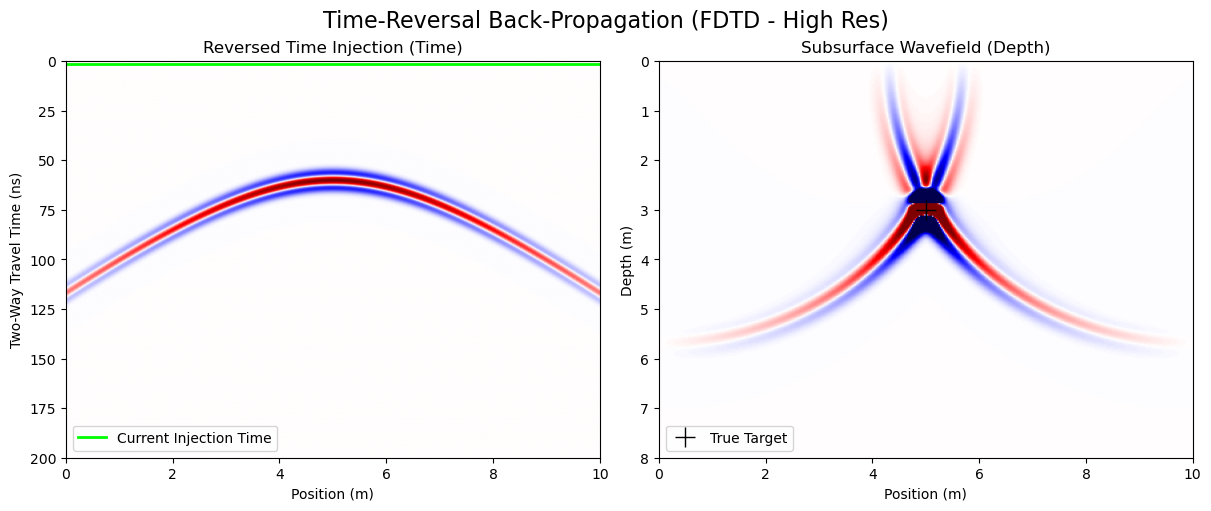

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
x_start, x_end = 0, 10.0
z_start, z_target = 0, 3.0
x_target = 5.0
v = 0.1
v_mig = v / 2          # Exploding reflector velocity
f_c = 0.1              # Center frequency in GHz

# ==========================================
# 2. DISPERSION-FREE GRID COUPLING
# ==========================================
# We need dx to be much smaller to prevent numerical dispersion. 
# 0.025m gives ~20 points per center wavelength.
nx = 401 
dx = (x_end - x_start) / (nx - 1)
dz = dx

z_end_desired = 8.0
nz = int((z_end_desired - z_start) / dz) + 1
z_end_actual = (nz - 1) * dz  

x_pos = np.linspace(x_start, x_end, nx)

# STRICT CFL CONDITION: dt must be small enough to prevent instability
# 2D CFL limit: dt <= dx / (v_mig * sqrt(2))
dt_cfl = dx / (v_mig * np.sqrt(2))
dt = dt_cfl * 0.9  # Safety margin of 0.9

t_max = 200.0
nt = int(t_max / dt) + 1
time_axis = np.linspace(0, t_max, nt)

# ==========================================
# 3. Generate B-Scan
# ==========================================
def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

b_scan = np.zeros((nt, nx))
for i, x in enumerate(x_pos):
    dist = np.sqrt((x - x_target)**2 + z_target**2)
    b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2

# ==========================================
# 4. FDTD Back-Propagation Setup
# ==========================================
C = v_mig * dt / dx
C2 = C**2

P_past = np.zeros((nz, nx))
P_now = np.zeros((nz, nx))
P_next = np.zeros((nz, nx))

# ==========================================
# 5. Figure Setup
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle('Time-Reversal Back-Propagation (FDTD - High Res)', fontsize=16)

# Panel 1
ax1.set_title('Reversed Time Injection (Time)')
ax1.set_xlabel('Position (m)')
ax1.set_ylabel('Two-Way Travel Time (ns)')
im1 = ax1.imshow(b_scan, aspect='auto', cmap='seismic', extent=[x_start, x_end, t_max, 0], vmin=-1, vmax=1)
injection_line = ax1.axhline(t_max, color='lime', linewidth=2, label='Current Injection Time')
ax1.legend(loc='lower left')

# Panel 2
ax2.set_title('Subsurface Wavefield (Depth)')
ax2.set_xlabel('Position (m)')
ax2.set_ylabel('Depth (m)')
im2 = ax2.imshow(P_now, aspect='auto', cmap='seismic', extent=[x_start, x_end, z_end_actual, z_start], vmin=-0.1, vmax=0.1)
ax2.plot(x_target, z_target, 'k+', markersize=15, label='True Target')
ax2.legend(loc='lower left')

# ==========================================
# 6. Animation Logic
# ==========================================
def init():
    P_past.fill(0)
    P_now.fill(0)
    P_next.fill(0)
    return im2, injection_line

# Because nt is now much larger (~900 frames), we process multiple FDTD steps 
# per drawn frame to keep the animation fast.
frame_skip = 5  
total_frames = nt // frame_skip

def update(frame):
    global P_past, P_now, P_next
    
    # Run the FDTD engine for 'frame_skip' steps before updating the plot
    for step in range(frame_skip):
        t_step = nt - 1 - (frame * frame_skip + step)
        if t_step < 0:
            break
            
        # 2D Acoustic FDTD Laplacian calculation
        Laplacian = (
            P_now[:-2, 1:-1] + P_now[2:, 1:-1] + 
            P_now[1:-1, :-2] + P_now[1:-1, 2:] - 
            4 * P_now[1:-1, 1:-1]
        )
        
        # FDTD Time stepping
        P_next[1:-1, 1:-1] = 2 * P_now[1:-1, 1:-1] - P_past[1:-1, 1:-1] + C2 * Laplacian
        
        # Inject the recorded data at the surface
        P_next[0, :] = b_scan[t_step, :]
        
        # Cycle arrays
        P_past[:, :] = P_now
        P_now[:, :] = P_next
        
    injection_line.set_ydata([time_axis[max(0, t_step)]])
    im2.set_data(P_now)
    
    return im2, injection_line

ani = FuncAnimation(fig, update, frames=total_frames, init_func=init, interval=20, blit=True)
ani.save('BackPropagation_Corrected.gif', writer='pillow', fps=20)
plt.show()

Rendering FDTD Back-Propagation animation...


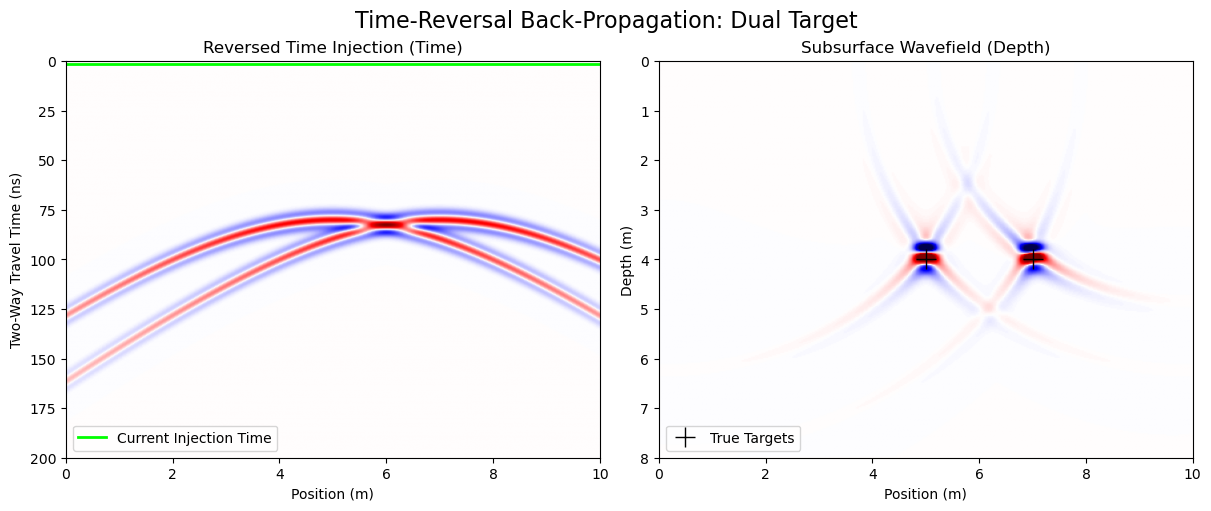

In [21]:
import numpy as np
# import matplotlib.subplots as subplots
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
x_start, x_end = 0, 10.0
z_start, z_end_desired = 0, 8.0

# Dual Targets
x_tgt1, z_tgt1 = 5.0, 4.0
x_tgt2, z_tgt2 = 7.0, 4.0

v = 0.1
v_mig = v / 2          # Exploding reflector velocity
f_c = 0.1              # Center frequency in GHz

# ==========================================
# 2. DISPERSION-FREE GRID COUPLING
# ==========================================
nx = 401 
dx = (x_end - x_start) / (nx - 1)
dz = dx

nz = int((z_end_desired - z_start) / dz) + 1
z_end_actual = (nz - 1) * dz  

x_pos = np.linspace(x_start, x_end, nx)

# STRICT CFL CONDITION
dt_cfl = dx / (v_mig * np.sqrt(2))
dt = dt_cfl * 0.9  

t_max = 200.0
nt = int(t_max / dt) + 1
time_axis = np.linspace(0, t_max, nt)

# ==========================================
# 3. Generate B-Scan
# ==========================================
def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

b_scan = np.zeros((nt, nx))
for i, x in enumerate(x_pos):
    dist1 = np.sqrt((x - x_tgt1)**2 + z_tgt1**2)
    dist2 = np.sqrt((x - x_tgt2)**2 + z_tgt2**2)
    
    b_scan[:, i] = (ricker(time_axis - (2 * dist1 / v), f_c) * (z_tgt1 / dist1)**2) + \
                   (ricker(time_axis - (2 * dist2 / v), f_c) * (z_tgt2 / dist2)**2)

# ==========================================
# 4. FDTD Back-Propagation Setup
# ==========================================
C = v_mig * dt / dx
C2 = C**2

P_past = np.zeros((nz, nx))
P_now = np.zeros((nz, nx))
P_next = np.zeros((nz, nx))

# ==========================================
# 5. Figure Setup
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle('Time-Reversal Back-Propagation: Dual Target', fontsize=16)

# Panel 1
ax1.set_title('Reversed Time Injection (Time)')
ax1.set_xlabel('Position (m)')
ax1.set_ylabel('Two-Way Travel Time (ns)')
vmax_bscan = np.max(np.abs(b_scan)) * 1.0
im1 = ax1.imshow(b_scan, aspect='auto', cmap='seismic', extent=[x_start, x_end, t_max, 0], vmin=-vmax_bscan, vmax=vmax_bscan)
injection_line = ax1.axhline(t_max, color='lime', linewidth=2, label='Current Injection Time')
ax1.legend(loc='lower left')

# Panel 2
ax2.set_title('Subsurface Wavefield (Depth)')
ax2.set_xlabel('Position (m)')
ax2.set_ylabel('Depth (m)')
im2 = ax2.imshow(P_now, aspect='auto', cmap='seismic', extent=[x_start, x_end, z_end_actual, z_start], vmin=-vmax_bscan, vmax=vmax_bscan)
ax2.plot([x_tgt1, x_tgt2], [z_tgt1, z_tgt2], 'k+', markersize=15, label='True Targets')
ax2.legend(loc='lower left')

# ==========================================
# 6. Animation Logic
# ==========================================
def init():
    P_past.fill(0)
    P_now.fill(0)
    P_next.fill(0)
    return im2, injection_line

frame_skip = 5  
total_frames = nt // frame_skip

def update(frame):
    global P_past, P_now, P_next
    
    for step in range(frame_skip):
        t_step = nt - 1 - (frame * frame_skip + step)
        if t_step < 0:
            break
            
        Laplacian = (
            P_now[:-2, 1:-1] + P_now[2:, 1:-1] + 
            P_now[1:-1, :-2] + P_now[1:-1, 2:] - 
            4 * P_now[1:-1, 1:-1]
        )
        
        P_next[1:-1, 1:-1] = 2 * P_now[1:-1, 1:-1] - P_past[1:-1, 1:-1] + C2 * Laplacian
        
        P_next[0, :] = b_scan[t_step, :]
        
        P_past[:, :] = P_now
        P_now[:, :] = P_next
        
    injection_line.set_ydata([time_axis[max(0, t_step)]])
    im2.set_data(P_now)
    
    return im2, injection_line

ani = FuncAnimation(fig, update, frames=total_frames, init_func=init, interval=20, blit=True)
print("Rendering FDTD Back-Propagation animation...")
ani.save('BackPropagation_Dual_Scatterer.gif', writer='pillow', fps=20)
plt.show()

<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30660\2750095540.py:39: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle(f'Sub-Wavelength Target Shift ($\lambda = {wavelength:.1f}$ m)', fontsize=16)


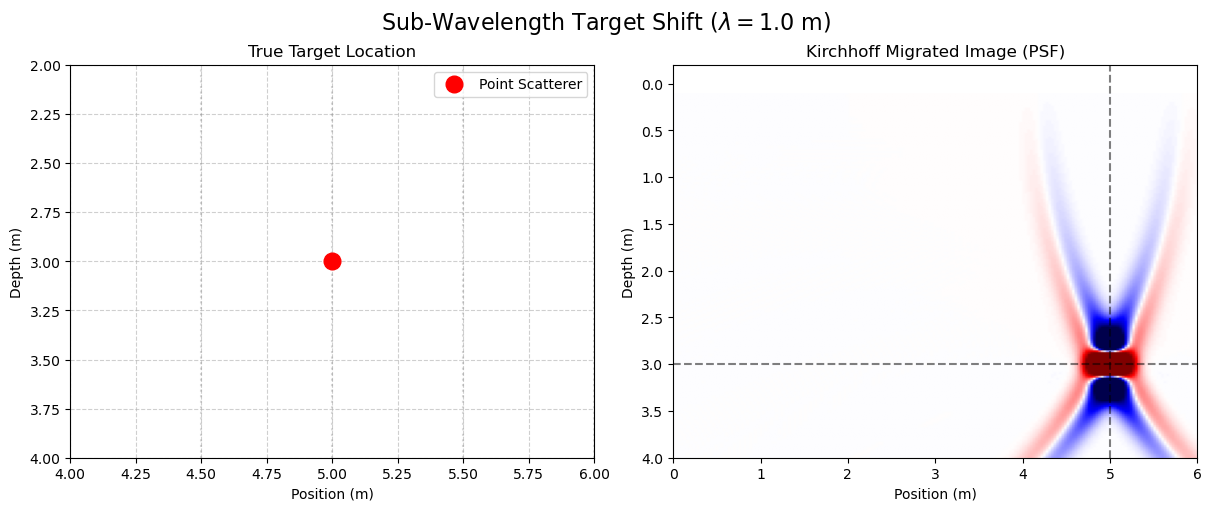

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
v = 0.1                     # Velocity (m/ns)
f_c = 0.1                   # Center frequency (100 MHz)
wavelength = v / f_c        # Wavelength = 1.0 m

# Sub-wavelength movement parameters
x_start_target = 4.75
x_end_target = 5.00         # Total shift of 0.5m (which is lambda / 2)
z_target = 3.0
num_frames = 50

target_x_positions = np.linspace(x_start_target, x_end_target, num_frames)

# B-Scan Acquisition Grid (Wide aperture for good migration)
nx_bscan = 200
x_bscan = np.linspace(0, 10, nx_bscan)
t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)

# Migration Grid (Zoomed in on the target to see the sub-wavelength shift)
nx_mig, nz_mig = 200, 200
x_mig = np.linspace(0, 6, nx_mig)  # Zoomed to 4m - 6m
z_mig = np.linspace(0.1, 4, nz_mig)  # Zoomed to 2m - 4m
X_mig, Z_mig = np.meshgrid(x_mig, z_mig)

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

# ==========================================
# 2. Figure Setup
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle(f'Sub-Wavelength Target Shift ($\lambda = {wavelength:.1f}$ m)', fontsize=16)

# --- Panel 1: True Physical Space ---
ax1.set_title('True Target Location')
ax1.set_xlabel('Position (m)')
ax1.set_ylabel('Depth (m)')
ax1.set_xlim(4, 6)
ax1.set_ylim(4, 2)  # Inverted depth axis
ax1.grid(True, linestyle='--', alpha=0.6)

# Draw a static reference grid representing wavelength spacing
for x_line in np.arange(4.0, 6.5, 0.5):
    ax1.axvline(x_line, color='gray', alpha=0.3, linestyle=':')

target_dot, = ax1.plot([], [], 'ro', markersize=12, label='Point Scatterer')
ax1.legend(loc='upper right')

# --- Panel 2: Kirchhoff Migrated Image ---
ax2.set_title('Kirchhoff Migrated Image (PSF)')
ax2.set_xlabel('Position (m)')
ax2.set_ylabel('Depth (m)')

# We will update the image data dynamically
im2 = ax2.imshow(np.zeros((nz_mig, nx_mig)), aspect='auto', cmap='seismic', 
                 extent=[x_mig[0], x_mig[-1], z_mig[-1], z_mig[0]], vmin=-12, vmax=12)

# Crosshairs to track the peak of the PSF
psf_cross_h = ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
psf_cross_v = ax2.axvline(0, color='black', linestyle='--', alpha=0.5)

# ==========================================
# 3. Animation Logic
# ==========================================
def update(frame):
    current_x_target = target_x_positions[frame]
    
    # 1. Update Left Panel (Physical Target)
    target_dot.set_data([current_x_target], [z_target])
    
    # 2. Generate the raw B-scan for this specific target position
    b_scan = np.zeros((nt, nx_bscan))
    for i, x_tr in enumerate(x_bscan):
        dist = np.sqrt((x_tr - current_x_target)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
        
    # 3. Perform Fast Kirchhoff Migration on the zoomed-in grid
    migrated_image = np.zeros((nz_mig, nx_mig))
    for i, x_tr in enumerate(x_bscan):
        dist_grid = np.sqrt((X_mig - x_tr)**2 + Z_mig**2)
        t_grid = 2 * dist_grid / v
        
        # Interpolate trace amplitudes onto the travel-time grid
        contribution = np.interp(t_grid.ravel(), time_axis, b_scan[:, i]).reshape(nz_mig, nx_mig)
        contribution *= (Z_mig / dist_grid)  # Obliquity factor
        
        migrated_image += contribution
        
    # 4. Update Right Panel (Migrated Image)
    im2.set_data(migrated_image)
    
    # Track the peak amplitude to show it perfectly follows the sub-wavelength shift
    psf_cross_h.set_ydata([z_target])
    psf_cross_v.set_xdata([current_x_target])
    
    return target_dot, im2, psf_cross_h, psf_cross_v

ani = FuncAnimation(fig, update, frames=num_frames, interval=100, blit=True)

# Uncomment to save
ani.save('SubWavelength_Migration_Shift.gif', writer='pillow', fps=10)

plt.show()

<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30660\1960701010.py:40: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle(f'Sub-Wavelength Tracking\nTotal Shift = 0.5 $\lambda$ ($\lambda = {wavelength:.1f}$ m)', fontsize=14)


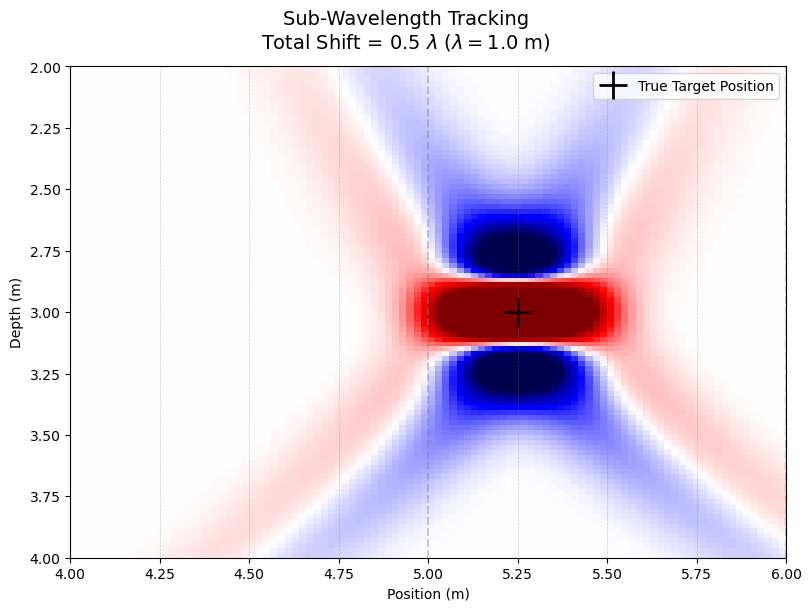

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
v = 0.1                     # Velocity (m/ns)
f_c = 0.1                   # Center frequency (100 MHz)
wavelength = v / f_c        # Wavelength = 1.0 m

# Sub-wavelength movement parameters
x_start_target = 4.75
x_end_target = 5.25         # Total shift of 0.5m (which is exactly lambda / 2)
z_target = 3.0
num_frames = 50

target_x_positions = np.linspace(x_start_target, x_end_target, num_frames)

# B-Scan Acquisition Grid (Wide aperture to capture the full hyperbola)
nx_bscan = 100
x_bscan = np.linspace(0, 10, nx_bscan)
t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)

# Migration Grid (Zoomed tightly around the target to see the shift)
nx_mig, nz_mig = 100, 100
x_mig = np.linspace(4, 6, nx_mig)  
z_mig = np.linspace(2, 4, nz_mig)  
X_mig, Z_mig = np.meshgrid(x_mig, z_mig)

def ricker(t, f):
    """Generates a Ricker wavelet."""
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

# ==========================================
# 2. Figure Setup
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
fig.suptitle(f'Sub-Wavelength Tracking\nTotal Shift = 0.5 $\lambda$ ($\lambda = {wavelength:.1f}$ m)', fontsize=14)

ax.set_xlabel('Position (m)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(4, 6)
ax.set_ylim(4, 2)  # Inverted depth axis

# Draw a static reference grid representing wavelength spacing
for x_line in np.arange(4.0, 6.5, 0.25):
    linewidth = 1.5 if x_line % 1.0 == 0 else 0.5
    ax.axvline(x_line, color='gray', alpha=0.4, linestyle='--', linewidth=linewidth)

# Initialize the empty migrated image
im = ax.imshow(np.zeros((nz_mig, nx_mig)), aspect='auto', cmap='seismic', 
               extent=[x_mig[0], x_mig[-1], z_mig[-1], z_mig[0]], vmin=-12, vmax=12)

# Initialize the crosshair representing the TRUE physical location
true_target, = ax.plot([], [], 'k+', markersize=20, markeredgewidth=2, label='True Target Position')
ax.legend(loc='upper right')

# ==========================================
# 3. Animation Logic
# ==========================================
def update(frame):
    current_x = target_x_positions[frame]
    
    # 1. Update True Target Marker
    true_target.set_data([current_x], [z_target])
    
    # 2. Generate the raw B-scan for this specific position
    b_scan = np.zeros((nt, nx_bscan))
    for i, x_tr in enumerate(x_bscan):
        dist = np.sqrt((x_tr - current_x)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
        
    # 3. Perform Fast Kirchhoff Migration on the zoomed-in grid
    migrated_image = np.zeros((nz_mig, nx_mig))
    for i, x_tr in enumerate(x_bscan):
        dist_grid = np.sqrt((X_mig - x_tr)**2 + Z_mig**2)
        t_grid = 2 * dist_grid / v
        
        # Interpolate and apply obliquity factor
        contribution = np.interp(t_grid.ravel(), time_axis, b_scan[:, i]).reshape(nz_mig, nx_mig)
        contribution *= (Z_mig / dist_grid)  
        
        migrated_image += contribution
        
    # 4. Update the Migrated Image Background
    im.set_data(migrated_image)
    
    return true_target, im

ani = FuncAnimation(fig, update, frames=num_frames, interval=100, blit=True)

# Uncomment to save as a GIF for your presentation
ani.save('SinglePanel_SubWavelength_Shift.gif', writer='pillow', fps=10)

plt.show()

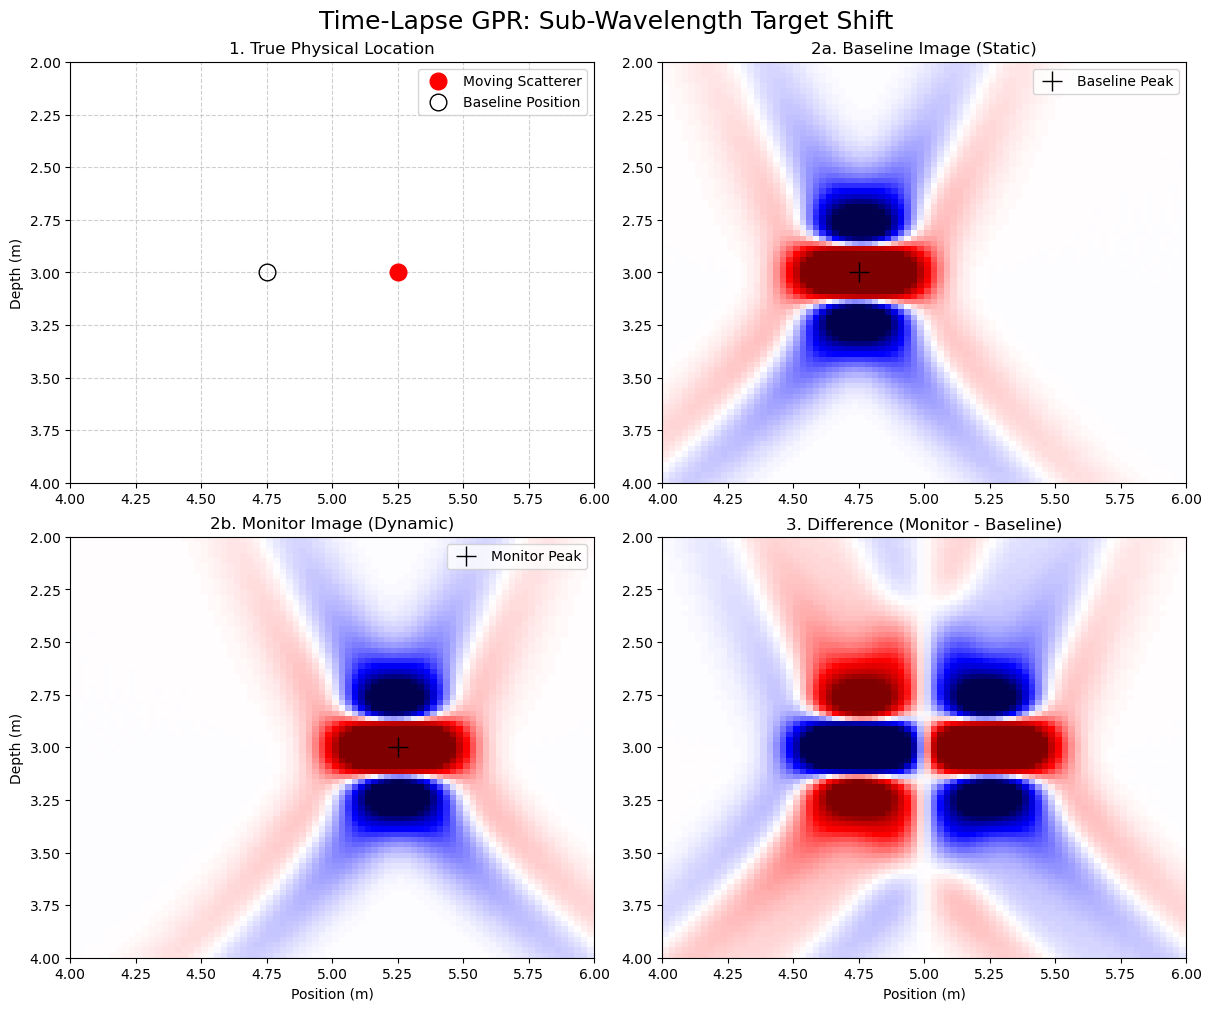

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
v = 0.1                     # Velocity (m/ns)
f_c = 0.1                   # Center frequency (100 MHz)
wavelength = v / f_c        # Wavelength = 1.0 m

# Sub-wavelength movement parameters (Total shift = 0.5m = lambda / 2)
x_start = 4.75
x_end = 5.25         
z_target = 3.0
num_frames = 50

target_x_positions = np.linspace(x_start, x_end, num_frames)

# B-Scan Acquisition Grid (Wide aperture)
nx_bscan = 100
x_bscan = np.linspace(0, 10, nx_bscan)
t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)

# Migration Grid (Zoomed tightly around the target to see the shift)
nx_mig, nz_mig = 80, 80
x_mig = np.linspace(4, 6, nx_mig)  
z_mig = np.linspace(2, 4, nz_mig)  
X_mig, Z_mig = np.meshgrid(x_mig, z_mig)

def ricker(t, f):
    """Generates a Ricker wavelet."""
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def generate_bscan(x_tgt):
    """Generates a raw B-scan for a given target position."""
    b_scan = np.zeros((nt, nx_bscan))
    for i, x_tr in enumerate(x_bscan):
        dist = np.sqrt((x_tr - x_tgt)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
    return b_scan

def migrate_bscan(b_scan):
    """Performs Fast Kirchhoff Migration on the zoomed-in grid."""
    migrated_image = np.zeros((nz_mig, nx_mig))
    for i, x_tr in enumerate(x_bscan):
        dist_grid = np.sqrt((X_mig - x_tr)**2 + Z_mig**2)
        t_grid = 2 * dist_grid / v
        contribution = np.interp(t_grid.ravel(), time_axis, b_scan[:, i]).reshape(nz_mig, nx_mig)
        contribution *= (Z_mig / dist_grid)  
        migrated_image += contribution
    return migrated_image

# ==========================================
# 2. Pre-Calculate the Baseline Image
# ==========================================
bscan_base = generate_bscan(x_start)
img_base = migrate_bscan(bscan_base)

# ==========================================
# 3. Figure Setup (2x2 Grid)
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
fig.suptitle('Time-Lapse GPR: Sub-Wavelength Target Shift', fontsize=18)

extent_mig = [x_mig[0], x_mig[-1], z_mig[-1], z_mig[0]]
v_lim = 12 # Amplitude limit for the migrated images

# --- Panel 1: True Physical Model ---
axs[0,0].set_title('1. True Physical Location')
axs[0,0].set_xlim(4, 6)
axs[0,0].set_ylim(4, 2)  # Inverted depth axis
axs[0,0].set_ylabel('Depth (m)')
axs[0,0].grid(True, linestyle='--', alpha=0.6)
true_target, = axs[0,0].plot([], [], 'ro', markersize=12, label='Moving Scatterer')
axs[0,0].plot(x_start, z_target, 'ko', markersize=12, markerfacecolor='none', label='Baseline Position')
axs[0,0].legend(loc='upper right')

# --- Panel 2: Baseline Migrated Image ---
axs[0,1].set_title('2a. Baseline Image (Static)')
axs[0,1].imshow(img_base, aspect='auto', cmap='seismic', extent=extent_mig, vmin=-v_lim, vmax=v_lim)
axs[0,1].plot(x_start, z_target, 'k+', markersize=15, label='Baseline Peak')
axs[0,1].legend(loc='upper right')

# --- Panel 3: Monitor Migrated Image ---
axs[1,0].set_title('2b. Monitor Image (Dynamic)')
axs[1,0].set_xlabel('Position (m)')
axs[1,0].set_ylabel('Depth (m)')
im_mon = axs[1,0].imshow(img_base, aspect='auto', cmap='seismic', extent=extent_mig, vmin=-v_lim, vmax=v_lim)
mon_target, = axs[1,0].plot([], [], 'k+', markersize=15, label='Monitor Peak')
axs[1,0].legend(loc='upper right')

# --- Panel 4: Difference Image (Monitor - Baseline) ---
axs[1,1].set_title('3. Difference (Monitor - Baseline)')
axs[1,1].set_xlabel('Position (m)')
im_diff = axs[1,1].imshow(np.zeros_like(img_base), aspect='auto', cmap='seismic', extent=extent_mig, vmin=-v_lim, vmax=v_lim)

# ==========================================
# 4. Animation Logic
# ==========================================
def update(frame):
    current_x = target_x_positions[frame]
    
    # Update markers
    true_target.set_data([current_x], [z_target])
    mon_target.set_data([current_x], [z_target])
    
    # Compute new monitor wavefield
    bscan_mon = generate_bscan(current_x)
    img_mon = migrate_bscan(bscan_mon)
    
    # Compute time-lapse difference
    img_diff = img_mon - img_base
    
    # Update image data
    im_mon.set_data(img_mon)
    im_diff.set_data(img_diff)
    
    return true_target, mon_target, im_mon, im_diff

ani = FuncAnimation(fig, update, frames=num_frames, interval=100, blit=True)

# Uncomment to save as a GIF for your presentation
ani.save('TimeLapse_Migration_SubWavelength.gif', writer='pillow', fps=10)

plt.show()

Running Gazdag Migration for separation = 1λ...


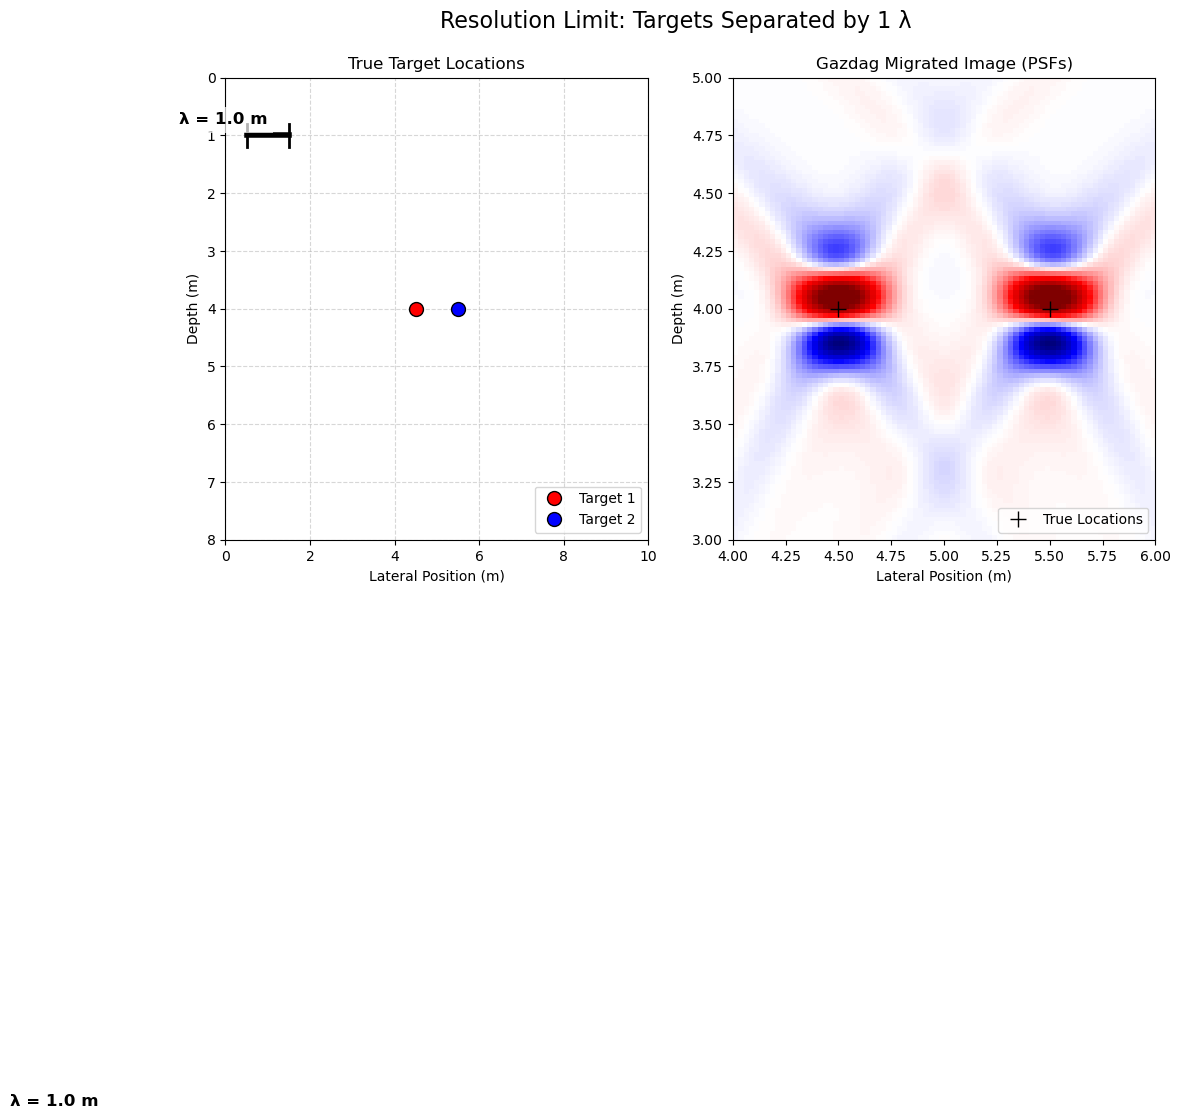

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Primary Control Variable
# ==========================================
# Set the lateral separation of the targets as a fraction of the wavelength
separation_fraction = 1 

# ==========================================
# 2. Setup Parameters & Physics
# ==========================================
# Medium and Radar properties
v = 0.1                      # Velocity (m/ns)
f_c = 0.1                    # Center frequency (GHz)
wavelength = v / f_c         # Dominant Wavelength (m) -> 1.0 m

# Grid Definitions
nx, nz = 400, 400
x_start, x_end = 0, 10
z_start, z_end = 0, 8
x_pos = np.linspace(x_start, x_end, nx)
z_pos = np.linspace(z_start, z_end, nz)
dx = x_pos[1] - x_pos[0]
dz = z_pos[1] - z_pos[0]

# Time Definitions
t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)
dt = time_axis[1] - time_axis[0]

# Target Locations
x_center = 5.0
z_target = 4.0
separation_m = separation_fraction * wavelength

x_tgt1 = x_center - (separation_m / 2)
x_tgt2 = x_center + (separation_m / 2)

# ==========================================
# 3. Generate B-Scan
# ==========================================
def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

b_scan = np.zeros((nt, nx))
for i, x in enumerate(x_pos):
    dist1 = np.sqrt((x - x_tgt1)**2 + z_target**2)
    dist2 = np.sqrt((x - x_tgt2)**2 + z_tgt2**2)
    
    b_scan[:, i] = (ricker(time_axis - (2 * dist1 / v), f_c) * (z_target / dist1)**2) + \
                   (ricker(time_axis - (2 * dist2 / v), f_c) * (z_target / dist2)**2)

# ==========================================
# 4. Gazdag Phase-Shift Migration
# ==========================================
v_mig = v / 2  # Exploding reflector velocity

# Padding to prevent spatial and temporal wrap-around artifacts
pad_t = nt
pad_x = nx // 2
nt_pad = nt + pad_t
nx_pad = nx + (2 * pad_x)
b_scan_padded = np.pad(b_scan, ((0, pad_t), (pad_x, pad_x)), mode='constant')

# 2D FFT
P_fk = np.fft.fft2(b_scan_padded)
freqs = np.fft.fftfreq(nt_pad, d=dt)
kxs = np.fft.fftfreq(nx_pad, d=dx)
KX, F = np.meshgrid(kxs, freqs)

omega = 2 * np.pi * F
kx = 2 * np.pi * KX

# Evanescent filter and vertical wavenumber (kz) calculation
kz_sq = (omega / v_mig)**2 - kx**2
kz = np.where(kz_sq >= 0, np.sqrt(np.maximum(kz_sq, 0)), 0)
kz = np.sign(omega) * kz 

migrated_image = np.zeros((nz, nx))

print(f"Running Gazdag Migration for separation = {separation_fraction}λ...")
for iz, z in enumerate(z_pos):
    # Downward continue the wavefield
    phase_shift = np.exp(1j * kz * z)
    P_shifted_fk = P_fk * phase_shift
    
    # Transform back to extract t=0 imaging condition
    P_shifted_xt_padded = np.real(np.fft.ifft2(P_shifted_fk))
    
    # Extract the t=0 slice (first row) and unpad the spatial axis
    migrated_image[iz, :] = P_shifted_xt_padded[0, pad_x:pad_x+nx]

# ==========================================
# 5. Figure Setup & Plotting
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
fig.suptitle(f'Resolution Limit: Targets Separated by {separation_fraction} \u03BB', fontsize=16)

def add_wavelength_bar(ax):
    """Helper function to draw a scale bar representing the dominant wavelength."""
    bar_x_start = 0.5
    bar_y = 1.0
    ax.plot([bar_x_start, bar_x_start + wavelength], [bar_y, bar_y], color='black', linewidth=4)
    # Add end caps
    ax.plot([bar_x_start, bar_x_start], [bar_y - 0.2, bar_y + 0.2], color='black', linewidth=2)
    ax.plot([bar_x_start + wavelength, bar_x_start + wavelength], [bar_y - 0.2, bar_y + 0.2], color='black', linewidth=2)
    # Label
    ax.text(bar_x_start + (wavelength / 2), bar_y - 0.4, f'\u03BB = {wavelength:.1f} m', 
            ha='center', va='top', fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# --- Panel 1: Physical Space ---
ax1.set_title('True Target Locations')
ax1.set_xlabel('Lateral Position (m)')
ax1.set_ylabel('Depth (m)')
ax1.set_xlim(x_start, x_end)
ax1.set_ylim(z_end, z_start)
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot True Targets
ax1.plot(x_tgt1, z_target, 'ko', markersize=10, markerfacecolor='red', label='Target 1')
ax1.plot(x_tgt2, z_target, 'ko', markersize=10, markerfacecolor='blue', label='Target 2')
ax1.legend(loc='lower right')
add_wavelength_bar(ax1)


# --- Panel 2: Gazdag Migrated Image ---
ax2.set_title('Gazdag Migrated Image (PSFs)')
ax2.set_xlabel('Lateral Position (m)')
ax2.set_ylabel('Depth (m)')

vmax_mig = np.max(np.abs(migrated_image)) * 0.8
im2 = ax2.imshow(migrated_image, aspect='auto', cmap='seismic', 
                 extent=[x_start, x_end, z_end, z_start], vmin=-vmax_mig, vmax=vmax_mig)

# Plot True Target Locations as crosses for reference
ax2.plot(x_tgt1, z_target, 'k+', markersize=12, label='True Locations')
ax2.plot(x_tgt2, z_target, 'k+', markersize=12)
add_wavelength_bar(ax2)

ax2.set_xlim(4, 6)
ax2.set_ylim(3, 5)

ax2.legend(loc='lower right')

plt.show()

Starting render. Due to FFT scaling per frame, this will take approximately 1-2 minutes...
Processing Frame 1/50 (Separation: 1.50λ)
Processing Frame 1/50 (Separation: 1.50λ)
Processing Frame 2/50 (Separation: 1.47λ)
Processing Frame 3/50 (Separation: 1.44λ)
Processing Frame 4/50 (Separation: 1.41λ)
Processing Frame 5/50 (Separation: 1.39λ)
Processing Frame 6/50 (Separation: 1.36λ)
Processing Frame 7/50 (Separation: 1.33λ)
Processing Frame 8/50 (Separation: 1.30λ)
Processing Frame 9/50 (Separation: 1.27λ)
Processing Frame 10/50 (Separation: 1.24λ)
Processing Frame 11/50 (Separation: 1.21λ)
Processing Frame 12/50 (Separation: 1.19λ)
Processing Frame 13/50 (Separation: 1.16λ)
Processing Frame 14/50 (Separation: 1.13λ)
Processing Frame 15/50 (Separation: 1.10λ)
Processing Frame 16/50 (Separation: 1.07λ)
Processing Frame 17/50 (Separation: 1.04λ)
Processing Frame 18/50 (Separation: 1.01λ)
Processing Frame 19/50 (Separation: 0.99λ)
Processing Frame 20/50 (Separation: 0.96λ)
Processing Frame

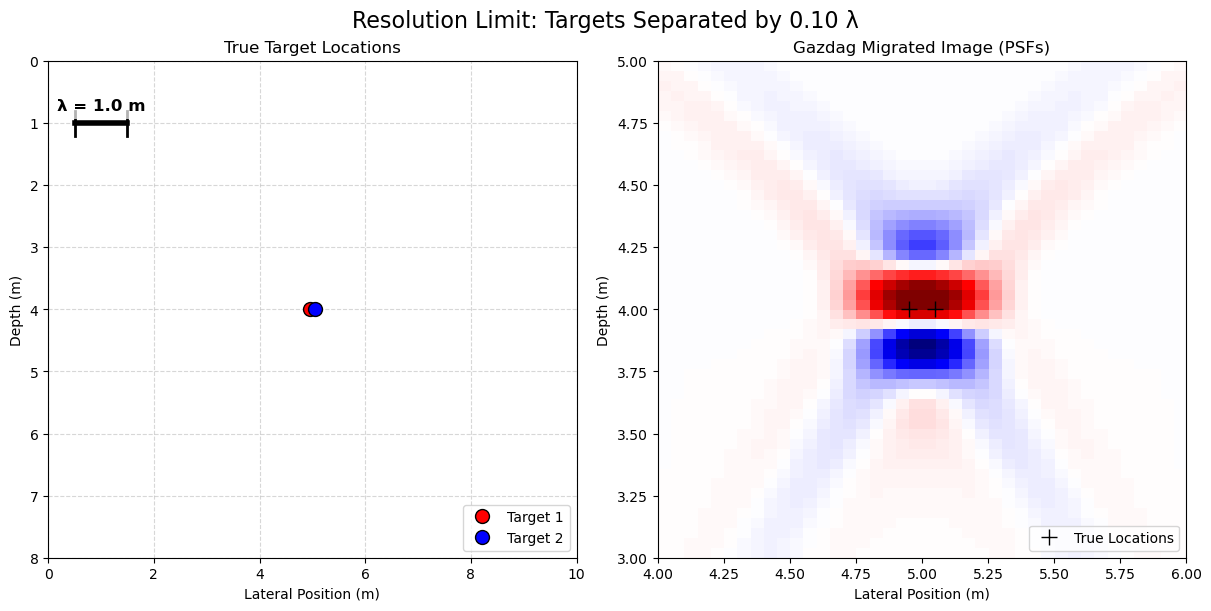

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
# Medium and Radar properties
v = 0.1                      # Velocity (m/ns)
f_c = 0.1                    # Center frequency (GHz)
wavelength = v / f_c         # Dominant Wavelength (m) -> 1.0 m

# Grid Definitions
nx, nz = 200, 200
x_start, x_end = 0, 10
z_start, z_end = 0, 8
x_pos = np.linspace(x_start, x_end, nx)
z_pos = np.linspace(z_start, z_end, nz)
dx = x_pos[1] - x_pos[0]
dz = z_pos[1] - z_pos[0]

# Time Definitions
t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)
dt = time_axis[1] - time_axis[0]

# Target Locations
x_center = 5.0
z_target = 4.0

# Precompute Gazdag migration variables (Padding and Wavenumbers)
v_mig = v / 2  # Exploding reflector velocity
pad_t = nt
pad_x = nx // 2
nt_pad = nt + pad_t
nx_pad = nx + (2 * pad_x)

freqs = np.fft.fftfreq(nt_pad, d=dt)
kxs = np.fft.fftfreq(nx_pad, d=dx)
KX, F = np.meshgrid(kxs, freqs)

omega = 2 * np.pi * F
kx = 2 * np.pi * KX
kz_sq = (omega / v_mig)**2 - kx**2
kz = np.where(kz_sq >= 0, np.sqrt(np.maximum(kz_sq, 0)), 0)
kz = np.sign(omega) * kz 

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

# ==========================================
# 2. Animation Sweep Parameters
# ==========================================
num_frames = 50
separations = np.linspace(1.5, 0.1, num_frames)

# ==========================================
# 3. Figure Setup
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
suptitle = fig.suptitle('', fontsize=16)

def add_wavelength_bar(ax):
    """Draw a scale bar representing the dominant wavelength."""
    bar_x_start = 0.5
    bar_y = 1.0
    ax.plot([bar_x_start, bar_x_start + wavelength], [bar_y, bar_y], color='black', linewidth=4)
    # Add end caps
    ax.plot([bar_x_start, bar_x_start], [bar_y - 0.2, bar_y + 0.2], color='black', linewidth=2)
    ax.plot([bar_x_start + wavelength, bar_x_start + wavelength], [bar_y - 0.2, bar_y + 0.2], color='black', linewidth=2)
    # Label
    ax.text(bar_x_start + (wavelength / 2), bar_y - 0.4, f'\u03BB = {wavelength:.1f} m', 
            ha='center', va='top', fontsize=12, fontweight='bold', 
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# --- Panel 1: Physical Space ---
ax1.set_title('True Target Locations')
ax1.set_xlabel('Lateral Position (m)')
ax1.set_ylabel('Depth (m)')
ax1.set_xlim(4, 6)
ax1.set_ylim(3, 5)
ax1.grid(True, linestyle='--', alpha=0.5)

# Add the wavelength bar ONLY to Panel 1
add_wavelength_bar(ax1)

# Initialize moving target dots
tgt1_dot, = ax1.plot([], [], 'ko', markersize=10, markerfacecolor='red', label='Target 1')
tgt2_dot, = ax1.plot([], [], 'ko', markersize=10, markerfacecolor='blue', label='Target 2')
ax1.legend(loc='lower right')

# --- Panel 2: Gazdag Migrated Image ---
ax2.set_title('Gazdag Migrated Image (PSFs)')
ax2.set_xlabel('Lateral Position (m)')
ax2.set_ylabel('Depth (m)')
ax2.set_xlim(4, 6)
ax2.set_ylim(3, 5)

# Initialize empty image container
im2 = ax2.imshow(np.zeros((nz, nx)), aspect='auto', cmap='seismic', 
                 extent=[x_start, x_end, z_end, z_start], vmin=-1, vmax=1)

# Initialize moving crosshairs
tgt1_cross, = ax2.plot([], [], 'k+', markersize=12, label='True Locations')
tgt2_cross, = ax2.plot([], [], 'k+', markersize=12)
ax2.legend(loc='lower right')

# ==========================================
# 4. Animation Logic
# ==========================================
def update(frame):
    sep_frac = separations[frame]
    separation_m = sep_frac * wavelength
    
    x_tgt1 = x_center - (separation_m / 2)
    x_tgt2 = x_center + (separation_m / 2)
    
    print(f"Processing Frame {frame+1}/{num_frames} (Separation: {sep_frac:.2f}\u03BB)")
    
    # 1. Update visual markers
    tgt1_dot.set_data([x_tgt1], [z_target])
    tgt2_dot.set_data([x_tgt2], [z_target])
    tgt1_cross.set_data([x_tgt1], [z_target])
    tgt2_cross.set_data([x_tgt2], [z_target])
    suptitle.set_text(f'Resolution Limit: Targets Separated by {sep_frac:.2f} \u03BB')
    
    # 2. Generate new B-Scan for this separation
    b_scan = np.zeros((nt, nx))
    for i, x in enumerate(x_pos):
        dist1 = np.sqrt((x - x_tgt1)**2 + z_target**2)
        dist2 = np.sqrt((x - x_tgt2)**2 + z_target**2)
        b_scan[:, i] = (ricker(time_axis - (2 * dist1 / v), f_c) * (z_target / dist1)**2) + \
                       (ricker(time_axis - (2 * dist2 / v), f_c) * (z_target / dist2)**2)
                       
    # 3. Perform Gazdag Phase-Shift Migration
    b_scan_padded = np.pad(b_scan, ((0, pad_t), (pad_x, pad_x)), mode='constant')
    P_fk = np.fft.fft2(b_scan_padded)
    migrated_image = np.zeros((nz, nx))
    
    for iz, z in enumerate(z_pos):
        phase_shift = np.exp(1j * kz * z)
        P_shifted_fk = P_fk * phase_shift
        P_shifted_xt_padded = np.real(np.fft.ifft2(P_shifted_fk))
        migrated_image[iz, :] = P_shifted_xt_padded[0, pad_x:pad_x+nx]
        
    # 4. Update image data and dynamic color scale limits
    im2.set_data(migrated_image)
    vmax_mig = np.max(np.abs(migrated_image)) * 0.8
    im2.set_clim(-vmax_mig, vmax_mig)
    
    return tgt1_dot, tgt2_dot, tgt1_cross, tgt2_cross, im2, suptitle

# Run animation
ani = FuncAnimation(fig, update, frames=num_frames, blit=False, interval=150)

print("Starting render. Due to FFT scaling per frame, this will take approximately 1-2 minutes...")
# Uncomment the line below to save the animation to file
ani.save('Gazdag_Resolution_Limit_Sweep.gif', writer='pillow', fps=8)

plt.show()

Rendering high-quality animation...
Processing Frame 1/50 (Separation: 1.50λ)
Processing Frame 2/50 (Separation: 1.47λ)
Processing Frame 3/50 (Separation: 1.44λ)
Processing Frame 4/50 (Separation: 1.41λ)
Processing Frame 5/50 (Separation: 1.39λ)
Processing Frame 6/50 (Separation: 1.36λ)
Processing Frame 7/50 (Separation: 1.33λ)
Processing Frame 8/50 (Separation: 1.30λ)
Processing Frame 9/50 (Separation: 1.27λ)
Processing Frame 10/50 (Separation: 1.24λ)
Processing Frame 11/50 (Separation: 1.21λ)
Processing Frame 12/50 (Separation: 1.19λ)
Processing Frame 13/50 (Separation: 1.16λ)
Processing Frame 14/50 (Separation: 1.13λ)
Processing Frame 15/50 (Separation: 1.10λ)
Processing Frame 16/50 (Separation: 1.07λ)
Processing Frame 17/50 (Separation: 1.04λ)
Processing Frame 18/50 (Separation: 1.01λ)
Processing Frame 19/50 (Separation: 0.99λ)
Processing Frame 20/50 (Separation: 0.96λ)
Processing Frame 21/50 (Separation: 0.93λ)
Processing Frame 22/50 (Separation: 0.90λ)
Processing Frame 23/50 (Sep

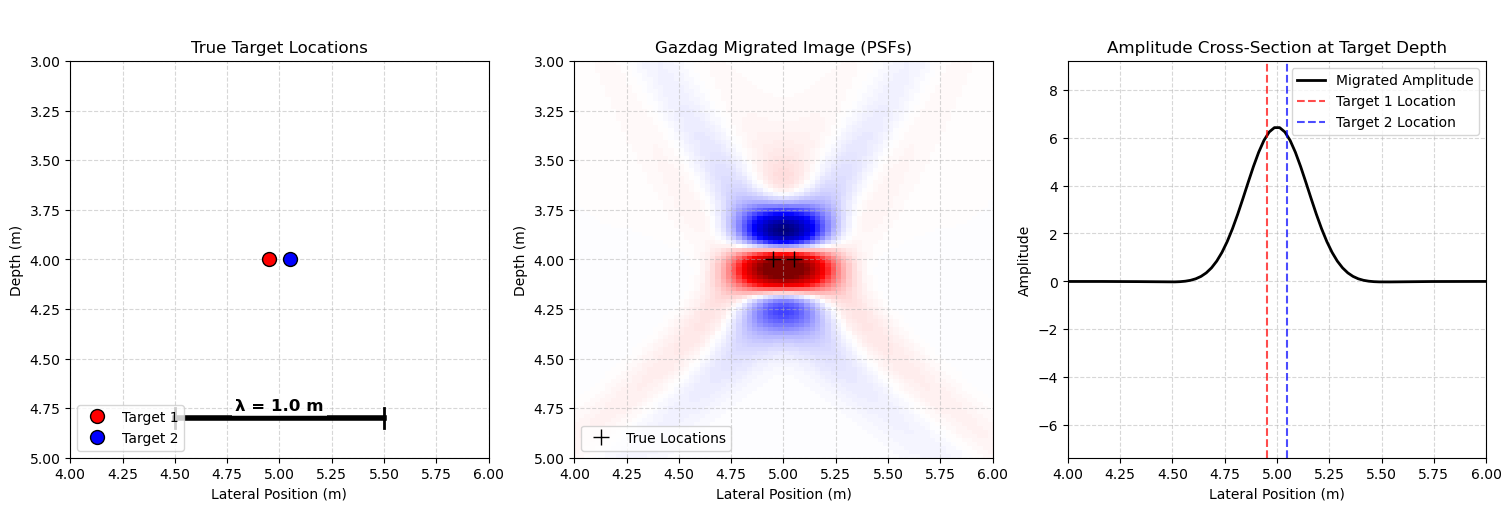

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
# Medium and Radar properties
v = 0.1                      # Velocity (m/ns)
f_c = 0.1                    # Center frequency (GHz)
wavelength = v / f_c         # Dominant Wavelength (m) -> 1.0 m

# Grid Definitions
nx, nz = 400, 400
x_start, x_end = 0, 10
z_start, z_end = 0, 8
x_pos = np.linspace(x_start, x_end, nx)
z_pos = np.linspace(z_start, z_end, nz)
dx = x_pos[1] - x_pos[0]
dz = z_pos[1] - z_pos[0]

# Time Definitions
t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)
dt = time_axis[1] - time_axis[0]

# Target Locations
x_center = 5.0
z_target = 4.0

# Precompute Gazdag migration variables (Padding and Wavenumbers)
v_mig = v / 2  # Exploding reflector velocity
pad_t = nt
pad_x = nx // 2
nt_pad = nt + pad_t
nx_pad = nx + (2 * pad_x)

freqs = np.fft.fftfreq(nt_pad, d=dt)
kxs = np.fft.fftfreq(nx_pad, d=dx)
KX, F = np.meshgrid(kxs, freqs)

omega = 2 * np.pi * F
kx = 2 * np.pi * KX
kz_sq = (omega / v_mig)**2 - kx**2
kz = np.where(kz_sq >= 0, np.sqrt(np.maximum(kz_sq, 0)), 0)
kz = np.sign(omega) * kz 

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

# Find the exact z-index corresponding to the target depth for our 1D slice
iz_target = np.argmin(np.abs(z_pos - z_target))

# ==========================================
# 2. Animation Sweep Parameters
# ==========================================
num_frames = 50
separations = np.linspace(1.5, 0.1, num_frames)

# ==========================================
# 3. Figure Setup
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
suptitle = fig.suptitle('', fontsize=16)

def add_wavelength_bar(ax):
    """Draw a scale bar representing the dominant wavelength."""
    # Placed dynamically within the zoomed 4-6 xlim and 3-5 ylim
    bar_x_start = 4.5
    bar_y = 4.8
    ax.plot([bar_x_start, bar_x_start + wavelength], [bar_y, bar_y], color='black', linewidth=4)
    # Add end caps
    cap_height = 0.05
    ax.plot([bar_x_start, bar_x_start], [bar_y - cap_height, bar_y + cap_height], color='black', linewidth=2)
    ax.plot([bar_x_start + wavelength, bar_x_start + wavelength], [bar_y - cap_height, bar_y + cap_height], color='black', linewidth=2)
    # Label
    ax.text(bar_x_start + (wavelength / 2), bar_y - 0.1, f'\u03BB = {wavelength:.1f} m', 
            ha='center', va='top', fontsize=12, fontweight='bold', 
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

# --- Panel 1: Physical Space ---
ax1.set_title('True Target Locations')
ax1.set_xlabel('Lateral Position (m)')
ax1.set_ylabel('Depth (m)')
ax1.set_xlim(4, 6)
ax1.set_ylim(3, 5)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.invert_yaxis()

add_wavelength_bar(ax1)

# Initialize moving target dots
tgt1_dot, = ax1.plot([], [], 'ko', markersize=10, markerfacecolor='red', label='Target 1')
tgt2_dot, = ax1.plot([], [], 'ko', markersize=10, markerfacecolor='blue', label='Target 2')
ax1.legend(loc='lower left')

# --- Panel 2: Gazdag Migrated Image ---
ax2.set_title('Gazdag Migrated Image (PSFs)')
ax2.set_xlabel('Lateral Position (m)')
ax2.set_ylabel('Depth (m)')
ax2.set_xlim(4, 6)
ax2.set_ylim(3, 5)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.invert_yaxis()

# Initialize empty image container
im2 = ax2.imshow(np.zeros((nz, nx)), aspect='auto', cmap='seismic', 
                 extent=[x_start, x_end, z_end, z_start], vmin=-1, vmax=1)

# Initialize moving crosshairs
tgt1_cross, = ax2.plot([], [], 'k+', markersize=12, label='True Locations')
tgt2_cross, = ax2.plot([], [], 'k+', markersize=12)
ax2.legend(loc='lower left')

# --- Panel 3: 1D Horizontal Cross-Section ---
ax3.set_title('Amplitude Cross-Section at Target Depth')
ax3.set_xlabel('Lateral Position (m)')
ax3.set_ylabel('Amplitude')
ax3.set_xlim(4, 6)
ax3.grid(True, linestyle='--', alpha=0.5)

# Initialize slice line and target indicators
line_slice, = ax3.plot([], [], 'k-', linewidth=2, label='Migrated Amplitude')
tgt1_vline = ax3.axvline(x_center, color='red', linestyle='--', alpha=0.7, label='Target 1 Location')
tgt2_vline = ax3.axvline(x_center, color='blue', linestyle='--', alpha=0.7, label='Target 2 Location')
ax3.legend(loc='upper right')

# ==========================================
# 4. Animation Logic
# ==========================================
def update(frame):
    sep_frac = separations[frame]
    separation_m = sep_frac * wavelength
    
    x_tgt1 = x_center - (separation_m / 2)
    x_tgt2 = x_center + (separation_m / 2)
    
    print(f"Processing Frame {frame+1}/{num_frames} (Separation: {sep_frac:.2f}\u03BB)")
    
    # 1. Update visual markers
    tgt1_dot.set_data([x_tgt1], [z_target])
    tgt2_dot.set_data([x_tgt2], [z_target])
    tgt1_cross.set_data([x_tgt1], [z_target])
    tgt2_cross.set_data([x_tgt2], [z_target])
    
    # Update vertical lines in panel 3
    tgt1_vline.set_xdata([x_tgt1, x_tgt1])
    tgt2_vline.set_xdata([x_tgt2, x_tgt2])
    
    suptitle.set_text(f'Resolution Limit: Targets Separated by {sep_frac:.2f} \u03BB')
    
    # 2. Generate new B-Scan for this separation
    b_scan = np.zeros((nt, nx))
    for i, x in enumerate(x_pos):
        dist1 = np.sqrt((x - x_tgt1)**2 + z_target**2)
        dist2 = np.sqrt((x - x_tgt2)**2 + z_target**2)
        b_scan[:, i] = (ricker(time_axis - (2 * dist1 / v), f_c) * (z_target / dist1)**2) + \
                       (ricker(time_axis - (2 * dist2 / v), f_c) * (z_target / dist2)**2)
                       
    # 3. Perform Gazdag Phase-Shift Migration
    b_scan_padded = np.pad(b_scan, ((0, pad_t), (pad_x, pad_x)), mode='constant')
    P_fk = np.fft.fft2(b_scan_padded)
    migrated_image = np.zeros((nz, nx))
    
    for iz, z in enumerate(z_pos):
        phase_shift = np.exp(1j * kz * z)
        P_shifted_fk = P_fk * phase_shift
        P_shifted_xt_padded = np.real(np.fft.ifft2(P_shifted_fk))
        migrated_image[iz, :] = P_shifted_xt_padded[0, pad_x:pad_x+nx]
        
    # 4. Update image data and dynamic color scale limits for Panel 2
    im2.set_data(migrated_image)
    vmax_mig = np.max(np.abs(migrated_image)) * 0.8
    im2.set_clim(-vmax_mig, vmax_mig)
    
    # 5. Extract and update the 1D cross-section data for Panel 3
    slice_1d = migrated_image[iz_target, :]
    line_slice.set_data(x_pos, slice_1d)
    
    # Dynamically scale the y-axis of the cross-section to accommodate constructive interference
    ax3.set_ylim(-vmax_mig * 1.2, vmax_mig * 1.5)
    
    return tgt1_dot, tgt2_dot, tgt1_cross, tgt2_cross, im2, line_slice, tgt1_vline, tgt2_vline, suptitle

# Run animation
# ani = FuncAnimation(fig, update, frames=num_frames, blit=False, interval=150)

# print("Starting render. Due to FFT scaling per frame, this will take approximately 1-2 minutes...")
# # Uncomment the line below to save the animation to file
# ani.save('Gazdag_Resolution_Limit_3Panels.gif', writer='pillow', fps=8)



# Set repeat=False so the animation plays once and stops on the final frame
ani = FuncAnimation(fig, update, frames=num_frames, init_func=init, 
                    blit=True, interval=60, repeat=False)

print("Rendering high-quality animation...")

# 2. Define a high-quality video writer
# A bitrate of 5000-8000 kbps yields a very clean 1080p-style video
high_res_writer = FFMpegWriter(fps=15, bitrate=8000)

# 3. Save the animation with a high DPI
# Note: Increasing DPI and bitrate will increase rendering time and file size
ani.save('Gazdag_Resolution_Limit_3Panels.mp4', writer=high_res_writer, dpi=300)

print("Export complete!")


plt.show()

<>:68: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30660\3252879977.py:68: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle(f'Lateral PSF Slices and Time-Lapse Differencing ($\lambda = {wavelength:.1f}$ m)', fontsize=16)


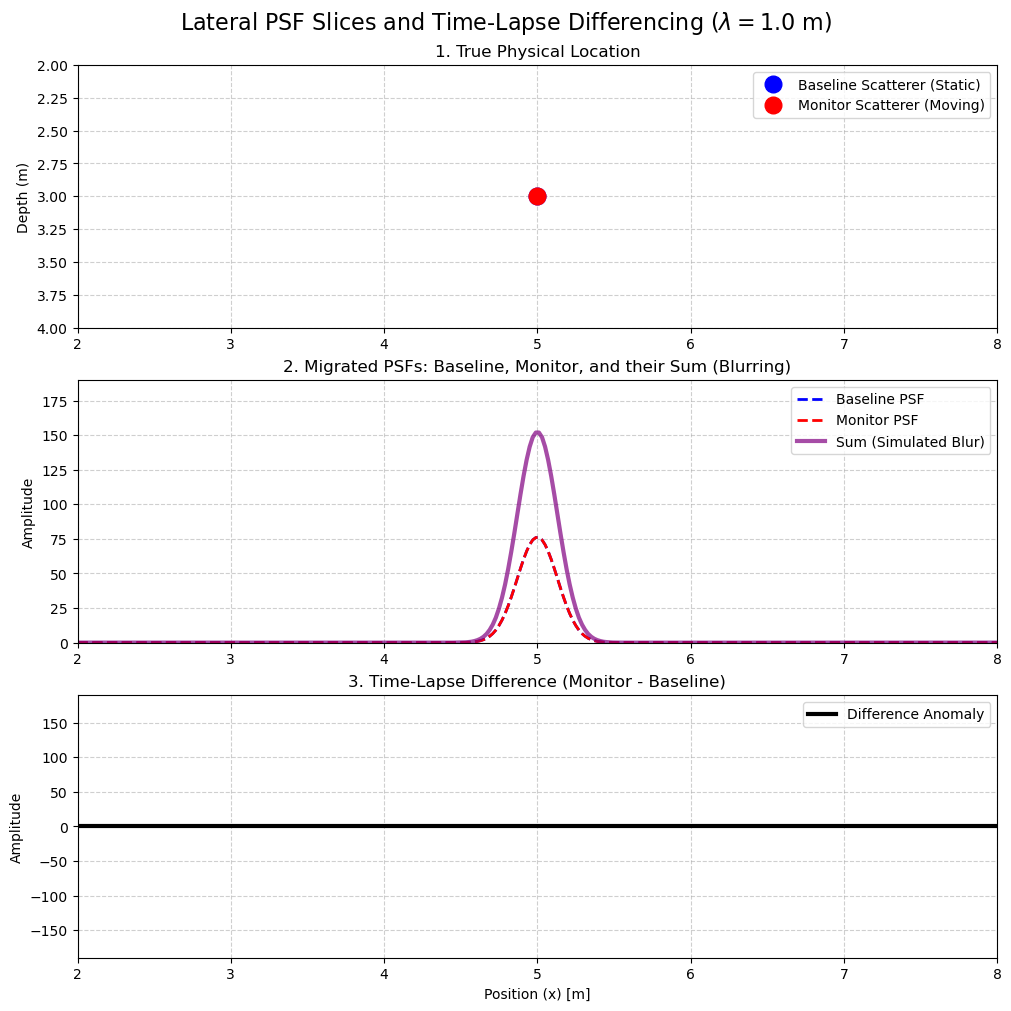

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
v = 0.1                     # Velocity (m/ns)
f_c = 0.1                   # Center frequency (100 MHz)
wavelength = v / f_c        # Wavelength = 1.0 m

z_target = 3.0
x_base = 5.0                # Baseline target is fixed at 5.0m

# Monitor target starts 1.5 wavelengths away and moves to the baseline
x_mon_start = 3.5
x_mon_end = 5.0
num_frames = 80
x_mon_positions = np.linspace(x_mon_start, x_mon_end, num_frames)

# B-Scan Acquisition Grid 
nx_bscan = 150
x_bscan = np.linspace(0, 10, nx_bscan)
t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)

# 1D Migration Grid (Extracting only the horizontal slice at z = z_target)
nx_slice = 300
x_slice = np.linspace(2, 8, nx_slice)

def ricker(t, f):
    """Generates a Ricker wavelet."""
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def generate_bscan(x_tgt):
    """Generates a raw B-scan for a specific target position."""
    b_scan = np.zeros((nt, nx_bscan))
    for i, x_tr in enumerate(x_bscan):
        dist = np.sqrt((x_tr - x_tgt)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
    return b_scan

def migrate_1d_slice(b_scan):
    """Performs Kirchhoff Migration only along the 1D target depth."""
    psf_slice = np.zeros(nx_slice)
    for i, x_tr in enumerate(x_bscan):
        # Calculate traveltimes from the trace to every point on the 1D slice
        dist_grid = np.sqrt((x_slice - x_tr)**2 + z_target**2)
        t_grid = 2 * dist_grid / v
        
        # Interpolate and apply obliquity
        contribution = np.interp(t_grid, time_axis, b_scan[:, i])
        contribution *= (z_target / dist_grid)  
        
        psf_slice += contribution
    return psf_slice

# ==========================================
# 2. Pre-Calculate the Baseline PSF
# ==========================================
bscan_base = generate_bscan(x_base)
psf_base = migrate_1d_slice(bscan_base)

# ==========================================
# 3. Figure Setup (3 Vertical Panels)
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), constrained_layout=True)
fig.suptitle(f'Lateral PSF Slices and Time-Lapse Differencing ($\lambda = {wavelength:.1f}$ m)', fontsize=16)

# --- Panel 1: Physical Model ---
ax1.set_title('1. True Physical Location')
ax1.set_xlim(2, 8)
ax1.set_ylim(4, 2)  # Inverted depth axis
ax1.set_ylabel('Depth (m)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.plot(x_base, z_target, 'bo', markersize=12, label='Baseline Scatterer (Static)')
true_mon, = ax1.plot([], [], 'ro', markersize=12, label='Monitor Scatterer (Moving)')
ax1.legend(loc='upper right')

# --- Panel 2: Lateral PSF Cross-Sections ---
ax2.set_title('2. Migrated PSFs: Baseline, Monitor, and their Sum (Blurring)')
ax2.set_xlim(2, 8)
ax2.set_ylim(np.min(psf_base)*2.5, np.max(psf_base)*2.5)
ax2.set_ylabel('Amplitude')
ax2.grid(True, linestyle='--', alpha=0.6)

# Plot static baseline
ax2.plot(x_slice, psf_base, 'b--', linewidth=2, label='Baseline PSF')
# Moving lines
line_mon, = ax2.plot([], [], 'r--', linewidth=2, label='Monitor PSF')
line_sum, = ax2.plot([], [], 'purple', linewidth=3, alpha=0.7, label='Sum (Simulated Blur)')
ax2.legend(loc='upper right')

# --- Panel 3: Time-Lapse Difference ---
ax3.set_title('3. Time-Lapse Difference (Monitor - Baseline)')
ax3.set_xlim(2, 8)
ax3.set_ylim(-np.max(psf_base)*2.5, np.max(psf_base)*2.5)
ax3.set_xlabel('Position (x) [m]')
ax3.set_ylabel('Amplitude')
ax3.grid(True, linestyle='--', alpha=0.6)

line_diff, = ax3.plot([], [], 'k-', linewidth=3, label='Difference Anomaly')
ax3.legend(loc='upper right')

# ==========================================
# 4. Animation Logic
# ==========================================
def update(frame):
    current_x = x_mon_positions[frame]
    
    # 1. Update Physical Marker
    true_mon.set_data([current_x], [z_target])
    
    # 2. Compute new monitor wavefield and 1D PSF
    bscan_mon = generate_bscan(current_x)
    psf_mon = migrate_1d_slice(bscan_mon)
    
    # 3. Update PSF Plot (Monitor and Sum)
    line_mon.set_data(x_slice, psf_mon)
    line_sum.set_data(x_slice, psf_base + psf_mon) # Shows spatial resolution interference
    
    # 4. Update Time-Lapse Difference
    line_diff.set_data(x_slice, psf_mon - psf_base)
    
    return true_mon, line_mon, line_sum, line_diff

ani = FuncAnimation(fig, update, frames=num_frames, interval=250, blit=True)

# Uncomment to save as a GIF for your presentation
ani.save('TimeLapse_PSF_Differencing.gif', writer='pillow', fps=15)

plt.show()

In [25]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation

# # ==========================================
# # 1. Setup Parameters & Physics
# # ==========================================
# v = 0.1                     # Velocity (m/ns)
# f_c = 0.1                   # Center frequency (100 MHz)
# wavelength = v / f_c        # Wavelength = 1.0 m

# z_target = 3.0
# x_base = 5.0                # Baseline target is fixed at 5.0m

# # Monitor target starts 1.5 wavelengths away and moves to the baseline
# x_mon_start = 3.5
# x_mon_end = 5.0
# num_frames = 80
# x_mon_positions = np.linspace(x_mon_start, x_mon_end, num_frames)

# # Arrays to store the separation data for the 4th panel
# true_separations = np.abs(x_mon_positions - x_base)
# apparent_separations = np.full(num_frames, np.nan) # Fill with NaNs initially

# # B-Scan Acquisition Grid 
# nx_bscan = 150
# x_bscan = np.linspace(0, 10, nx_bscan)
# t_max, nt = 160, 400
# time_axis = np.linspace(0, t_max, nt)

# # 1D Migration Grid (Higher resolution to accurately find the peaks)
# nx_slice = 600
# x_slice = np.linspace(2, 8, nx_slice)

# def ricker(t, f):
#     return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

# def generate_bscan(x_tgt):
#     b_scan = np.zeros((nt, nx_bscan))
#     for i, x_tr in enumerate(x_bscan):
#         dist = np.sqrt((x_tr - x_tgt)**2 + z_target**2)
#         b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
#     return b_scan

# def migrate_1d_slice(b_scan):
#     psf_slice = np.zeros(nx_slice)
#     for i, x_tr in enumerate(x_bscan):
#         dist_grid = np.sqrt((x_slice - x_tr)**2 + z_target**2)
#         t_grid = 2 * dist_grid / v
#         contribution = np.interp(t_grid, time_axis, b_scan[:, i])
#         contribution *= (z_target / dist_grid)  
#         psf_slice += contribution
#     return psf_slice

# # ==========================================
# # 2. Pre-Calculate the Baseline PSF
# # ==========================================
# bscan_base = generate_bscan(x_base)
# psf_base = migrate_1d_slice(bscan_base)

# # ==========================================
# # 3. Figure Setup (2x2 Grid)
# # ==========================================
# fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
# fig.suptitle(f'Time-Lapse Resolution Limits ($\lambda = {wavelength:.1f}$ m)', fontsize=18)

# # --- Panel 1: Physical Model ---
# axs[0,0].set_title('1. True Physical Location')
# axs[0,0].set_xlim(2, 8)
# axs[0,0].set_ylim(4, 2)  
# axs[0,0].set_xlabel('Position (m)')
# axs[0,0].set_ylabel('Depth (m)')
# axs[0,0].grid(True, linestyle='--', alpha=0.6)
# axs[0,0].plot(x_base, z_target, 'bo', markersize=12, label='Baseline (Static)')
# true_mon, = axs[0,0].plot([], [], 'ro', markersize=12, label='Monitor (Moving)')
# axs[0,0].legend(loc='upper right')

# # --- Panel 2: Lateral PSF Cross-Sections ---
# axs[0,1].set_title('2. Migrated PSFs (Spatial Blurring)')
# axs[0,1].set_xlim(2, 8)
# axs[0,1].set_ylim(np.min(psf_base)*2.5, np.max(psf_base)*2.5)
# axs[0,1].set_xlabel('Position (m)')
# axs[0,1].set_ylabel('Amplitude')
# axs[0,1].grid(True, linestyle='--', alpha=0.6)
# axs[0,1].plot(x_slice, psf_base, 'b--', linewidth=2, label='Baseline PSF')
# line_mon, = axs[0,1].plot([], [], 'r--', linewidth=2, label='Monitor PSF')
# line_sum, = axs[0,1].plot([], [], 'purple', linewidth=3, alpha=0.7, label='Sum (Blur)')
# axs[0,1].legend(loc='upper right')

# # --- Panel 3: Time-Lapse Difference ---
# axs[1,0].set_title('3. Time-Lapse Difference (Monitor - Baseline)')
# axs[1,0].set_xlim(2, 8)
# axs[1,0].set_ylim(np.min(psf_base)*2.5, np.max(psf_base)*2.5)
# axs[1,0].set_xlabel('Position (m)')
# axs[1,0].set_ylabel('Amplitude Difference')
# axs[1,0].grid(True, linestyle='--', alpha=0.6)
# line_diff, = axs[1,0].plot([], [], 'k-', linewidth=3, label='Difference Anomaly')
# axs[1,0].legend(loc='upper right')

# # --- Panel 4: Apparent vs True Separation ---
# axs[1,1].set_title('4. Measured Peak-to-Peak vs. True Separation')
# axs[1,1].set_xlim(0, 1.6)
# axs[1,1].set_ylim(0, 1.6)
# axs[1,1].set_xlabel('True Separation [m]')
# axs[1,1].set_ylabel('Apparent Separation (Peak-to-Peak) [m]')
# axs[1,1].grid(True, linestyle='--', alpha=0.6)

# # Plot the 1:1 ideal relationship line
# axs[1,1].plot([0, 1.6], [0, 1.6], 'k--', alpha=0.5, label='1:1 Ideal Tracking')

# # Dynamic tracking line and current position dot
# track_line, = axs[1,1].plot([], [], 'g-', linewidth=3, label='Measured Data')
# current_dot, = axs[1,1].plot([], [], 'go', markersize=10)
# axs[1,1].legend(loc='upper left')

# # ==========================================
# # 4. Animation Logic
# # ==========================================
# def update(frame):
#     current_x = x_mon_positions[frame]
#     true_sep = true_separations[frame]
    
#     # Update Physical Marker
#     true_mon.set_data([current_x], [z_target])
    
#     # Compute new monitor wavefield and 1D PSF
#     bscan_mon = generate_bscan(current_x)
#     psf_mon = migrate_1d_slice(bscan_mon)
#     diff_anomaly = psf_mon - psf_base
    
#     # Update PSF and Difference Plots
#     line_mon.set_data(x_slice, psf_mon)
#     line_sum.set_data(x_slice, psf_base + psf_mon)
#     line_diff.set_data(x_slice, diff_anomaly)
    
#     # Calculate Apparent Separation (distance between max and min peaks)
#     # If the targets are exactly overlapping, the diff is 0, so handle that edge case
#     if np.max(np.abs(diff_anomaly)) < 1e-5:
#         app_sep = 0.0
#     else:
#         idx_max = np.argmax(diff_anomaly)
#         idx_min = np.argmin(diff_anomaly)
#         app_sep = np.abs(x_slice[idx_max] - x_slice[idx_min])
        
#     apparent_separations[frame] = app_sep
    
#     # Update the Tracking Plot
#     # We slice up to 'frame+1' so the line draws progressively
#     track_line.set_data(true_separations[:frame+1], apparent_separations[:frame+1])
#     current_dot.set_data([true_sep], [app_sep])
    
#     return true_mon, line_mon, line_sum, line_diff, track_line, current_dot

# ani = FuncAnimation(fig, update, frames=num_frames, interval=150, blit=True)

# ani.save('TimeLapse_Differencing_Tracking.gif', writer='pillow', fps=8)
# plt.show()

In [24]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation

# # ==========================================
# # 1. Setup Parameters & Physics
# # ==========================================
# v = 0.1                     # Velocity (m/ns)
# f_c = 0.1                   # Center frequency (100 MHz)
# wavelength = v / f_c        # Wavelength = 1.0 m

# z_target = 3.0
# x_base = 5.0                # Baseline target is fixed at 5.0m

# # Monitor target starts 1.5 wavelengths away and moves to the baseline
# x_mon_start = 4.0
# x_mon_end = 5.0
# num_frames = 80
# x_mon_positions = np.linspace(x_mon_start, x_mon_end, num_frames)

# # Arrays to store the separation data for the 4th panel
# true_separations = np.abs(x_mon_positions - x_base)
# apparent_separations = np.full(num_frames, np.nan) 

# # B-Scan Acquisition Grid 
# nx_bscan = 250
# x_bscan = np.linspace(0, 10, nx_bscan)
# t_max, nt = 160, 400
# time_axis = np.linspace(0, t_max, nt)

# # 1D Migration Grid 
# nx_slice = 600
# x_slice = np.linspace(2, 8, nx_slice)

# def ricker(t, f):
#     return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

# def generate_bscan(x_tgt):
#     b_scan = np.zeros((nt, nx_bscan))
#     for i, x_tr in enumerate(x_bscan):
#         dist = np.sqrt((x_tr - x_tgt)**2 + z_target**2)
#         b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
#     return b_scan

# def migrate_1d_slice(b_scan):
#     psf_slice = np.zeros(nx_slice)
#     for i, x_tr in enumerate(x_bscan):
#         dist_grid = np.sqrt((x_slice - x_tr)**2 + z_target**2)
#         t_grid = 2 * dist_grid / v
#         contribution = np.interp(t_grid, time_axis, b_scan[:, i])
#         contribution *= (z_target / dist_grid)  
#         psf_slice += contribution
#     return psf_slice

# # ==========================================
# # 2. Pre-Calculate the Baseline PSF
# # ==========================================
# bscan_base = generate_bscan(x_base)
# psf_base = migrate_1d_slice(bscan_base)

# # ==========================================
# # 3. Figure Setup (2x2 Grid)
# # ==========================================
# fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
# fig.suptitle(f'Time-Lapse Resolution Limits ($\lambda = {wavelength:.1f}$ m)', fontsize=18)

# # --- Panel 1: Physical Model ---
# axs[0,0].set_title('1. True Physical Location')
# axs[0,0].set_xlim(2, 8)
# axs[0,0].set_ylim(4, 2)  
# axs[0,0].set_xlabel('Position (m)')
# axs[0,0].set_ylabel('Depth (m)')
# axs[0,0].grid(True, linestyle='--', alpha=0.6)
# axs[0,0].plot(x_base, z_target, 'bo', markersize=12, label='Baseline (Static)')
# true_mon, = axs[0,0].plot([], [], 'ro', markersize=12, label='Monitor (Moving)')
# axs[0,0].legend(loc='upper right')

# # --- Panel 2: Lateral PSF Cross-Sections ---
# axs[0,1].set_title('2. Migrated PSFs (Spatial Blurring)')
# axs[0,1].set_xlim(2, 8)
# axs[0,1].set_ylim(np.min(psf_base)*2.5, np.max(psf_base)*2.5)
# axs[0,1].set_xlabel('Position (m)')
# axs[0,1].set_ylabel('Amplitude')
# axs[0,1].grid(True, linestyle='--', alpha=0.6)
# axs[0,1].plot(x_slice, psf_base, 'b--', linewidth=2, label='Baseline PSF')
# line_mon, = axs[0,1].plot([], [], 'r--', linewidth=2, label='Monitor PSF')
# line_sum, = axs[0,1].plot([], [], 'purple', linewidth=3, alpha=0.7, label='Sum (Blur)')
# axs[0,1].legend(loc='upper right')

# # --- Panel 3: Time-Lapse Difference ---
# axs[1,0].set_title('3. Time-Lapse Difference (Monitor - Baseline)')
# axs[1,0].set_xlim(2, 8)
# axs[1,0].set_ylim(-np.max(psf_base)*2.5, np.max(psf_base)*2.5)
# axs[1,0].set_xlabel('Position (m)')
# axs[1,0].set_ylabel('Amplitude Difference')
# axs[1,0].grid(True, linestyle='--', alpha=0.6)
# line_diff, = axs[1,0].plot([], [], 'k-', linewidth=3, label='Difference Anomaly')
# axs[1,0].legend(loc='upper right')

# # --- Panel 4: Apparent vs True Separation (Normalized by Wavelength) ---
# axs[1,1].set_title('4. Tuning Curve (Wavelength Normalized)')
# # Plotting limits up to 1.6 wavelengths
# axs[1,1].set_xlim(0, 1.6)
# axs[1,1].set_ylim(0, 1.6)
# axs[1,1].set_xlabel(r'True Separation [$\Delta x / \lambda$]')
# axs[1,1].set_ylabel(r'Apparent Separation [$\Delta x_{app} / \lambda$]')
# axs[1,1].grid(True, linestyle='--', alpha=0.6)

# # Plot the 1:1 ideal relationship line
# axs[1,1].plot([0, 1.6], [0, 1.6], 'k--', alpha=0.5, label='1:1 Ideal Tracking')

# # Dynamic tracking line and current position dot
# track_line, = axs[1,1].plot([], [], 'g-', linewidth=3, label='Measured Data')
# current_dot, = axs[1,1].plot([], [], 'go', markersize=10)
# axs[1,1].legend(loc='upper left')

# # ==========================================
# # 4. Animation Logic
# # ==========================================
# def update(frame):
#     current_x = x_mon_positions[frame]
#     true_sep = true_separations[frame]
    
#     # Update Physical Marker
#     true_mon.set_data([current_x], [z_target])
    
#     # Compute new monitor wavefield and 1D PSF
#     bscan_mon = generate_bscan(current_x)
#     psf_mon = migrate_1d_slice(bscan_mon)
#     diff_anomaly = psf_mon - psf_base
    
#     # Update PSF and Difference Plots
#     line_mon.set_data(x_slice, psf_mon)
#     line_sum.set_data(x_slice, psf_base + psf_mon)
#     line_diff.set_data(x_slice, diff_anomaly)
    
#     # Calculate Apparent Separation 
#     if np.max(np.abs(diff_anomaly)) < 1e-5:
#         app_sep = 0.0
#     else:
#         idx_max = np.argmax(diff_anomaly)
#         idx_min = np.argmin(diff_anomaly)
#         app_sep = np.abs(x_slice[idx_max] - x_slice[idx_min])
        
#     apparent_separations[frame] = app_sep
    
#     # Update the Tracking Plot (Dividing by wavelength to normalize the axes)
#     track_line.set_data(true_separations[:frame+1] / wavelength, apparent_separations[:frame+1] / wavelength)
#     current_dot.set_data([true_sep / wavelength], [app_sep / wavelength])
    
#     return true_mon, line_mon, line_sum, line_diff, track_line, current_dot

# ani = FuncAnimation(fig, update, frames=num_frames, interval=150, blit=True)

# ani.save('TimeLapse_Differencing_Wavenumber.gif', writer='pillow', fps=8)
# plt.show()

<>:65: SyntaxWarning: invalid escape sequence '\l'
<>:65: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30660\1288334597.py:65: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle(f'Time-Lapse Resolution Limits ($\lambda = {wavelength:.1f}$ m)', fontsize=18)


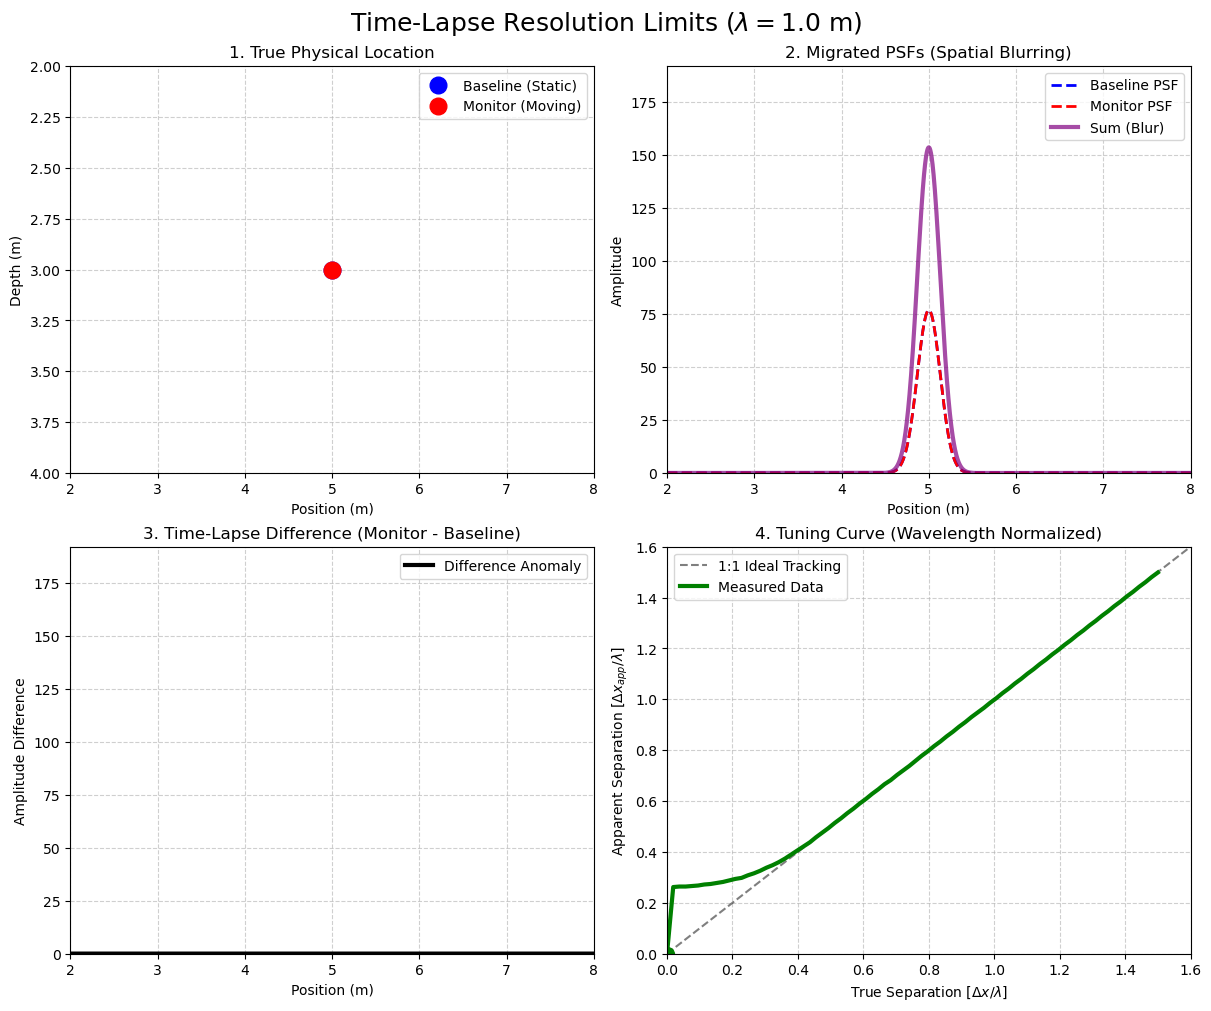

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
v = 0.1                     # Velocity (m/ns)
f_c = 0.1                   # Center frequency (100 MHz)
wavelength = v / f_c        # Wavelength = 1.0 m

z_target = 3.0
x_base = 5.0                

x_mon_start = 3.5
x_mon_end = 5.0
num_frames = 80
x_mon_positions = np.linspace(x_mon_start, x_mon_end, num_frames)

true_separations = np.abs(x_mon_positions - x_base)
apparent_separations = np.full(num_frames, np.nan) 

# B-Scan Acquisition Grid 
nx_bscan = 150
x_bscan = np.linspace(0, 10, nx_bscan)

# INCREASED TEMPORAL RESOLUTION (Prevents jagged linear interpolation)
t_max, nt = 160, 2000
time_axis = np.linspace(0, t_max, nt)

# INCREASED SPATIAL RESOLUTION (Prevents pixel-snapping in argmax)
nx_slice = 3000
x_slice = np.linspace(2, 8, nx_slice)

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def generate_bscan(x_tgt):
    b_scan = np.zeros((nt, nx_bscan))
    for i, x_tr in enumerate(x_bscan):
        dist = np.sqrt((x_tr - x_tgt)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
    return b_scan

def migrate_1d_slice(b_scan):
    psf_slice = np.zeros(nx_slice)
    for i, x_tr in enumerate(x_bscan):
        dist_grid = np.sqrt((x_slice - x_tr)**2 + z_target**2)
        t_grid = 2 * dist_grid / v
        contribution = np.interp(t_grid, time_axis, b_scan[:, i])
        contribution *= (z_target / dist_grid)  
        psf_slice += contribution
    return psf_slice

# ==========================================
# 2. Pre-Calculate the Baseline PSF
# ==========================================
bscan_base = generate_bscan(x_base)
psf_base = migrate_1d_slice(bscan_base)

# ==========================================
# 3. Figure Setup (2x2 Grid)
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
fig.suptitle(f'Time-Lapse Resolution Limits ($\lambda = {wavelength:.1f}$ m)', fontsize=18)

# --- Panel 1: Physical Model ---
axs[0,0].set_title('1. True Physical Location')
axs[0,0].set_xlim(2, 8)
axs[0,0].set_ylim(4, 2)  
axs[0,0].set_xlabel('Position (m)')
axs[0,0].set_ylabel('Depth (m)')
axs[0,0].grid(True, linestyle='--', alpha=0.6)
axs[0,0].plot(x_base, z_target, 'bo', markersize=12, label='Baseline (Static)')
true_mon, = axs[0,0].plot([], [], 'ro', markersize=12, label='Monitor (Moving)')
axs[0,0].legend(loc='upper right')

# --- Panel 2: Lateral PSF Cross-Sections ---
axs[0,1].set_title('2. Migrated PSFs (Spatial Blurring)')
axs[0,1].set_xlim(2, 8)
axs[0,1].set_ylim(np.min(psf_base)*2.5, np.max(psf_base)*2.5)
axs[0,1].set_xlabel('Position (m)')
axs[0,1].set_ylabel('Amplitude')
axs[0,1].grid(True, linestyle='--', alpha=0.6)
axs[0,1].plot(x_slice, psf_base, 'b--', linewidth=2, label='Baseline PSF')
line_mon, = axs[0,1].plot([], [], 'r--', linewidth=2, label='Monitor PSF')
line_sum, = axs[0,1].plot([], [], 'purple', linewidth=3, alpha=0.7, label='Sum (Blur)')
axs[0,1].legend(loc='upper right')

# --- Panel 3: Time-Lapse Difference ---
axs[1,0].set_title('3. Time-Lapse Difference (Monitor - Baseline)')
axs[1,0].set_xlim(2, 8)
axs[1,0].set_ylim(np.min(psf_base)*2.5, np.max(psf_base)*2.5)
axs[1,0].set_xlabel('Position (m)')
axs[1,0].set_ylabel('Amplitude Difference')
axs[1,0].grid(True, linestyle='--', alpha=0.6)
line_diff, = axs[1,0].plot([], [], 'k-', linewidth=3, label='Difference Anomaly')
axs[1,0].legend(loc='upper right')

# --- Panel 4: Apparent vs True Separation ---
axs[1,1].set_title('4. Tuning Curve (Wavelength Normalized)')
axs[1,1].set_xlim(0, 1.6)
axs[1,1].set_ylim(0, 1.6)
axs[1,1].set_xlabel(r'True Separation [$\Delta x / \lambda$]')
axs[1,1].set_ylabel(r'Apparent Separation [$\Delta x_{app} / \lambda$]')
axs[1,1].grid(True, linestyle='--', alpha=0.6)

axs[1,1].plot([0, 1.6], [0, 1.6], 'k--', alpha=0.5, label='1:1 Ideal Tracking')
track_line, = axs[1,1].plot([], [], 'g-', linewidth=3, label='Measured Data')
current_dot, = axs[1,1].plot([], [], 'go', markersize=10)
axs[1,1].legend(loc='upper left')

# ==========================================
# 4. Animation Logic
# ==========================================
def update(frame):
    current_x = x_mon_positions[frame]
    true_sep = true_separations[frame]
    
    true_mon.set_data([current_x], [z_target])
    
    bscan_mon = generate_bscan(current_x)
    psf_mon = migrate_1d_slice(bscan_mon)
    diff_anomaly = psf_mon - psf_base
    
    line_mon.set_data(x_slice, psf_mon)
    line_sum.set_data(x_slice, psf_base + psf_mon)
    line_diff.set_data(x_slice, diff_anomaly)
    
    if np.max(np.abs(diff_anomaly)) < 1e-5:
        app_sep = 0.0
    else:
        idx_max = np.argmax(diff_anomaly)
        idx_min = np.argmin(diff_anomaly)
        app_sep = np.abs(x_slice[idx_max] - x_slice[idx_min])
        
    apparent_separations[frame] = app_sep
    
    track_line.set_data(true_separations[:frame+1] / wavelength, apparent_separations[:frame+1] / wavelength)
    current_dot.set_data([true_sep / wavelength], [app_sep / wavelength])
    
    return true_mon, line_mon, line_sum, line_diff, track_line, current_dot

ani = FuncAnimation(fig, update, frames=num_frames, interval=150, blit=True)
ani.save('TimeLapse_Differencing_Wavenumber.gif', writer='pillow', fps=8)
plt.show()

<>:77: SyntaxWarning: invalid escape sequence '\l'
<>:77: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30660\1021075825.py:77: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle(f'Normalized Time-Lapse GPR Limits ($\lambda = {wavelength:.1f}$ m)', fontsize=18)


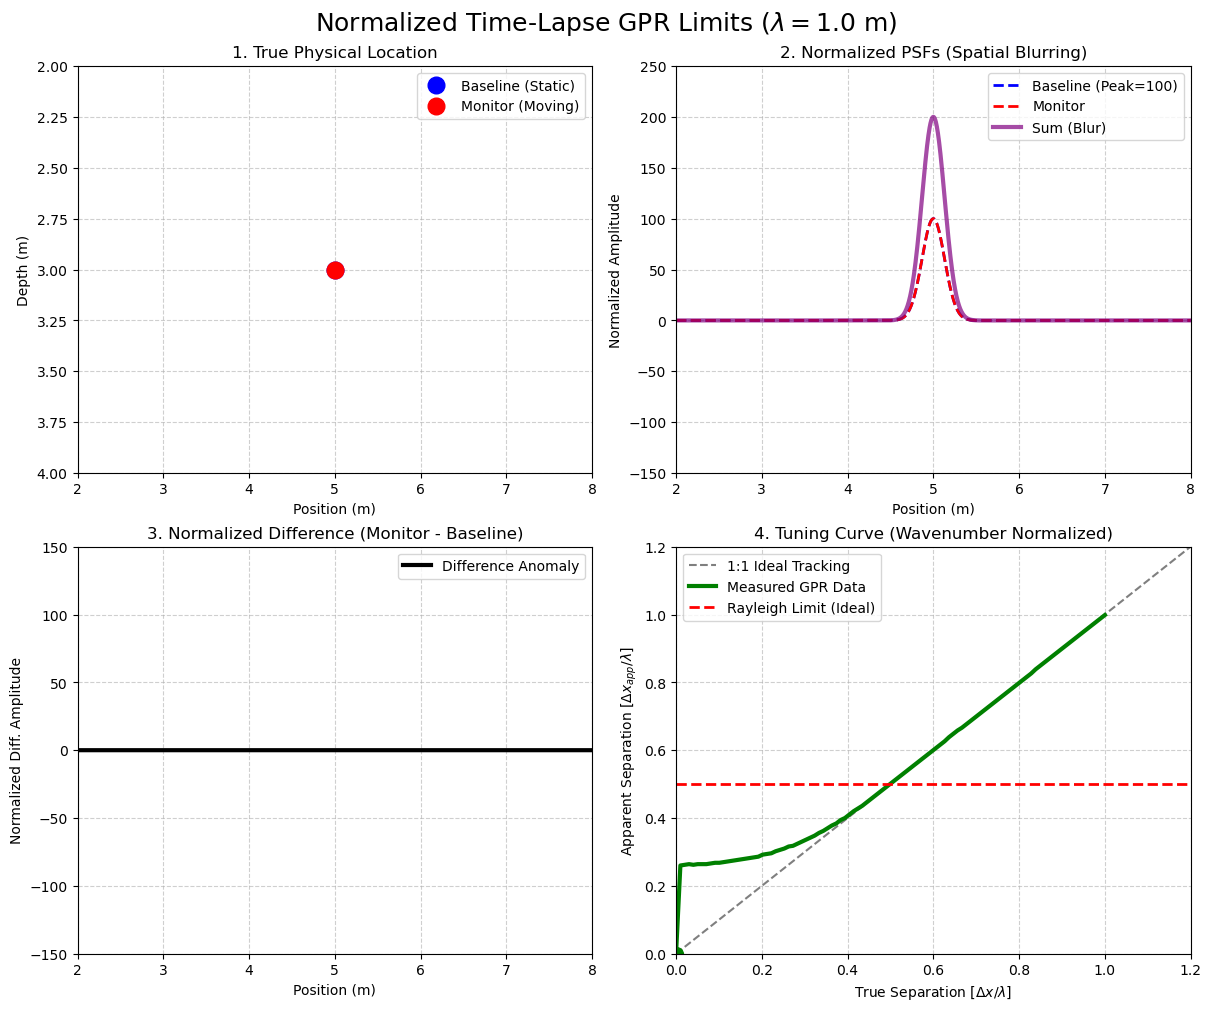

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
v = 0.1                     # Velocity (m/ns)
f_c = 0.1                   # Center frequency (100 MHz)
wavelength = v / f_c        # Wavelength = 1.0 m

z_target = 3.0
x_base = 5.0                # Baseline target is fixed at 5.0m

# --- REQUEST 2: BEGIN SEPARATION BY 1.0m ($\lambda$) ---
# true_separation_start = 1.0 * wavelength = 1.0m
# Start position: 5.0 - 1.0 = 4.0m
x_mon_start = 4.0
x_mon_end = 5.0             # Convergence position
num_frames = 100            # Increased frames for smoother slow movement
x_mon_positions = np.linspace(x_mon_start, x_mon_end, num_frames)

# Arrays to store separation data for Panel 4
true_separations = np.abs(x_mon_positions - x_base)
# Store normalized apparent separations initially as NaNs
apparent_separations_norm = np.full(num_frames, np.nan) 

# B-Scan Acquisition Grid (High Res to prevent quiver)
nx_bscan = 150
x_bscan = np.linspace(0, 10, nx_bscan)
t_max, nt = 160, 2000
time_axis = np.linspace(0, t_max, nt)

# 1D Migration Grid (Zoomed tightly, High Res to prevent grid snapping)
nx_slice = 3000
x_slice = np.linspace(2, 8, nx_slice)

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def generate_bscan(x_tgt):
    """Generates a raw B-scan for a given target position."""
    b_scan = np.zeros((nt, nx_bscan))
    for i, x_tr in enumerate(x_bscan):
        dist = np.sqrt((x_tr - x_tgt)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
    return b_scan

def migrate_1d_slice(b_scan):
    """Performs Kirchhoff Migration only along the horizontal 1D target depth."""
    psf_slice = np.zeros(nx_slice)
    for i, x_tr in enumerate(x_bscan):
        dist_grid = np.sqrt((x_slice - x_tr)**2 + z_target**2)
        t_grid = 2 * dist_grid / v
        contribution = np.interp(t_grid, time_axis, b_scan[:, i])
        contribution *= (z_target / dist_grid)  
        psf_slice += contribution
    return psf_slice

# ==========================================
# 2. Pre-Calculate the Baseline & Normalization Ref
# ==========================================
# Calculate un-normalized baseline PSF
bscan_base_raw = generate_bscan(x_base)
psf_base_raw = migrate_1d_slice(bscan_base_raw)

# --- REQUEST 1: NORMALIZE BASELINE PEAK TO 100 ---
# Ref_amp is the maximum absolute value of the baseline PSF
ref_amp_ref100 = np.max(np.abs(psf_base_raw))
psf_base_norm100 = (psf_base_raw / ref_amp_ref100) * 100.0

# ==========================================
# 3. Figure Setup (2x2 Grid)
# ==========================================
# interval=200ms gives a nice slow live animation
fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
fig.suptitle(f'Normalized Time-Lapse GPR Limits ($\lambda = {wavelength:.1f}$ m)', fontsize=18)

# --- Panel 1: Physical Model ---
axs[0,0].set_title('1. True Physical Location')
axs[0,0].set_xlim(2, 8)
axs[0,0].set_ylim(4, 2)  # Inverted depth axis
axs[0,0].set_xlabel('Position (m)')
axs[0,0].set_ylabel('Depth (m)')
axs[0,0].grid(True, linestyle='--', alpha=0.6)
axs[0,0].plot(x_base, z_target, 'bo', markersize=12, label='Baseline (Static)')
true_mon, = axs[0,0].plot([], [], 'ro', markersize=12, label='Monitor (Moving)')
axs[0,0].legend(loc='upper right')

# --- Panel 2: Lateral PSF Cross-Sections (Normalized) ---
axs[0,1].set_title('2. Normalized PSFs (Spatial Blurring)')
axs[0,1].set_xlim(2, 8)
# Limits are set just wider than 0 to -200 (Sum of baseline+monitor peaks)
axs[0,1].set_ylim(-150, 250) 
axs[0,1].set_xlabel('Position (m)')
axs[0,1].set_ylabel('Normalized Amplitude')
axs[0,1].grid(True, linestyle='--', alpha=0.6)
# Plot normalized fixed baseline
axs[0,1].plot(x_slice, psf_base_norm100, 'b--', linewidth=2, label='Baseline (Peak=100)')
# Dynamic lines
line_mon, = axs[0,1].plot([], [], 'r--', linewidth=2, label='Monitor')
line_sum, = axs[0,1].plot([], [], 'purple', linewidth=3, alpha=0.7, label='Sum (Blur)')
axs[0,1].legend(loc='upper right')

# --- Panel 3: Time-Lapse Difference (Normalized) ---
axs[1,0].set_title('3. Normalized Difference (Monitor - Baseline)')
axs[1,0].set_xlim(2, 8)
# Limits are set +/- ref (Difference of 100 - 100 peaks is 0, but side lobes differ)
axs[1,0].set_ylim(-150, 150)
axs[1,0].set_xlabel('Position (m)')
axs[1,0].set_ylabel('Normalized Diff. Amplitude')
axs[1,0].grid(True, linestyle='--', alpha=0.6)
line_diff, = axs[1,0].plot([], [], 'k-', linewidth=3, label='Difference Anomaly')
axs[1,0].legend(loc='upper right')

# --- Panel 4: Apparent vs True Separation (Normalized by Wavenumber) ---
axs[1,1].set_title('4. Tuning Curve (Wavenumber Normalized)')
# Start at 0, goes up to slightly beyond maximum movement start ($\lambda=1$)
axs[1,1].set_xlim(0, 1.2)
axs[1,1].set_ylim(0, 1.2)
axs[1,1].set_xlabel(r'True Separation [$\Delta x / \lambda$]')
axs[1,1].set_ylabel(r'Apparent Separation [$\Delta x_{app} / \lambda$]')
axs[1,1].grid(True, linestyle='--', alpha=0.6)

# Plot standard tracking lines
axs[1,1].plot([0, 1.2], [0, 1.2], 'k--', alpha=0.5, label='1:1 Ideal Tracking')
track_line, = axs[1,1].plot([], [], 'g-', linewidth=3, label='Measured GPR Data')
current_dot, = axs[1,1].plot([], [], 'go', markersize=10)

# --- REQUEST 3: PLOT RAYLEIGH LIMIT (0.5 lambda) ---
axs[1,1].axhline(0.5, color='red', linestyle='--', linewidth=2, label='Rayleigh Limit (Ideal)')

# Update legend after adding standard lines and the Rayleigh line
axs[1,1].legend(loc='upper left')

# ==========================================
# 4. Animation Logic
# ==========================================
def update(frame):
    current_x_mon = x_mon_positions[frame]
    true_sep = true_separations[frame]
    
    # Update Physical Marker
    true_mon.set_data([current_x_mon], [z_target])
    
    # 1. Compute new un-normalized monitor wavefield and migration
    bscan_mon_raw = generate_bscan(current_x_mon)
    psf_mon_raw = migrate_1d_slice(bscan_mon_raw)
    
    # --- REQUEST 1 CONT.: NORMALIZE USING REF_AMP ---
    # Convert all amplitudes to the Normalized (100 peak) scale
    psf_mon_norm100 = (psf_mon_raw / ref_amp_ref100) * 100.0
    # Difference uses normalized baseline pre-calculated outside loop
    diff_anomaly_norm100 = psf_mon_norm100 - psf_base_norm100
    
    # 2. Update PSF and Difference Plots (Using Norm100 data)
    line_mon.set_data(x_slice, psf_mon_norm100)
    line_sum.set_data(x_slice, psf_base_norm100 + psf_mon_norm100) # Blurring sum
    line_diff.set_data(x_slice, diff_anomaly_norm100)
    
    # 3. Calculate Apparent Separation using High-Res Normalized Difference
    # We find the indices of max and min peaks of the difference dipole
    # Handling strict overlap case to prevent argmax failure if diff is absolute zero
    if np.max(np.abs(diff_anomaly_norm100)) < 1e-4:
        app_sep_physical = 0.0
    else:
        # High Res spatial grid prevents quantization quiver in app_sep calculation
        idx_max = np.argmax(diff_anomaly_norm100)
        idx_min = np.argmin(diff_anomaly_norm100)
        # Convert index distance to physical meters separation
        app_sep_physical = np.abs(x_slice[idx_max] - x_slice[idx_min])
        
    # Store normalized apparent separation data
    # (Divide physical apparent separation by wavelength $\lambda=1$)
    apparent_separations_norm[frame] = app_sep_physical / wavelength
    
    # 4. Update the Tracking Plot (Axes are normalized $\Delta x / \lambda$)
    # track_line draws progressively
    track_line.set_data(true_separations[:frame+1] / wavelength, apparent_separations_norm[:frame+1])
    # current_dot highlights exact frame position
    current_dot.set_data([true_sep / wavelength], [app_sep_physical / wavelength])
    
    return true_mon, line_mon, line_sum, line_diff, track_line, current_dot

# Run slow live animation
ani = FuncAnimation(fig, update, frames=num_frames, interval=200, blit=True)

# Save Slow GIF for presentation (fps=5 ensures slow speed matches interval)
ani.save('Normalized_GPR_TimeLapse_Rayleigh.gif', writer='pillow', fps=5)

plt.show()

<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:92: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30660\3162772042.py:92: SyntaxWarning: invalid escape sequence '\D'
  fig.suptitle(f'Spatial to Wavenumber Domain Analysis ($\Delta x = {x_mon - x_base}$ m)', fontsize=18)


Migrating Baseline...
Migrating Monitor...


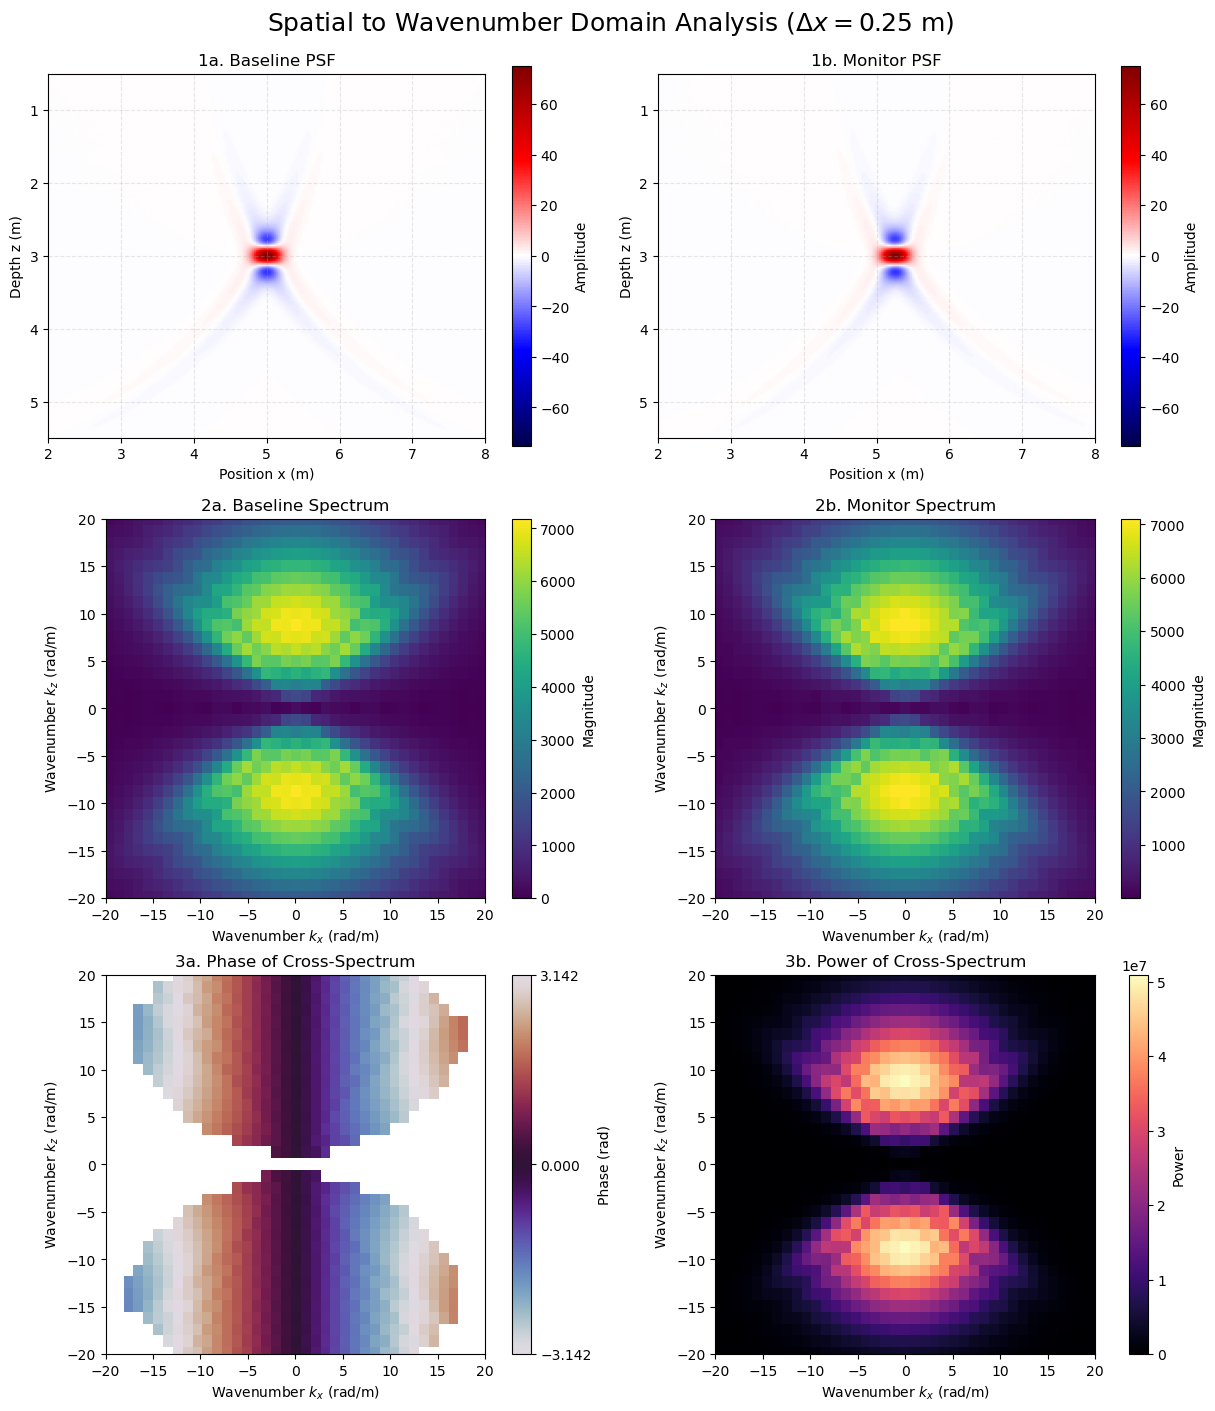

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
v = 0.1                     # Velocity (m/ns)
f_c = 0.1                   # Center frequency (100 MHz)
wavelength = v / f_c        # 1.0 m

z_target = 3.0
x_base = 5.0                # Baseline position
x_mon = 5.25                 # Monitor position (Shifted by 0.5m, half a wavelength)

# B-Scan Grid
nx_bscan = 150
x_bscan = np.linspace(0, 10, nx_bscan)
t_max, nt = 160, 800
time_axis = np.linspace(0, t_max, nt)

# 2D Migration Grid (Dense square grid for a clean 2D FFT)
nx_mig, nz_mig = 200, 200
x_mig = np.linspace(2, 8, nx_mig)
z_mig = np.linspace(0.5, 5.5, nz_mig)
X_mig, Z_mig = np.meshgrid(x_mig, z_mig)

dx_mig = x_mig[1] - x_mig[0]
dz_mig = z_mig[1] - z_mig[0]

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def generate_bscan(x_tgt):
    b_scan = np.zeros((nt, nx_bscan))
    for i, x_tr in enumerate(x_bscan):
        dist = np.sqrt((x_tr - x_tgt)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
    return b_scan

def migrate_2d(b_scan):
    img = np.zeros((nz_mig, nx_mig))
    for i, x_tr in enumerate(x_bscan):
        dist_grid = np.sqrt((X_mig - x_tr)**2 + Z_mig**2)
        t_grid = 2 * dist_grid / v
        contribution = np.interp(t_grid.ravel(), time_axis, b_scan[:, i]).reshape(nz_mig, nx_mig)
        contribution *= (Z_mig / dist_grid)
        img += contribution
    return img

# ==========================================
# 2. Generate Spatial Domain Images (Row 1)
# ==========================================
print("Migrating Baseline...")
img_base = migrate_2d(generate_bscan(x_base))

print("Migrating Monitor...")
img_mon = migrate_2d(generate_bscan(x_mon))

# ==========================================
# 3. Transform to Wavenumber Domain (Row 2)
# ==========================================
# Compute 2D FFT and shift the zero-frequency component to the center
F_base = np.fft.fftshift(np.fft.fft2(img_base))
F_mon = np.fft.fftshift(np.fft.fft2(img_mon))

# Calculate wavenumber axes (rad/m)
kx = np.fft.fftshift(np.fft.fftfreq(nx_mig, d=dx_mig)) * 2 * np.pi
kz = np.fft.fftshift(np.fft.fftfreq(nz_mig, d=dz_mig)) * 2 * np.pi

# Compute magnitudes
mag_base = np.abs(F_base)
mag_mon = np.abs(F_mon)

# ==========================================
# 4. Compute Cross Spectrum (Row 3)
# ==========================================
# Cross Spectrum: S = F_mon * conj(F_base)
cross_spec = F_mon * np.conj(F_base)

power_cross = np.abs(cross_spec)
phase_cross = np.angle(cross_spec)

# Mask the phase data where the signal power is negligible (e.g., < 1% of max)
# This removes the random static phase noise outside the GPR bandwidth
threshold = 0.01 * np.max(power_cross)
phase_cross[power_cross < threshold] = np.nan

# ==========================================
# 5. Plotting
# ==========================================
fig, axs = plt.subplots(3, 2, figsize=(12, 14), constrained_layout=True)
fig.suptitle(f'Spatial to Wavenumber Domain Analysis ($\Delta x = {x_mon - x_base}$ m)', fontsize=18)

# --- Common Extents ---
extent_spatial = [x_mig.min(), x_mig.max(), z_mig.max(), z_mig.min()]
extent_k = [kx.min(), kx.max(), kz.min(), kz.max()]

# Zoom limits for wavenumber (k) axes to see the signal clearly
k_limit = 20  

# ---------------- ROW 1: Spatial Domain ----------------
v_max = np.max(np.abs(img_base))
for i, (ax, img, title) in enumerate(zip(axs[0], [img_base, img_mon], ['1a. Baseline PSF', '1b. Monitor PSF'])):
    im = ax.imshow(img, extent=extent_spatial, cmap='seismic', vmin=-v_max, vmax=v_max)
    ax.set_title(title)
    ax.set_xlabel('Position x (m)')
    ax.set_ylabel('Depth z (m)')
    ax.grid(True, linestyle='--', alpha=0.3)
    fig.colorbar(im, ax=ax, location='right', fraction=0.046, pad=0.04, label='Amplitude')

# ---------------- ROW 2: Wavenumber Magnitude ----------------
for ax, mag, title in zip(axs[1], [mag_base, mag_mon], ['2a. Baseline Spectrum', '2b. Monitor Spectrum']):
    # origin='lower' is critical here so negative kz stays at the bottom
    im = ax.imshow(mag, extent=extent_k, origin='lower', cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Wavenumber $k_x$ (rad/m)')
    ax.set_ylabel('Wavenumber $k_z$ (rad/m)')
    ax.set_xlim(-k_limit, k_limit)
    ax.set_ylim(-k_limit, k_limit)
    fig.colorbar(im, ax=ax, location='right', fraction=0.046, pad=0.04, label='Magnitude')

# ---------------- ROW 3: Cross Spectrum ----------------
# Phase of Cross Spectrum
im_phase = axs[2, 0].imshow(phase_cross, extent=extent_k, origin='lower', cmap='twilight', vmin=-np.pi, vmax=np.pi)
axs[2, 0].set_title('3a. Phase of Cross-Spectrum')
axs[2, 0].set_xlabel('Wavenumber $k_x$ (rad/m)')
axs[2, 0].set_ylabel('Wavenumber $k_z$ (rad/m)')
axs[2, 0].set_xlim(-k_limit, k_limit)
axs[2, 0].set_ylim(-k_limit, k_limit)
fig.colorbar(im_phase, ax=axs[2, 0], location='right', fraction=0.046, pad=0.04, label='Phase (rad)', ticks=[-np.pi, 0, np.pi])

# Power of Cross Spectrum
im_power = axs[2, 1].imshow(power_cross, extent=extent_k, origin='lower', cmap='magma')
axs[2, 1].set_title('3b. Power of Cross-Spectrum')
axs[2, 1].set_xlabel('Wavenumber $k_x$ (rad/m)')
axs[2, 1].set_ylabel('Wavenumber $k_z$ (rad/m)')
axs[2, 1].set_xlim(-k_limit, k_limit)
axs[2, 1].set_ylim(-k_limit, k_limit)
fig.colorbar(im_power, ax=axs[2, 1], location='right', fraction=0.046, pad=0.04, label='Power')

plt.show()

<>:184: SyntaxWarning: invalid escape sequence '\D'
<>:184: SyntaxWarning: invalid escape sequence '\l'
<>:221: SyntaxWarning: invalid escape sequence '\D'
<>:221: SyntaxWarning: invalid escape sequence '\l'
<>:184: SyntaxWarning: invalid escape sequence '\D'
<>:184: SyntaxWarning: invalid escape sequence '\l'
<>:221: SyntaxWarning: invalid escape sequence '\D'
<>:221: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30660\719156398.py:184: SyntaxWarning: invalid escape sequence '\D'
  print(f"Frame {frame}/{num_frames}: Moving to x={current_x_mon:.2f}m ($\Delta x = {true_shift_wvl:.2f} \lambda$)")
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30660\719156398.py:184: SyntaxWarning: invalid escape sequence '\l'
  print(f"Frame {frame}/{num_frames}: Moving to x={current_x_mon:.2f}m ($\Delta x = {true_shift_wvl:.2f} \lambda$)")
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30660\719156398.py:221: SyntaxWarning: invalid escape sequ

Pre-Calculating Baseline Images...


Frame 0/60: Moving to x=4.75m ($\Delta x = -0.25 \lambda$)
Frame 0/60: Moving to x=4.75m ($\Delta x = -0.25 \lambda$)

Exporting Animation to GIF... (this will take a minute)
Frame 0/60: Moving to x=4.75m ($\Delta x = -0.25 \lambda$)
Frame 0/60: Moving to x=4.75m ($\Delta x = -0.25 \lambda$)
Frame 5/60: Moving to x=4.79m ($\Delta x = -0.21 \lambda$)
Frame 10/60: Moving to x=4.83m ($\Delta x = -0.17 \lambda$)
Frame 15/60: Moving to x=4.88m ($\Delta x = -0.12 \lambda$)
Frame 20/60: Moving to x=4.92m ($\Delta x = -0.08 \lambda$)
Frame 25/60: Moving to x=4.96m ($\Delta x = -0.04 \lambda$)
Frame 30/60: Moving to x=5.00m ($\Delta x = 0.00 \lambda$)
Frame 35/60: Moving to x=5.05m ($\Delta x = 0.05 \lambda$)
Frame 40/60: Moving to x=5.09m ($\Delta x = 0.09 \lambda$)
Frame 45/60: Moving to x=5.13m ($\Delta x = 0.13 \lambda$)
Frame 50/60: Moving to x=5.17m ($\Delta x = 0.17 \lambda$)
Frame 55/60: Moving to x=5.22m ($\Delta x = 0.22 \lambda$)
Save complete! View 'GPR_Fourier_Shift_Analysis.gif'.


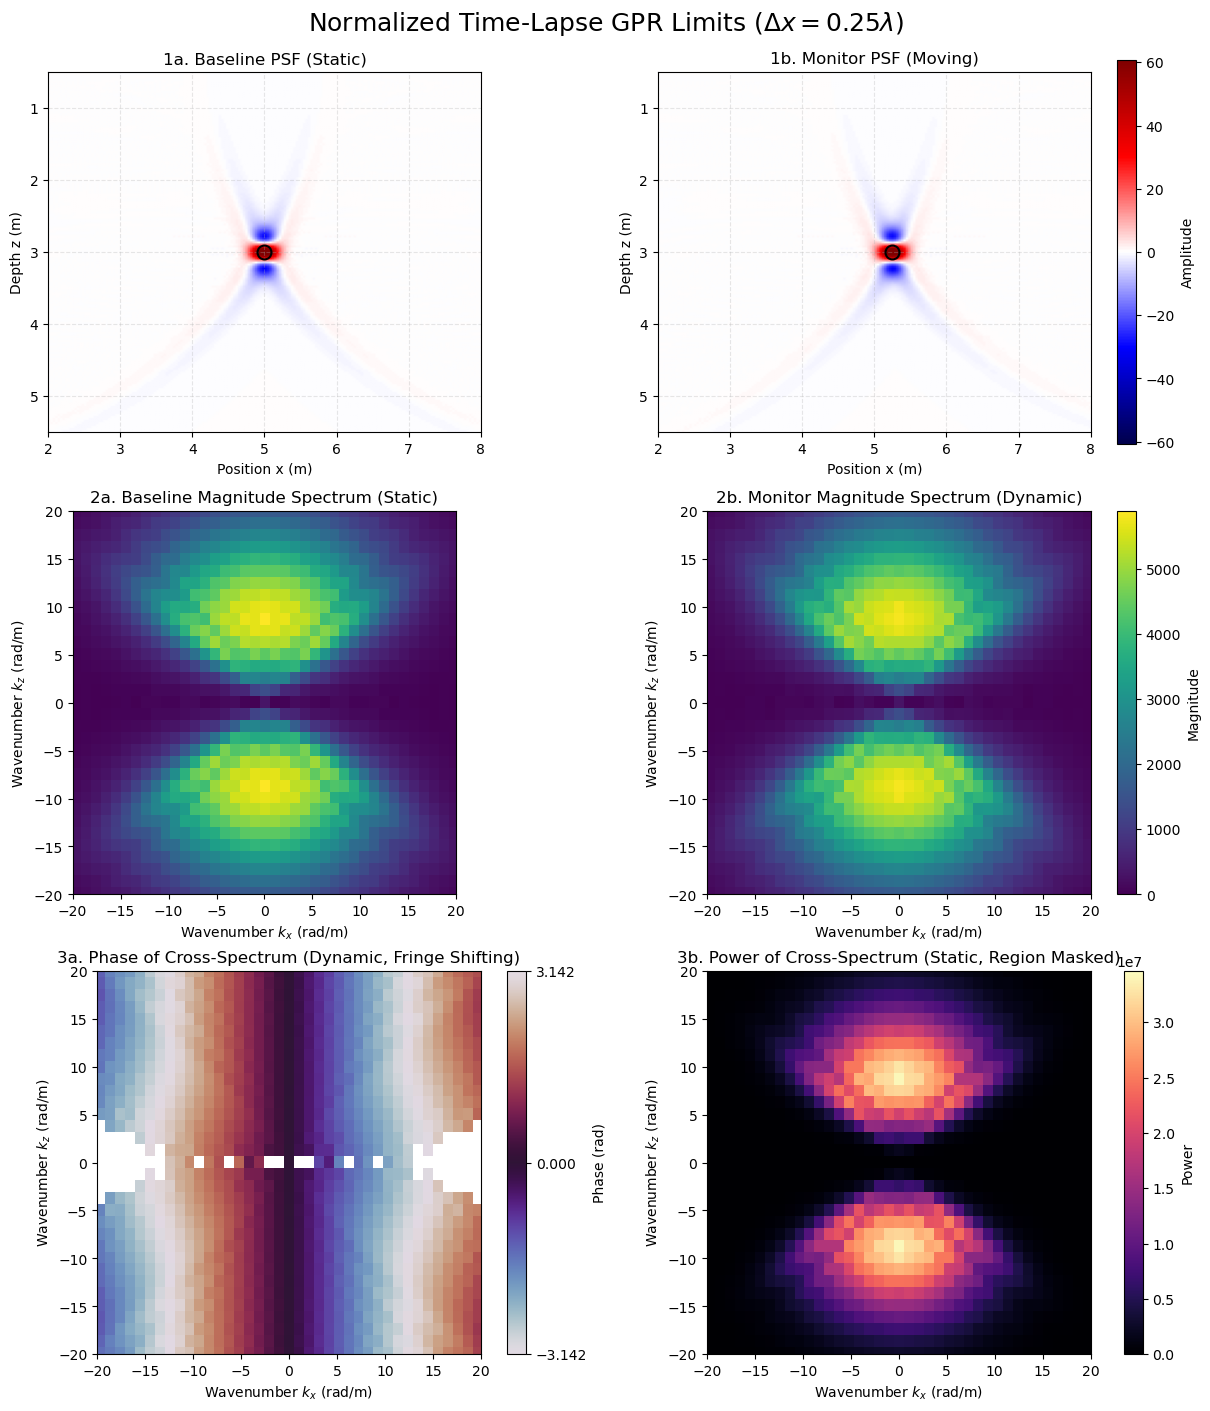

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
v = 0.1                     # Velocity (m/ns)
f_c = 0.1                   # Center frequency (100 MHz)
wavelength = v / f_c        # Wavelength = 1.0 m

z_target = 3.0
x_base = 5.0                # Baseline position (Static)

# --- Sub-wavelength movement parameters ---
x_start = 4.75              # Monitor starts here
x_end = 5.25                # Monitor ends here (Total shift = 0.5 lambda)
num_frames = 60
x_mon_positions = np.linspace(x_start, x_end, num_frames)

# B-Scan Grid (Wide aperture)
nx_bscan = 150
x_bscan = np.linspace(0, 10, nx_bscan)
t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)
dt = time_axis[1] - time_axis[0]

# 2D Migration Grid (Dense for Fourier quality)
nx_mig, nz_mig = 180, 180
x_mig = np.linspace(2, 8, nx_mig)
z_mig = np.linspace(0.5, 5.5, nz_mig)
X_mig, Z_mig = np.meshgrid(x_mig, z_mig)
dx_mig = x_mig[1] - x_mig[0]
dz_mig = z_mig[1] - z_mig[0]

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def generate_bscan(x_tgt):
    """Generates a raw B-scan for a given target position."""
    b_scan = np.zeros((nt, nx_bscan))
    for i, x_tr in enumerate(x_bscan):
        dist = np.sqrt((x_tr - x_tgt)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
    return b_scan

def migrate_2d(b_scan):
    """Performs Fast Kirchhoff Migration on the 2D grid."""
    img = np.zeros((nz_mig, nx_mig))
    # Optimized loop over receiver traces
    for i, x_tr in enumerate(x_bscan):
        # Calculate distance and TWT from current trace to *every* grid point
        dist_grid = np.sqrt((X_mig - x_tr)**2 + Z_mig**2)
        t_grid = 2 * dist_grid / v
        
        # Clip times to prevent interpolation errors
        t_grid_idx = np.clip(t_grid / dt, 0, nt - 1).astype(int)
        
        # Kirchhoff mapping with obliquity factor (z/r)
        contribution = b_scan[t_grid_idx, i] * (Z_mig / dist_grid)
        img += contribution
    return img

# ==========================================
# 2. Pre-Calculate the Fixed Baseline (Row 1L and 2L)
# ==========================================
print("Pre-Calculating Baseline Images...")
bscan_base = generate_bscan(x_base)
img_base = migrate_2d(bscan_base)
F_base = np.fft.fftshift(np.fft.fft2(img_base))

# Fourier Axes (rad/m)
kx = np.fft.fftshift(np.fft.fftfreq(nx_mig, d=dx_mig)) * 2 * np.pi
kz = np.fft.fftshift(np.fft.fftfreq(nz_mig, d=dz_mig)) * 2 * np.pi

# Threshold for masking phase noise (outside GPR bandwidth)
noise_floor_threshold = 1e-4

# ==========================================
# 3. Figure Setup (3x2 Grid)
# ==========================================
fig, axs = plt.subplots(3, 2, figsize=(12, 14), constrained_layout=True)
fig.suptitle('GPR Sub-Wavelength Displacement Analysis (Fourier Domain)', fontsize=18)

extent_spatial = [x_mig.min(), x_mig.max(), z_mig.max(), z_mig.min()]
extent_k = [kx.min(), kx.max(), kz.min(), kz.max()]
k_zoom = 20  # Wavenumber zoom for clarity

# --- ROW 1: Spatial Domain (Fixed vs Moving) ---
# Limits derived from baseline max amplitude
v_max_mig = np.max(np.abs(img_base)) * 0.8 # Zoom slightly for visibility

# 1a: Baseline (Static)
axs[0, 0].set_title('1a. Baseline PSF (Static)')
axs[0, 0].imshow(img_base, extent=extent_spatial, cmap='seismic', vmin=-v_max_mig, vmax=v_max_mig)
# Reference crosshair
axs[0, 0].plot(x_base, z_target, 'ko', markerfacecolor='none', markersize=10, markeredgewidth=1.5)
axs[0, 0].grid(True, linestyle='--', alpha=0.3)

# 1b: Monitor (Moving)
axs[0, 1].set_title('1b. Monitor PSF (Moving)')
# Initial frame data for 1b
im_mig_mon = axs[0, 1].imshow(img_base, extent=extent_spatial, cmap='seismic', vmin=-v_max_mig, vmax=v_max_mig)
axs[0, 1].grid(True, linestyle='--', alpha=0.3)
# Tracking crosshair
mon_dot, = axs[0, 1].plot([], [], 'ko', markerfacecolor='none', markersize=10, markeredgewidth=1.5)

# Common labels for Row 1
for ax in axs[0]:
    ax.set_xlabel('Position x (m)')
    ax.set_ylabel('Depth z (m)')
    ax.set_xlim(x_mig.min(), x_mig.max())
    ax.set_ylim(z_mig.max(), z_mig.min()) # Inverted Depth

# --- ROW 2: Wavenumber Magnitude (Invariance) ---
mag_base = np.abs(F_base)
v_max_fk = np.max(mag_base)

# 2a: Baseline Magnitude (Static)
axs[1, 0].set_title('2a. Baseline Magnitude Spectrum (Static)')
# origin='lower' keeps negative kz at bottom
axs[1, 0].imshow(mag_base, extent=extent_k, origin='lower', cmap='viridis', vmin=0, vmax=v_max_fk)

# 2b: Monitor Magnitude (Dynamic, but visualy invariant)
axs[1, 1].set_title('2b. Monitor Magnitude Spectrum (Dynamic)')
im_mag_mon = axs[1, 1].imshow(mag_base, extent=extent_k, origin='lower', cmap='viridis', vmin=0, vmax=v_max_fk)

# Common labels for Row 2
for ax in axs[1]:
    ax.set_xlabel('Wavenumber $k_x$ (rad/m)')
    ax.set_ylabel('Wavenumber $k_z$ (rad/m)')
    ax.set_xlim(-k_zoom, k_zoom)
    ax.set_ylim(-k_zoom, k_zoom)

# ==========================================
# 3. Figure Setup (3x2 Grid)
# ==========================================
# ... (preceding figure code) ...

# --- ROW 3: Cross Spectrum (Phase vs Power) ---
# 3a: Phase (Dynamic, key result)
axs[2, 0].set_title('3a. Phase of Cross-Spectrum (Dynamic, Fringe Shifting)')

# --- FIX START ---
# Use np.zeros(F_base.shape, dtype=float) to ensure the initial data is float
im_phase = axs[2, 0].imshow(np.zeros(F_base.shape, dtype=float), extent=extent_k, origin='lower', cmap='twilight', vmin=-np.pi, vmax=np.pi)
# --- FIX END ---

## 3b: Power (Static, visualy invariant)
axs[2, 1].set_title('3b. Power of Cross-Spectrum (Static, Region Masked)')

# --- THE FIX ---
# Calculate the expected maximum power (magnitude squared)
v_max_power = v_max_fk**2

# Explicitly set vmin and vmax so the color scale doesn't saturate
im_power = axs[2, 1].imshow(np.zeros(F_base.shape, dtype=float), 
                            extent=extent_k, origin='lower', cmap='magma', 
                            vmin=0, vmax=v_max_power)
# Common labels for Row 3
for ax in axs[2]:
    ax.set_xlabel('Wavenumber $k_x$ (rad/m)')
    ax.set_ylabel('Wavenumber $k_z$ (rad/m)')
    ax.set_xlim(-k_zoom, k_zoom)
    ax.set_ylim(-k_zoom, k_zoom)

# Add colorbars for each measurement type
fig.colorbar(im_mig_mon, ax=axs[0, 1], label='Amplitude', fraction=0.046, pad=0.04)
fig.colorbar(im_mag_mon, ax=axs[1, 1], label='Magnitude', fraction=0.046, pad=0.04)
fig.colorbar(im_phase, ax=axs[2, 0], label='Phase (rad)', fraction=0.046, pad=0.04, ticks=[-np.pi, 0, np.pi])
fig.colorbar(im_power, ax=axs[2, 1], label='Power', fraction=0.046, pad=0.04)

# ==========================================
# 4. Animation Logic
# ==========================================
def update(frame):
    current_x_mon = x_mon_positions[frame]
    true_shift = current_x_mon - x_base
    true_shift_wvl = true_shift / wavelength
    
    # Process Frame (Run heavy migration for every frame)
    # Status prints help manage long run times
    if frame % 5 == 0:
        print(f"Frame {frame}/{num_frames}: Moving to x={current_x_mon:.2f}m ($\Delta x = {true_shift_wvl:.2f} \lambda$)")
        
    bscan_mon = generate_bscan(current_x_mon)
    img_mon = migrate_2d(bscan_mon)
    F_mon = np.fft.fftshift(np.fft.fft2(img_mon))
    
    # ----------------------------------------
    # Fourier Analysis
    # ----------------------------------------
    # Magnitude
    mag_mon = np.abs(F_mon)
    
    # Cross Spectrum S = F_mon * conj(F_base)
    cross_spec = F_mon * np.conj(F_base)
    power_cross = np.abs(cross_spec)
    phase_cross = np.angle(cross_spec)
    
    # Phase Masking (Remove high-frequency noise outside bandwidth)
    # Mask data where power is < fraction of max power
    mask_val = np.max(power_cross) * noise_floor_threshold
    phase_cross[power_cross < mask_val] = np.nan # NaN is transparent in 'twilight' cmap
    
    # ----------------------------------------
    # Update Plots
    # ----------------------------------------
    # Row 1: Spatial
    im_mig_mon.set_data(img_mon)
    mon_dot.set_data([current_x_mon], [z_target])
    
    # Row 2: Magnitude
    im_mag_mon.set_data(mag_mon)
    
    # Row 3: Cross Spectrum
    im_phase.set_data(phase_cross)
    im_power.set_data(power_cross)
    
    # Update title dynamically to show shift
    fig.suptitle(f'Normalized Time-Lapse GPR Limits ($\Delta x = {true_shift_wvl:.2f} \lambda$)', fontsize=18)
    
    return im_mig_mon, mon_dot, im_mag_mon, im_phase, im_power

# Set a very large interval (500ms) for live viewing if desired
ani = FuncAnimation(fig, update, frames=num_frames, interval=500, blit=True)

# ==========================================
# 5. Export to GIF (Recommended)
# ==========================================
# Warning: Pre-calculating 60 migrated images may take 1-2 minutes.
print("\nExporting Animation to GIF... (this will take a minute)")
writer = PillowWriter(fps=10)
ani.save('GPR_Fourier_Shift_Analysis.gif', writer=writer)
print("Save complete! View 'GPR_Fourier_Shift_Analysis.gif'.")

plt.show() # Live view window often hangs during export

Pre-Calculating Baseline Images...
Frame 0/60: Moving to x=4.75m
Frame 0/60: Moving to x=4.75m

Exporting Animation to GIF... (this will take a minute)
Frame 0/60: Moving to x=4.75m
Frame 0/60: Moving to x=4.75m


Frame 5/60: Moving to x=4.79m
Frame 10/60: Moving to x=4.83m
Frame 15/60: Moving to x=4.88m
Frame 20/60: Moving to x=4.92m
Frame 25/60: Moving to x=4.96m
Frame 30/60: Moving to x=5.00m
Frame 35/60: Moving to x=5.05m
Frame 40/60: Moving to x=5.09m
Frame 45/60: Moving to x=5.13m
Frame 50/60: Moving to x=5.17m
Frame 55/60: Moving to x=5.22m
Processing complete.


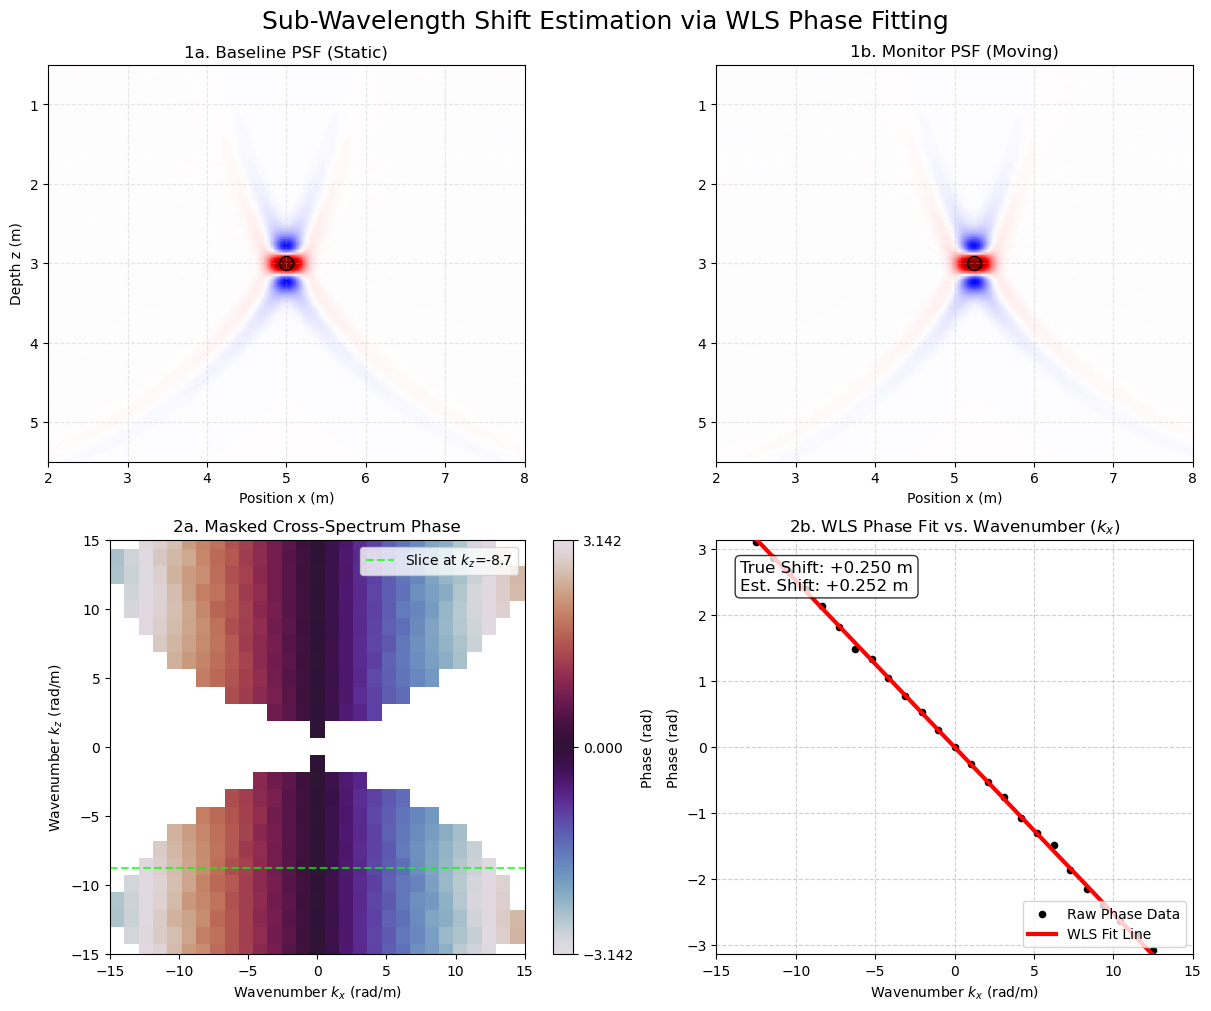

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
v = 0.1                     # Velocity (m/ns)
f_c = 0.1                   # Center frequency (100 MHz)
wavelength = v / f_c        # Wavelength = 1.0 m

z_target = 3.0
x_base = 5.0                # Baseline position (Static)

# --- Sub-wavelength movement parameters ---
# Moving from 4.75m to 5.25m ensures a max shift of +/- 0.25m 
# This stays well within +/- Pi phase to prevent wrapping issues in the 1D fit
x_start = 4.75              
x_end = 5.25                
num_frames = 60
x_mon_positions = np.linspace(x_start, x_end, num_frames)

# B-Scan Grid
nx_bscan = 150
x_bscan = np.linspace(0, 10, nx_bscan)
t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)
dt = time_axis[1] - time_axis[0]

# 2D Migration Grid (Dense for Fourier quality)
nx_mig, nz_mig = 150, 150
x_mig = np.linspace(2, 8, nx_mig)
z_mig = np.linspace(0.5, 5.5, nz_mig)
X_mig, Z_mig = np.meshgrid(x_mig, z_mig)
dx_mig = x_mig[1] - x_mig[0]
dz_mig = z_mig[1] - z_mig[0]

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def generate_bscan(x_tgt):
    b_scan = np.zeros((nt, nx_bscan))
    for i, x_tr in enumerate(x_bscan):
        dist = np.sqrt((x_tr - x_tgt)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
    return b_scan

def migrate_2d(b_scan):
    img = np.zeros((nz_mig, nx_mig))
    for i, x_tr in enumerate(x_bscan):
        dist_grid = np.sqrt((X_mig - x_tr)**2 + Z_mig**2)
        t_grid = 2 * dist_grid / v
        t_grid_idx = np.clip(t_grid / dt, 0, nt - 1).astype(int)
        contribution = b_scan[t_grid_idx, i] * (Z_mig / dist_grid)
        img += contribution
    return img

# ==========================================
# 2. Pre-Calculate the Baseline & Reference kz
# ==========================================
print("Pre-Calculating Baseline Images...")
bscan_base = generate_bscan(x_base)
img_base = migrate_2d(bscan_base)
F_base = np.fft.fftshift(np.fft.fft2(img_base))
power_base = np.abs(F_base)**2

# Fourier Axes (rad/m)
kx = np.fft.fftshift(np.fft.fftfreq(nx_mig, d=dx_mig)) * 2 * np.pi
kz = np.fft.fftshift(np.fft.fftfreq(nz_mig, d=dz_mig)) * 2 * np.pi

# Find the peak kz row in the baseline to extract our 1D slice reliably
kz_peak_idx = np.unravel_index(np.argmax(power_base), power_base.shape)[0]
kz_peak_val = kz[kz_peak_idx]

# Threshold for masking phase noise (5% of max power for a clean fit)
noise_floor_threshold = 0.05 

# ==========================================
# 3. Figure Setup (2x2 Grid)
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
fig.suptitle('Sub-Wavelength Shift Estimation via WLS Phase Fitting', fontsize=18)

extent_spatial = [x_mig.min(), x_mig.max(), z_mig.max(), z_mig.min()]
extent_k = [kx.min(), kx.max(), kz.min(), kz.max()]
k_zoom = 15  

# --- ROW 1: Spatial Domain ---
v_max_mig = np.max(np.abs(img_base)) * 0.8 

# 1a: Baseline (Static)
axs[0, 0].set_title('1a. Baseline PSF (Static)')
axs[0, 0].imshow(img_base, extent=extent_spatial, cmap='seismic', vmin=-v_max_mig, vmax=v_max_mig)
axs[0, 0].plot(x_base, z_target, 'ko', markerfacecolor='none', markersize=10)
axs[0, 0].set_xlabel('Position x (m)')
axs[0, 0].set_ylabel('Depth z (m)')
axs[0, 0].grid(True, linestyle='--', alpha=0.3)

# 1b: Monitor (Moving)
axs[0, 1].set_title('1b. Monitor PSF (Moving)')
im_mig_mon = axs[0, 1].imshow(img_base, extent=extent_spatial, cmap='seismic', vmin=-v_max_mig, vmax=v_max_mig)
mon_dot, = axs[0, 1].plot([], [], 'ko', markerfacecolor='none', markersize=10)
axs[0, 1].set_xlabel('Position x (m)')
axs[0, 1].grid(True, linestyle='--', alpha=0.3)

# --- ROW 2: Fourier Phase & WLS Fit ---

# 2a: 2D Cross-Spectrum Phase (Masked)
axs[1, 0].set_title('2a. Masked Cross-Spectrum Phase')
im_phase = axs[1, 0].imshow(np.zeros(F_base.shape, dtype=float), extent=extent_k, origin='lower', cmap='twilight', vmin=-np.pi, vmax=np.pi)
# Draw a dashed line to indicate where the 1D slice is taken
axs[1, 0].axhline(kz_peak_val, color='lime', linestyle='--', alpha=0.7, label=f'Slice at $k_z$={kz_peak_val:.1f}')
axs[1, 0].set_xlabel('Wavenumber $k_x$ (rad/m)')
axs[1, 0].set_ylabel('Wavenumber $k_z$ (rad/m)')
axs[1, 0].set_xlim(-k_zoom, k_zoom)
axs[1, 0].set_ylim(-k_zoom, k_zoom)
axs[1, 0].legend(loc='upper right')
fig.colorbar(im_phase, ax=axs[1, 0], label='Phase (rad)', fraction=0.046, pad=0.04, ticks=[-np.pi, 0, np.pi])

# 2b: 1D WLS Fit of Phase Slice
axs[1, 1].set_title('2b. WLS Phase Fit vs. Wavenumber ($k_x$)')
axs[1, 1].set_xlabel('Wavenumber $k_x$ (rad/m)')
axs[1, 1].set_ylabel('Phase (rad)')
axs[1, 1].set_xlim(-k_zoom, k_zoom)
axs[1, 1].set_ylim(-np.pi, np.pi)
axs[1, 1].grid(True, linestyle='--', alpha=0.6)

# Elements for the WLS plot
scatter_phase = axs[1, 1].scatter([], [], c='black', s=20, label='Raw Phase Data', zorder=2)
line_fit, = axs[1, 1].plot([], [], 'r-', linewidth=3, label='WLS Fit Line', zorder=3)

# Text box to show real-time quantitative shift estimation
text_box = axs[1, 1].text(0.05, 0.95, '', transform=axs[1, 1].transAxes, fontsize=12,
                          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axs[1, 1].legend(loc='lower right')

# ==========================================
# 4. Animation Logic
# ==========================================
def update(frame):
    current_x_mon = x_mon_positions[frame]
    true_shift = current_x_mon - x_base
    
    if frame % 5 == 0:
        print(f"Frame {frame}/{num_frames}: Moving to x={current_x_mon:.2f}m")
        
    bscan_mon = generate_bscan(current_x_mon)
    img_mon = migrate_2d(bscan_mon)
    F_mon = np.fft.fftshift(np.fft.fft2(img_mon))
    
    # Calculate Cross Spectrum
    cross_spec = F_mon * np.conj(F_base)
    power_cross = np.abs(cross_spec)
    phase_cross = np.angle(cross_spec)
    
    # 2D Masking based on power threshold
    mask_val = np.max(power_cross) * noise_floor_threshold
    phase_cross[power_cross < mask_val] = np.nan
    
    # EXTRACT 1D SLICE AT PEAK kz
    phase_1d = phase_cross[kz_peak_idx, :]
    power_1d = power_cross[kz_peak_idx, :]
    
    # Filter out NaNs for the WLS fit
    valid_mask = ~np.isnan(phase_1d)
    kx_valid = kx[valid_mask]
    phase_valid = phase_1d[valid_mask]
    power_valid = power_1d[valid_mask]
    
    estimated_shift = 0.0
    if len(kx_valid) > 2:
        # Weighted Least Squares (WLS) Fit (degree=1, weights=power)
        # np.polyfit weights minimize sum(w*(y - y_fit)^2), applying higher importance to high power kx values
        p = np.polyfit(kx_valid, phase_valid, deg=1, w=power_valid)
        
        # Calculate fit line across all kx for plotting
        fit_y = p[0] * kx + p[1]
        
        # Fourier shift theorem: phase = -k_x * dx, therefore slope = -dx
        estimated_shift = -p[0] 
    else:
        fit_y = np.zeros_like(kx)
    
    # Update visuals
    im_mig_mon.set_data(img_mon)
    mon_dot.set_data([current_x_mon], [z_target])
    im_phase.set_data(phase_cross)
    
    # Update scatter plot data (Requires setting an Nx2 array)
    scatter_data = np.c_[kx_valid, phase_valid]
    scatter_phase.set_offsets(scatter_data)
    
    # Update WLS fit line
    line_fit.set_data(kx, fit_y)
    
    # Update Text Box
    text_box.set_text(f"True Shift: {true_shift:+.3f} m\nEst. Shift: {estimated_shift:+.3f} m")
    
    return im_mig_mon, mon_dot, im_phase, scatter_phase, line_fit, text_box

ani = FuncAnimation(fig, update, frames=num_frames, interval=250, blit=True)

print("\nExporting Animation to GIF... (this will take a minute)")
writer = PillowWriter(fps=5)
ani.save('WLS_Phase_Fitting.gif', writer=writer)
print("Processing complete.")

plt.show()

Pre-Calculating Baseline Images...
Frame 0/60: Moving to z=2.75m
Frame 0/60: Moving to z=2.75m

Exporting Animation to GIF... (this will take a minute)
Frame 0/60: Moving to z=2.75m
Frame 0/60: Moving to z=2.75m
Frame 5/60: Moving to z=2.79m
Frame 10/60: Moving to z=2.83m
Frame 15/60: Moving to z=2.88m
Frame 20/60: Moving to z=2.92m
Frame 25/60: Moving to z=2.96m
Frame 30/60: Moving to z=3.00m
Frame 35/60: Moving to z=3.05m
Frame 40/60: Moving to z=3.09m
Frame 45/60: Moving to z=3.13m
Frame 50/60: Moving to z=3.17m
Frame 55/60: Moving to z=3.22m
Processing complete.


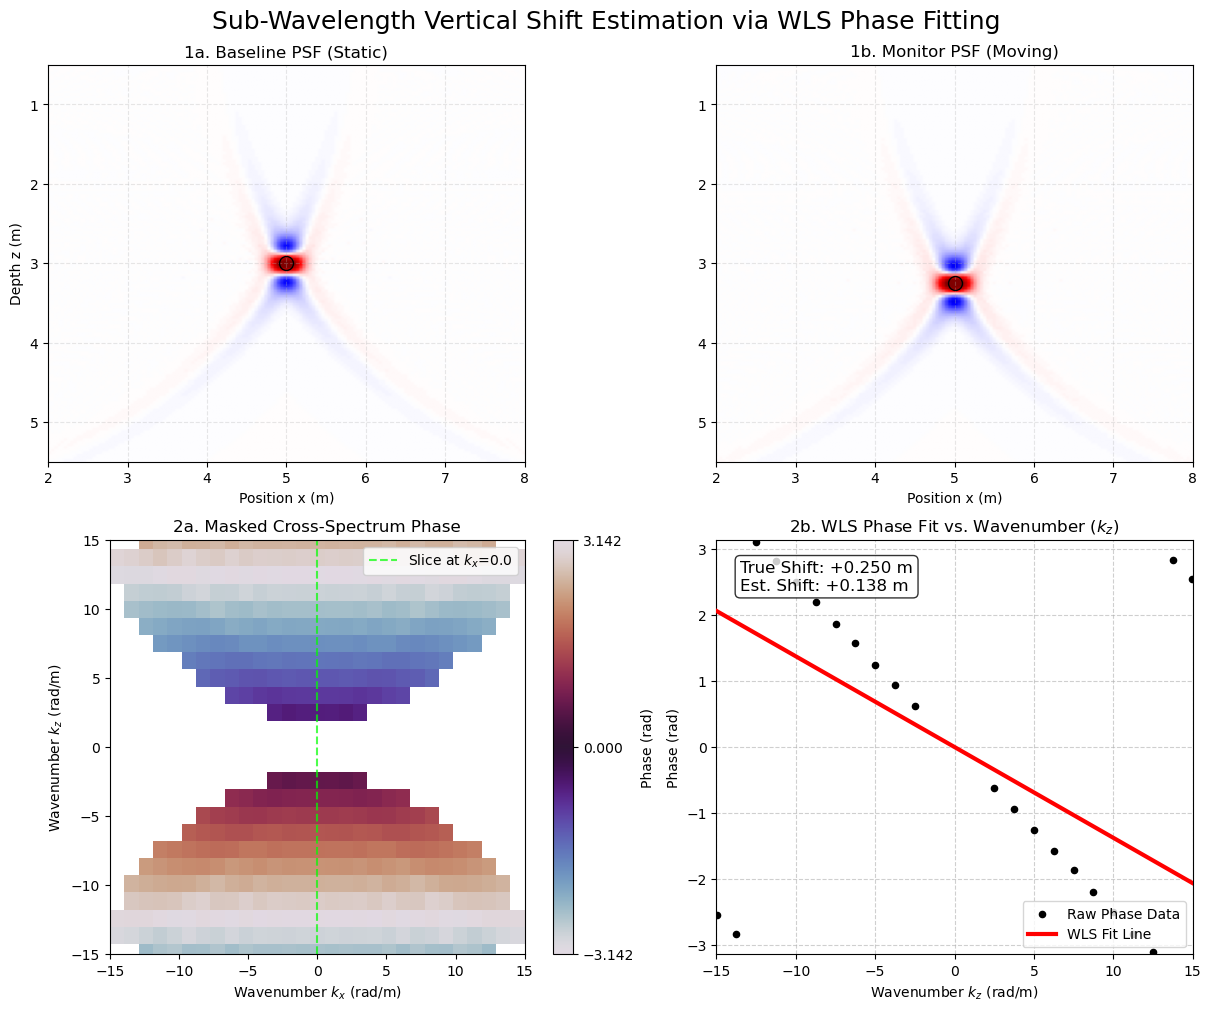

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
v = 0.1                     # Velocity (m/ns)
f_c = 0.1                   # Center frequency (100 MHz)
wavelength = v / f_c        # Wavelength = 1.0 m

x_target = 5.0              # Fixed lateral position
z_base = 3.0                # Baseline depth (Static)

# --- Sub-wavelength movement parameters ---
# Moving from 2.75m to 3.25m ensures a max vertical shift of +/- 0.25m 
z_start = 2.75              
z_end = 3.25                
num_frames = 60
z_mon_positions = np.linspace(z_start, z_end, num_frames)

# B-Scan Grid
nx_bscan = 150
x_bscan = np.linspace(0, 10, nx_bscan)
t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)
dt = time_axis[1] - time_axis[0]

# 2D Migration Grid (Dense for Fourier quality)
nx_mig, nz_mig = 150, 150
x_mig = np.linspace(2, 8, nx_mig)
z_mig = np.linspace(0.5, 5.5, nz_mig)
X_mig, Z_mig = np.meshgrid(x_mig, z_mig)
dx_mig = x_mig[1] - x_mig[0]
dz_mig = z_mig[1] - z_mig[0]

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def generate_bscan(z_tgt):
    b_scan = np.zeros((nt, nx_bscan))
    for i, x_tr in enumerate(x_bscan):
        dist = np.sqrt((x_tr - x_target)**2 + z_tgt**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_tgt / dist)**2
    return b_scan

def migrate_2d(b_scan):
    img = np.zeros((nz_mig, nx_mig))
    for i, x_tr in enumerate(x_bscan):
        dist_grid = np.sqrt((X_mig - x_tr)**2 + Z_mig**2)
        t_grid = 2 * dist_grid / v
        t_grid_idx = np.clip(t_grid / dt, 0, nt - 1).astype(int)
        contribution = b_scan[t_grid_idx, i] * (Z_mig / dist_grid)
        img += contribution
    return img

# ==========================================
# 2. Pre-Calculate the Baseline & Reference kx
# ==========================================
print("Pre-Calculating Baseline Images...")
bscan_base = generate_bscan(z_base)
img_base = migrate_2d(bscan_base)
F_base = np.fft.fftshift(np.fft.fft2(img_base))
power_base = np.abs(F_base)**2

# Fourier Axes (rad/m)
kx = np.fft.fftshift(np.fft.fftfreq(nx_mig, d=dx_mig)) * 2 * np.pi
kz = np.fft.fftshift(np.fft.fftfreq(nz_mig, d=dz_mig)) * 2 * np.pi

# Find the peak kx column in the baseline to extract our 1D slice reliably
kx_peak_idx = np.unravel_index(np.argmax(power_base), power_base.shape)[1]
kx_peak_val = kx[kx_peak_idx]

# Threshold for masking phase noise (5% of max power for a clean fit)
noise_floor_threshold = 0.05 

# ==========================================
# 3. Figure Setup (2x2 Grid)
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
fig.suptitle('Sub-Wavelength Vertical Shift Estimation via WLS Phase Fitting', fontsize=18)

extent_spatial = [x_mig.min(), x_mig.max(), z_mig.max(), z_mig.min()]
extent_k = [kx.min(), kx.max(), kz.min(), kz.max()]
k_zoom = 15  

# --- ROW 1: Spatial Domain ---
v_max_mig = np.max(np.abs(img_base)) * 0.8 

# 1a: Baseline (Static)
axs[0, 0].set_title('1a. Baseline PSF (Static)')
axs[0, 0].imshow(img_base, extent=extent_spatial, cmap='seismic', vmin=-v_max_mig, vmax=v_max_mig)
axs[0, 0].plot(x_target, z_base, 'ko', markerfacecolor='none', markersize=10)
axs[0, 0].set_xlabel('Position x (m)')
axs[0, 0].set_ylabel('Depth z (m)')
axs[0, 0].grid(True, linestyle='--', alpha=0.3)

# 1b: Monitor (Moving)
axs[0, 1].set_title('1b. Monitor PSF (Moving)')
im_mig_mon = axs[0, 1].imshow(img_base, extent=extent_spatial, cmap='seismic', vmin=-v_max_mig, vmax=v_max_mig)
mon_dot, = axs[0, 1].plot([], [], 'ko', markerfacecolor='none', markersize=10)
axs[0, 1].set_xlabel('Position x (m)')
axs[0, 1].grid(True, linestyle='--', alpha=0.3)

# --- ROW 2: Fourier Phase & WLS Fit ---

# 2a: 2D Cross-Spectrum Phase (Masked)
axs[1, 0].set_title('2a. Masked Cross-Spectrum Phase')
im_phase = axs[1, 0].imshow(np.zeros(F_base.shape, dtype=float), extent=extent_k, origin='lower', cmap='twilight', vmin=-np.pi, vmax=np.pi)
# Draw a dashed vertical line to indicate where the 1D slice is taken
axs[1, 0].axvline(kx_peak_val, color='lime', linestyle='--', alpha=0.7, label=f'Slice at $k_x$={kx_peak_val:.1f}')
axs[1, 0].set_xlabel('Wavenumber $k_x$ (rad/m)')
axs[1, 0].set_ylabel('Wavenumber $k_z$ (rad/m)')
axs[1, 0].set_xlim(-k_zoom, k_zoom)
axs[1, 0].set_ylim(-k_zoom, k_zoom)
axs[1, 0].legend(loc='upper right')
fig.colorbar(im_phase, ax=axs[1, 0], label='Phase (rad)', fraction=0.046, pad=0.04, ticks=[-np.pi, 0, np.pi])

# 2b: 1D WLS Fit of Phase Slice
axs[1, 1].set_title('2b. WLS Phase Fit vs. Wavenumber ($k_z$)')
axs[1, 1].set_xlabel('Wavenumber $k_z$ (rad/m)')
axs[1, 1].set_ylabel('Phase (rad)')
axs[1, 1].set_xlim(-k_zoom, k_zoom)
axs[1, 1].set_ylim(-np.pi, np.pi)
axs[1, 1].grid(True, linestyle='--', alpha=0.6)

# Elements for the WLS plot
scatter_phase = axs[1, 1].scatter([], [], c='black', s=20, label='Raw Phase Data', zorder=2)
line_fit, = axs[1, 1].plot([], [], 'r-', linewidth=3, label='WLS Fit Line', zorder=3)

# Text box to show real-time quantitative shift estimation
text_box = axs[1, 1].text(0.05, 0.95, '', transform=axs[1, 1].transAxes, fontsize=12,
                          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axs[1, 1].legend(loc='lower right')

# ==========================================
# 4. Animation Logic
# ==========================================
def update(frame):
    current_z_mon = z_mon_positions[frame]
    true_shift = current_z_mon - z_base
    
    if frame % 5 == 0:
        print(f"Frame {frame}/{num_frames}: Moving to z={current_z_mon:.2f}m")
        
    bscan_mon = generate_bscan(current_z_mon)
    img_mon = migrate_2d(bscan_mon)
    F_mon = np.fft.fftshift(np.fft.fft2(img_mon))
    
    # Calculate Cross Spectrum
    cross_spec = F_mon * np.conj(F_base)
    power_cross = np.abs(cross_spec)
    phase_cross = np.angle(cross_spec)
    
    # 2D Masking based on power threshold
    mask_val = np.max(power_cross) * noise_floor_threshold
    phase_cross[power_cross < mask_val] = np.nan
    
    # EXTRACT 1D SLICE AT PEAK kx
    phase_1d = phase_cross[:, kx_peak_idx]
    power_1d = power_cross[:, kx_peak_idx]
    
    # Filter out NaNs for the WLS fit
    valid_mask = ~np.isnan(phase_1d)
    kz_valid = kz[valid_mask]
    phase_valid = phase_1d[valid_mask]
    power_valid = power_1d[valid_mask]
    
    estimated_shift = 0.0
    if len(kz_valid) > 2:
        # Weighted Least Squares (WLS) Fit (degree=1, weights=power)
        p = np.polyfit(kz_valid, phase_valid, deg=1, w=power_valid)
        
        # Calculate fit line across all kz for plotting
        fit_y = p[0] * kz + p[1]
        
        # Fourier shift theorem: phase = -k_z * dz, therefore slope = -dz
        estimated_shift = -p[0] 
    else:
        fit_y = np.zeros_like(kz)
    
    # Update visuals
    im_mig_mon.set_data(img_mon)
    mon_dot.set_data([x_target], [current_z_mon])
    im_phase.set_data(phase_cross)
    
    # Update scatter plot data 
    scatter_data = np.c_[kz_valid, phase_valid]
    scatter_phase.set_offsets(scatter_data)
    
    # Update WLS fit line
    line_fit.set_data(kz, fit_y)
    
    # Update Text Box
    text_box.set_text(f"True Shift: {true_shift:+.3f} m\nEst. Shift: {estimated_shift:+.3f} m")
    
    return im_mig_mon, mon_dot, im_phase, scatter_phase, line_fit, text_box

ani = FuncAnimation(fig, update, frames=num_frames, interval=250, blit=True)

print("\nExporting Animation to GIF... (this will take a minute)")
writer = PillowWriter(fps=5)
ani.save('WLS_Vertical_Phase_Fitting.gif', writer=writer)
print("Processing complete.")

plt.show()

Pre-computing Baseline Migration...
Starting render...
Processing Frame 1/50 (Shift: 0.000 m)
Processing Frame 1/50 (Shift: 0.000 m)
Processing Frame 2/50 (Shift: 0.005 m)
Processing Frame 3/50 (Shift: 0.010 m)
Processing Frame 4/50 (Shift: 0.015 m)
Processing Frame 5/50 (Shift: 0.020 m)
Processing Frame 6/50 (Shift: 0.026 m)
Processing Frame 7/50 (Shift: 0.031 m)
Processing Frame 8/50 (Shift: 0.036 m)
Processing Frame 9/50 (Shift: 0.041 m)
Processing Frame 10/50 (Shift: 0.046 m)
Processing Frame 11/50 (Shift: 0.051 m)
Processing Frame 12/50 (Shift: 0.056 m)
Processing Frame 13/50 (Shift: 0.061 m)
Processing Frame 14/50 (Shift: 0.066 m)
Processing Frame 15/50 (Shift: 0.071 m)
Processing Frame 16/50 (Shift: 0.077 m)
Processing Frame 17/50 (Shift: 0.082 m)
Processing Frame 18/50 (Shift: 0.087 m)
Processing Frame 19/50 (Shift: 0.092 m)
Processing Frame 20/50 (Shift: 0.097 m)
Processing Frame 21/50 (Shift: 0.102 m)
Processing Frame 22/50 (Shift: 0.107 m)
Processing Frame 23/50 (Shift: 0.11

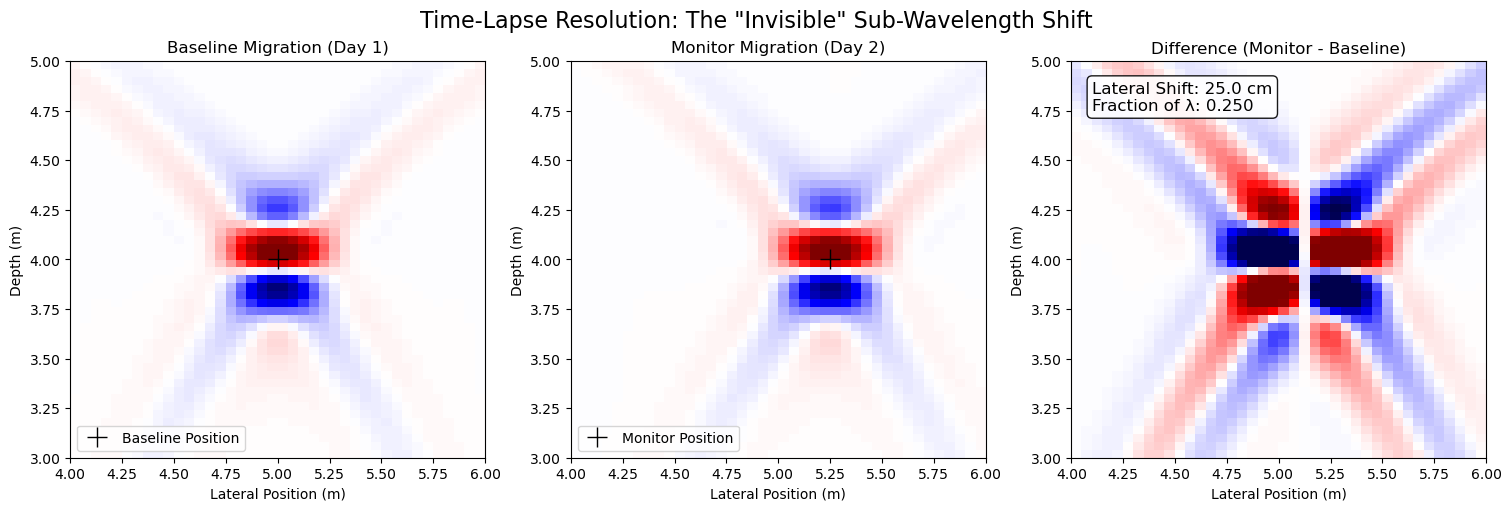

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
# Medium and Radar properties
v = 0.1                      # Velocity (m/ns)
f_c = 0.1                    # Center frequency (GHz)
wavelength = v / f_c         # Dominant Wavelength (m) -> 1.0 m

# Grid Definitions
nx, nz = 200, 200
x_start, x_end = 0, 10
z_start, z_end = 0, 8
x_pos = np.linspace(x_start, x_end, nx)
z_pos = np.linspace(z_start, z_end, nz)
dx = x_pos[1] - x_pos[0]
dz = z_pos[1] - z_pos[0]

# Time Definitions
t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)
dt = time_axis[1] - time_axis[0]

# Target Locations
x_base = 5.0
z_target = 4.0

# Precompute Gazdag migration variables 
v_mig = v / 2  
pad_t = nt
pad_x = nx // 2
nt_pad = nt + pad_t
nx_pad = nx + (2 * pad_x)

freqs = np.fft.fftfreq(nt_pad, d=dt)
kxs = np.fft.fftfreq(nx_pad, d=dx)
KX, F = np.meshgrid(kxs, freqs)

omega = 2 * np.pi * F
kx = 2 * np.pi * KX
kz_sq = (omega / v_mig)**2 - kx**2
kz = np.where(kz_sq >= 0, np.sqrt(np.maximum(kz_sq, 0)), 0)
kz = np.sign(omega) * kz 

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

# ==========================================
# 2. Pre-Calculate the Baseline (Day 1)
# ==========================================
print("Pre-computing Baseline Migration...")
b_scan_base = np.zeros((nt, nx))
for i, x in enumerate(x_pos):
    dist = np.sqrt((x - x_base)**2 + z_target**2)
    b_scan_base[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2

b_scan_padded = np.pad(b_scan_base, ((0, pad_t), (pad_x, pad_x)), mode='constant')
P_fk_base = np.fft.fft2(b_scan_padded)
migrated_base = np.zeros((nz, nx))

for iz, z in enumerate(z_pos):
    phase_shift = np.exp(1j * kz * z)
    P_shifted_fk = P_fk_base * phase_shift
    P_shifted_xt_padded = np.real(np.fft.ifft2(P_shifted_fk))
    migrated_base[iz, :] = P_shifted_xt_padded[0, pad_x:pad_x+nx]

vmax_base = np.max(np.abs(migrated_base)) * 0.8

# ==========================================
# 3. Animation Sweep Parameters
# ==========================================
num_frames = 50
# Move from 0 shift up to 0.1 wavelengths (10 cm)
lateral_shifts = np.linspace(0.0, 0.25 * wavelength, num_frames)

# ==========================================
# 4. Figure Setup
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
suptitle = fig.suptitle('Time-Lapse Resolution: The "Invisible" Sub-Wavelength Shift', fontsize=16)

# --- Panel 1: Baseline (Static) ---
ax1.set_title('Baseline Migration (Day 1)')
ax1.set_xlabel('Lateral Position (m)')
ax1.set_ylabel('Depth (m)')
ax1.set_xlim(4, 6)
ax1.set_ylim(3, 5)
ax1.imshow(migrated_base, aspect='auto', cmap='seismic', 
           extent=[x_start, x_end, z_end, z_start], vmin=-vmax_base, vmax=vmax_base)
ax1.plot(x_base, z_target, 'k+', markersize=15, label='Baseline Position')
ax1.legend(loc='lower left')

# --- Panel 2: Monitor (Moving) ---
ax2.set_title('Monitor Migration (Day 2)')
ax2.set_xlabel('Lateral Position (m)')
ax2.set_ylabel('Depth (m)')
ax2.set_xlim(4, 6)
ax2.set_ylim(3, 5)

im2 = ax2.imshow(migrated_base, aspect='auto', cmap='seismic', 
                 extent=[x_start, x_end, z_end, z_start], vmin=-vmax_base, vmax=vmax_base)
tgt_cross, = ax2.plot([], [], 'k+', markersize=15, label='Monitor Position')
ax2.legend(loc='lower left')

# --- Panel 3: Time-Lapse Difference ---
ax3.set_title('Difference (Monitor - Baseline)')
ax3.set_xlabel('Lateral Position (m)')
ax3.set_ylabel('Depth (m)')
ax3.set_xlim(4, 6)
ax3.set_ylim(3, 5)

# We use a tighter color scale for the difference to highlight the residual artifact
vmax_diff = vmax_base * 0.4
im3 = ax3.imshow(np.zeros((nz, nx)), aspect='auto', cmap='seismic', 
                 extent=[x_start, x_end, z_end, z_start], vmin=-vmax_diff, vmax=vmax_diff)

# Text box to show the exact quantitative shift
text_box = ax3.text(0.05, 0.95, '', transform=ax3.transAxes, fontsize=12,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# ==========================================
# 5. Animation Logic
# ==========================================
def update(frame):
    shift_m = lateral_shifts[frame]
    x_mon = x_base + shift_m
    shift_fraction = shift_m / wavelength
    
    print(f"Processing Frame {frame+1}/{num_frames} (Shift: {shift_m:.3f} m)")
    
    # 1. Update visual markers
    tgt_cross.set_data([x_mon], [z_target])
    text_box.set_text(f"Lateral Shift: {shift_m*100:.1f} cm\nFraction of \u03BB: {shift_fraction:.3f}")
    
    # 2. Generate new B-Scan for Monitor
    b_scan_mon = np.zeros((nt, nx))
    for i, x in enumerate(x_pos):
        dist = np.sqrt((x - x_mon)**2 + z_target**2)
        b_scan_mon[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
                       
    # 3. Perform Gazdag Phase-Shift Migration for Monitor
    b_scan_padded = np.pad(b_scan_mon, ((0, pad_t), (pad_x, pad_x)), mode='constant')
    P_fk_mon = np.fft.fft2(b_scan_padded)
    migrated_mon = np.zeros((nz, nx))
    
    for iz, z in enumerate(z_pos):
        phase_shift = np.exp(1j * kz * z)
        P_shifted_fk = P_fk_mon * phase_shift
        P_shifted_xt_padded = np.real(np.fft.ifft2(P_shifted_fk))
        migrated_mon[iz, :] = P_shifted_xt_padded[0, pad_x:pad_x+nx]
        
    # 4. Calculate the Difference (Monitor - Baseline)
    diff_image = migrated_mon - migrated_base
    
    # 5. Update images
    im2.set_data(migrated_mon)
    im3.set_data(diff_image)
    
    return tgt_cross, im2, im3, text_box

# Run animation
ani = FuncAnimation(fig, update, frames=num_frames, blit=False, interval=150)

print("Starting render...")
ani.save('Timelapse_Invisible_Shift.gif', writer='pillow', fps=10)

plt.show()

Exporting Row 1...
Row 1 Complete.


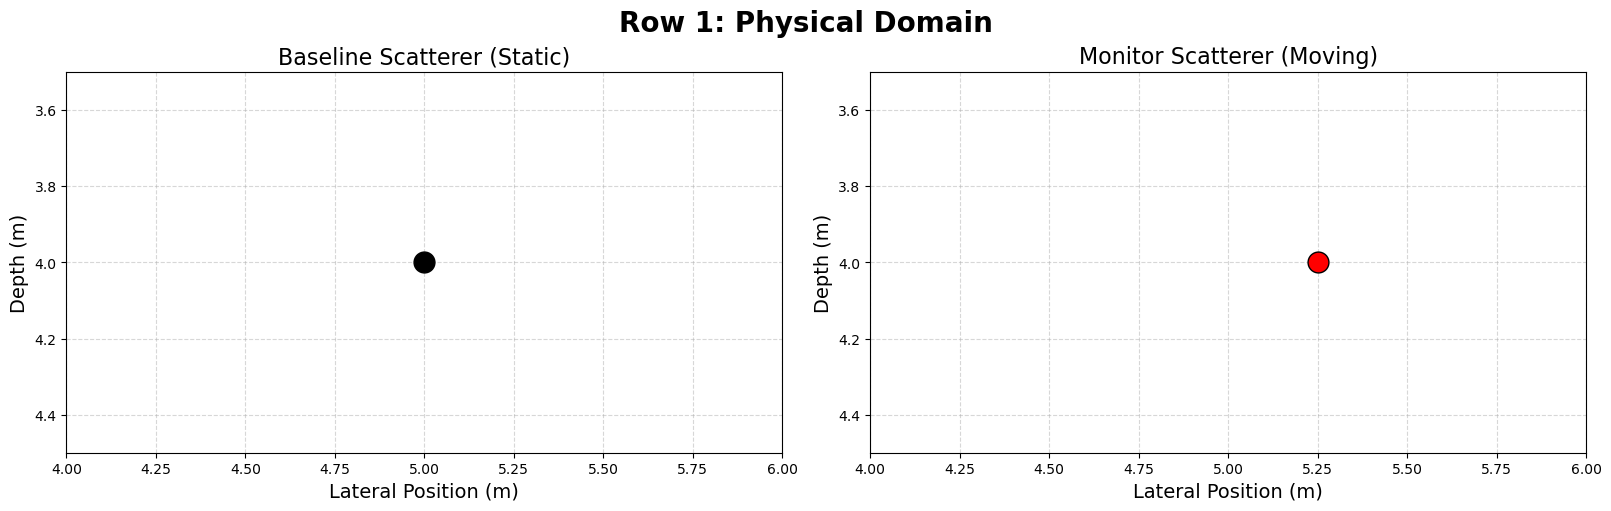

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

# ==========================================
# Parameters
# ==========================================
num_frames = 50
x_base = 5.0
z_target = 4.0
v = 0.1
f_c = 0.1
wavelength = v / f_c
lateral_shifts = np.linspace(0.0, 0.25 * wavelength, num_frames)

# ==========================================
# Figure Setup (High-Res 16:5 ratio for a wide row)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
fig.suptitle('Row 1: Physical Domain', fontsize=20, fontweight='bold')

for ax in [ax1, ax2]:
    ax.set_xlim(4, 6)
    ax.set_ylim(4.5, 3.5) # Inverted depth
    ax.set_xlabel('Lateral Position (m)', fontsize=14)
    ax.set_ylabel('Depth (m)', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)

ax1.set_title('Baseline Scatterer (Static)', fontsize=16)
base_dot, = ax1.plot(x_base, z_target, 'ko', markersize=15, markerfacecolor='black')

ax2.set_title('Monitor Scatterer (Moving)', fontsize=16)
mon_dot, = ax2.plot(x_base, z_target, 'ko', markersize=15, markerfacecolor='red')

# ==========================================
# Animation Logic
# ==========================================
def update(frame):
    current_x = x_base + lateral_shifts[frame]
    mon_dot.set_data([current_x], [z_target])
    return mon_dot,

ani = FuncAnimation(fig, update, frames=num_frames, blit=True, interval=100, repeat=False)

print("Exporting Row 1...")
# Note: Requires FFmpeg installed. Change to PillowWriter if you prefer GIFs.
writer = FFMpegWriter(fps=10, bitrate=8000)
ani.save('Row1_Physical.mp4', writer=writer, dpi=300)
print("Row 1 Complete.")

Row 2: Frame 1/150
Row 2: Frame 1/150
Exporting Row 2...
Row 2: Frame 1/150
Row 2: Frame 1/150
Row 2: Frame 2/150
Row 2: Frame 3/150
Row 2: Frame 4/150
Row 2: Frame 5/150
Row 2: Frame 6/150
Row 2: Frame 7/150
Row 2: Frame 8/150
Row 2: Frame 9/150
Row 2: Frame 10/150
Row 2: Frame 11/150
Row 2: Frame 12/150
Row 2: Frame 13/150
Row 2: Frame 14/150
Row 2: Frame 15/150
Row 2: Frame 16/150
Row 2: Frame 17/150
Row 2: Frame 18/150
Row 2: Frame 19/150
Row 2: Frame 20/150
Row 2: Frame 21/150
Row 2: Frame 22/150
Row 2: Frame 23/150
Row 2: Frame 24/150
Row 2: Frame 25/150
Row 2: Frame 26/150
Row 2: Frame 27/150
Row 2: Frame 28/150
Row 2: Frame 29/150
Row 2: Frame 30/150
Row 2: Frame 31/150
Row 2: Frame 32/150
Row 2: Frame 33/150
Row 2: Frame 34/150
Row 2: Frame 35/150
Row 2: Frame 36/150
Row 2: Frame 37/150
Row 2: Frame 38/150
Row 2: Frame 39/150
Row 2: Frame 40/150
Row 2: Frame 41/150
Row 2: Frame 42/150
Row 2: Frame 43/150
Row 2: Frame 44/150
Row 2: Frame 45/150
Row 2: Frame 46/150
Row 2: Frame 

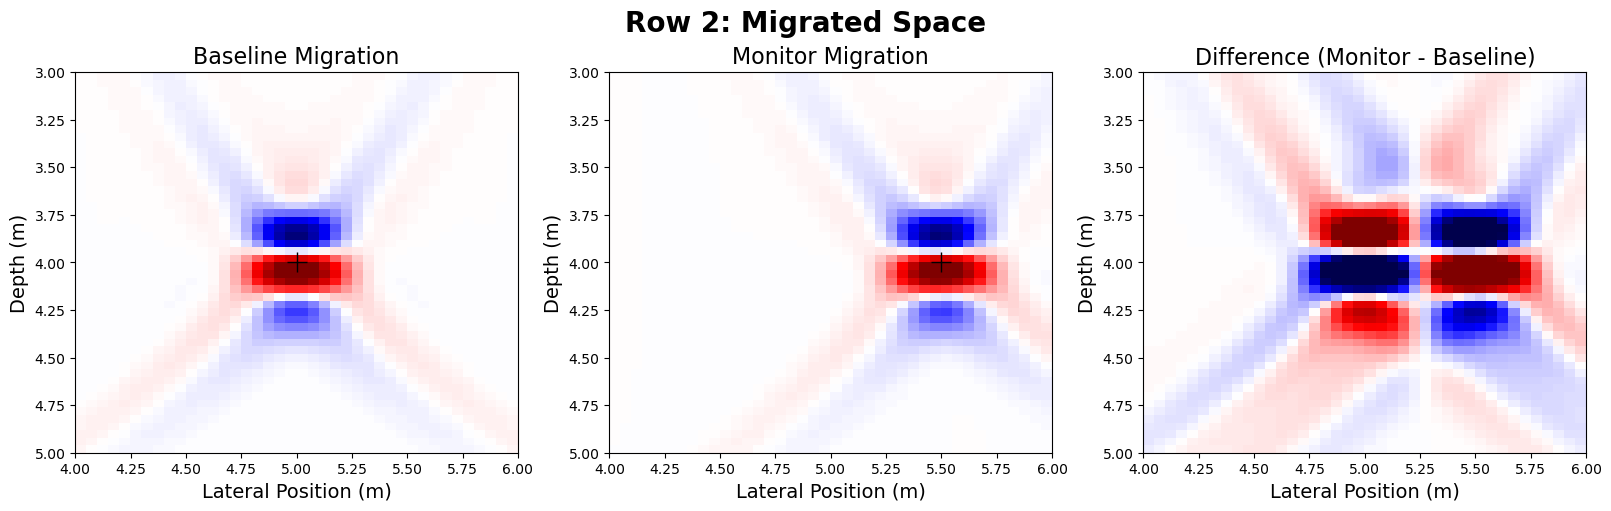

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

# ==========================================
# Parameters & Precomputation
# ==========================================
num_frames = 150
v, f_c = 0.1, 0.1
wavelength = v / f_c
lateral_shifts = np.linspace(0.0, 0.5 * wavelength, num_frames)

nx, nz = 200, 200
x_pos, z_pos = np.linspace(0, 10, nx), np.linspace(0, 8, nz)
dx, dz = x_pos[1] - x_pos[0], z_pos[1] - z_pos[0]
time_axis = np.linspace(0, 160, 400)
dt = time_axis[1] - time_axis[0]
nt = len(time_axis)

x_base, z_target = 5.0, 4.0

v_mig = v / 2
pad_t, pad_x = nt, nx // 2
nt_pad, nx_pad = nt + pad_t, nx + 2 * pad_x
KX, F = np.meshgrid(np.fft.fftfreq(nx_pad, d=dx), np.fft.fftfreq(nt_pad, d=dt))
omega, kx = 2 * np.pi * F, 2 * np.pi * KX
kz_sq = (omega / v_mig)**2 - kx**2
kz = np.where(kz_sq >= 0, np.sqrt(np.maximum(kz_sq, 0)), 0) * np.sign(omega)

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def migrate_target(x_tgt):
    b_scan = np.zeros((nt, nx))
    for i, x in enumerate(x_pos):
        dist = np.sqrt((x - x_tgt)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
    
    b_padded = np.pad(b_scan, ((0, pad_t), (pad_x, pad_x)), mode='constant')
    P_fk = np.fft.fft2(b_padded)
    migrated = np.zeros((nz, nx))
    for iz, z in enumerate(z_pos):
        migrated[iz, :] = np.real(np.fft.ifft2(P_fk * np.exp(1j * kz * z)))[0, pad_x:pad_x+nx]
    return migrated

mig_base = migrate_target(x_base)
vmax_m = np.max(np.abs(mig_base)) * 0.8

# ==========================================
# Figure Setup
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle('Row 2: Migrated Space', fontsize=20, fontweight='bold')

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(4, 6)
    ax.set_ylim(5, 3)
    ax.set_xlabel('Lateral Position (m)', fontsize=14)
    ax.set_ylabel('Depth (m)', fontsize=14)

ax1.set_title('Baseline Migration', fontsize=16)
ax1.imshow(mig_base, aspect='auto', cmap='seismic', extent=[0, 10, 8, 0], vmin=-vmax_m, vmax=vmax_m)
ax1.plot(x_base, z_target, 'k+', markersize=15)

ax2.set_title('Monitor Migration', fontsize=16)
im2 = ax2.imshow(mig_base, aspect='auto', cmap='seismic', extent=[0, 10, 8, 0], vmin=-vmax_m, vmax=vmax_m)
tgt_cross, = ax2.plot([], [], 'k+', markersize=15)

ax3.set_title('Difference (Monitor - Baseline)', fontsize=16)
vmax_diff = vmax_m * 0.5
im3 = ax3.imshow(np.zeros_like(mig_base), aspect='auto', cmap='seismic', extent=[0, 10, 8, 0], vmin=-vmax_diff, vmax=vmax_diff)

# ==========================================
# Animation Logic
# ==========================================
def update(frame):
    print(f"Row 2: Frame {frame+1}/{num_frames}")
    current_x = x_base + lateral_shifts[frame]
    mig_mon = migrate_target(current_x)
    
    tgt_cross.set_data([current_x], [z_target])
    im2.set_data(mig_mon)
    im3.set_data(mig_mon - mig_base)
    return tgt_cross, im2, im3

ani = FuncAnimation(fig, update, frames=num_frames, blit=True, interval=100, repeat=False)

print("Exporting Row 2...")
writer = FFMpegWriter(fps=10, bitrate=8000)
ani.save('Row2_Migrated.mp4', writer=writer, dpi=300)
print("Row 2 Complete.")

Row 3: Frame 1/150
Row 3: Frame 1/150
Exporting Row 3...
Row 3: Frame 1/150
Row 3: Frame 1/150
Row 3: Frame 2/150
Row 3: Frame 3/150
Row 3: Frame 4/150
Row 3: Frame 5/150
Row 3: Frame 6/150
Row 3: Frame 7/150
Row 3: Frame 8/150
Row 3: Frame 9/150
Row 3: Frame 10/150
Row 3: Frame 11/150
Row 3: Frame 12/150
Row 3: Frame 13/150
Row 3: Frame 14/150
Row 3: Frame 15/150
Row 3: Frame 16/150
Row 3: Frame 17/150
Row 3: Frame 18/150
Row 3: Frame 19/150
Row 3: Frame 20/150
Row 3: Frame 21/150
Row 3: Frame 22/150
Row 3: Frame 23/150
Row 3: Frame 24/150
Row 3: Frame 25/150
Row 3: Frame 26/150
Row 3: Frame 27/150
Row 3: Frame 28/150
Row 3: Frame 29/150
Row 3: Frame 30/150
Row 3: Frame 31/150
Row 3: Frame 32/150
Row 3: Frame 33/150
Row 3: Frame 34/150
Row 3: Frame 35/150
Row 3: Frame 36/150
Row 3: Frame 37/150
Row 3: Frame 38/150
Row 3: Frame 39/150
Row 3: Frame 40/150
Row 3: Frame 41/150
Row 3: Frame 42/150
Row 3: Frame 43/150
Row 3: Frame 44/150
Row 3: Frame 45/150
Row 3: Frame 46/150
Row 3: Frame 

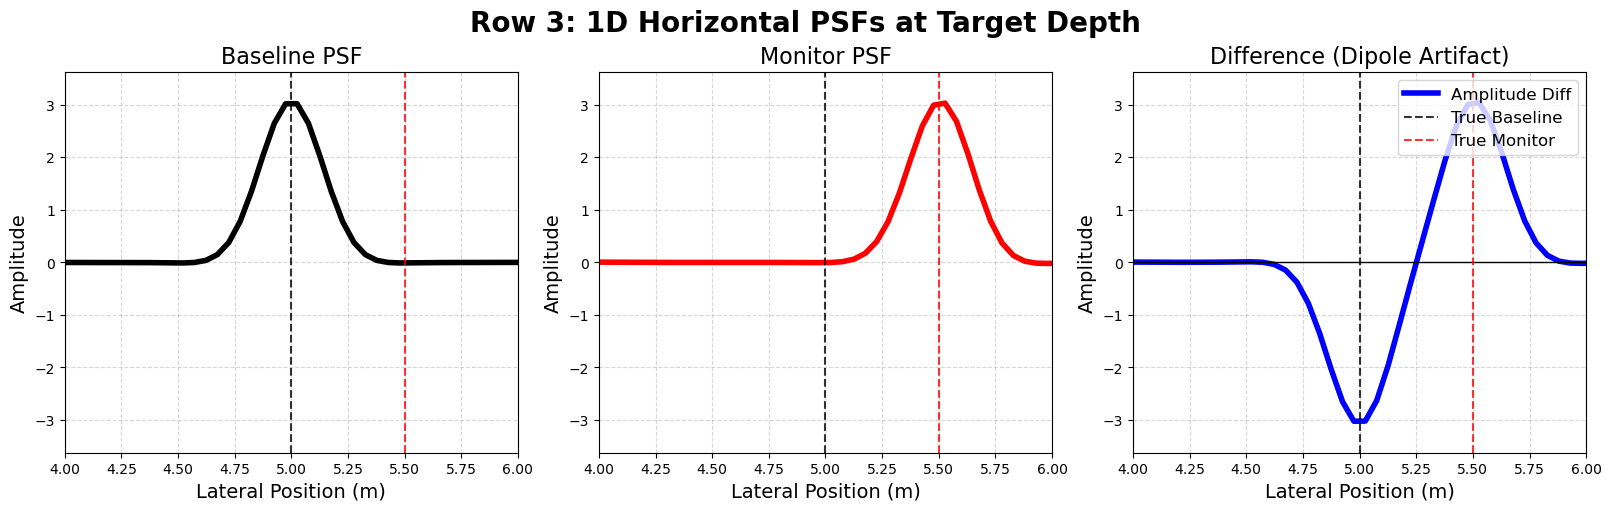

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

# ==========================================
# Parameters & Precomputation 
# ==========================================
num_frames = 150
v, f_c = 0.1, 0.1
wavelength = v / f_c
lateral_shifts = np.linspace(0.0, 0.5 * wavelength, num_frames)

nx, nz = 200, 200
x_pos, z_pos = np.linspace(0, 10, nx), np.linspace(0, 8, nz)
dx, dz = x_pos[1] - x_pos[0], z_pos[1] - z_pos[0]
time_axis = np.linspace(0, 160, 400)
dt = time_axis[1] - time_axis[0]
nt = len(time_axis)

x_base, z_target = 5.0, 4.0
iz_target = np.argmin(np.abs(z_pos - z_target)) 

v_mig = v / 2
pad_t, pad_x = nt, nx // 2
nt_pad, nx_pad = nt + pad_t, nx + 2 * pad_x
KX, F = np.meshgrid(np.fft.fftfreq(nx_pad, d=dx), np.fft.fftfreq(nt_pad, d=dt))
omega, kx = 2 * np.pi * F, 2 * np.pi * KX
kz_sq = (omega / v_mig)**2 - kx**2
kz = np.where(kz_sq >= 0, np.sqrt(np.maximum(kz_sq, 0)), 0) * np.sign(omega)

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def migrate_slice(x_tgt):
    b_scan = np.zeros((nt, nx))
    for i, x in enumerate(x_pos):
        dist = np.sqrt((x - x_tgt)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
    
    b_padded = np.pad(b_scan, ((0, pad_t), (pad_x, pad_x)), mode='constant')
    P_fk = np.fft.fft2(b_padded)
    # Extract only the exact depth slice needed
    return np.real(np.fft.ifft2(P_fk * np.exp(1j * kz * z_target)))[0, pad_x:pad_x+nx]

slice_base = migrate_slice(x_base)
y_max = np.max(np.abs(slice_base)) * 1.2

# ==========================================
# Figure Setup
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle('Row 3: 1D Horizontal PSFs at Target Depth', fontsize=20, fontweight='bold')

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(4, 6)
    ax.set_xlabel('Lateral Position (m)', fontsize=14)
    ax.set_ylabel('Amplitude', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)

ax1.set_title('Baseline PSF', fontsize=16)
ax1.set_ylim(-y_max, y_max)
ax1.plot(x_pos, slice_base, 'k-', linewidth=4)

ax2.set_title('Monitor PSF', fontsize=16)
ax2.set_ylim(-y_max, y_max)
line2, = ax2.plot(x_pos, slice_base, 'r-', linewidth=4)

ax3.set_title('Difference (Dipole Artifact)', fontsize=16)
ax3.set_ylim(-y_max * 1, y_max * 1) 
line3, = ax3.plot(x_pos, np.zeros_like(slice_base), 'b-', linewidth=4, label='Amplitude Diff')
ax3.axhline(0, color='black', linewidth=1, linestyle='-')

# --- Add True Location Dashed Lines to ALL Panels ---
base_vlines = []
mon_vlines = []

for ax in [ax1, ax2, ax3]:
    # Black dashed line for true baseline
    b_line = ax.axvline(x_base, color='black', linestyle='--', linewidth=1.5, alpha=0.8, label='True Baseline')
    # Red dashed line for true monitor
    m_line = ax.axvline(x_base, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='True Monitor')
    
    base_vlines.append(b_line)
    mon_vlines.append(m_line)

# Only add the legend to the third panel to avoid clutter
ax3.legend(loc='upper right', fontsize=12)

# ==========================================
# Animation Logic
# ==========================================
def update(frame):
    print(f"Row 3: Frame {frame+1}/{num_frames}")
    current_x = x_base + lateral_shifts[frame]
    slice_mon = migrate_slice(current_x)
    
    # Update PSF lines
    line2.set_ydata(slice_mon)
    line3.set_ydata(slice_mon - slice_base)
    
    # Update monitor true location vertical lines in all panels
    for m_line in mon_vlines:
        m_line.set_xdata([current_x, current_x])
    
    # Return all updated artists for blitting
    return  line3, mon_vlines[1], mon_vlines[2]

ani = FuncAnimation(fig, update, frames=num_frames, blit=True, interval=100, repeat=False)

print("Exporting Row 3...")
# Note: Requires FFmpeg installed. Change to PillowWriter if you prefer GIFs.
writer = FFMpegWriter(fps=10, bitrate=8000)
# Uncomment to save
ani.save('Row3_PSF_Slices_All_Vlines.mp4', writer=writer, dpi=300)
print("Row 3 Complete.")
plt.show()

Row 3: Frame 1/150
Row 3: Frame 1/150
Exporting Row 3...
Row 3: Frame 1/150
Row 3: Frame 1/150
Row 3: Frame 2/150
Row 3: Frame 3/150
Row 3: Frame 4/150
Row 3: Frame 5/150
Row 3: Frame 6/150
Row 3: Frame 7/150
Row 3: Frame 8/150
Row 3: Frame 9/150
Row 3: Frame 10/150
Row 3: Frame 11/150
Row 3: Frame 12/150
Row 3: Frame 13/150
Row 3: Frame 14/150
Row 3: Frame 15/150
Row 3: Frame 16/150
Row 3: Frame 17/150
Row 3: Frame 18/150
Row 3: Frame 19/150
Row 3: Frame 20/150
Row 3: Frame 21/150
Row 3: Frame 22/150
Row 3: Frame 23/150
Row 3: Frame 24/150
Row 3: Frame 25/150
Row 3: Frame 26/150
Row 3: Frame 27/150
Row 3: Frame 28/150
Row 3: Frame 29/150
Row 3: Frame 30/150
Row 3: Frame 31/150
Row 3: Frame 32/150
Row 3: Frame 33/150
Row 3: Frame 34/150
Row 3: Frame 35/150
Row 3: Frame 36/150
Row 3: Frame 37/150
Row 3: Frame 38/150
Row 3: Frame 39/150
Row 3: Frame 40/150
Row 3: Frame 41/150
Row 3: Frame 42/150
Row 3: Frame 43/150
Row 3: Frame 44/150
Row 3: Frame 45/150
Row 3: Frame 46/150
Row 3: Frame 

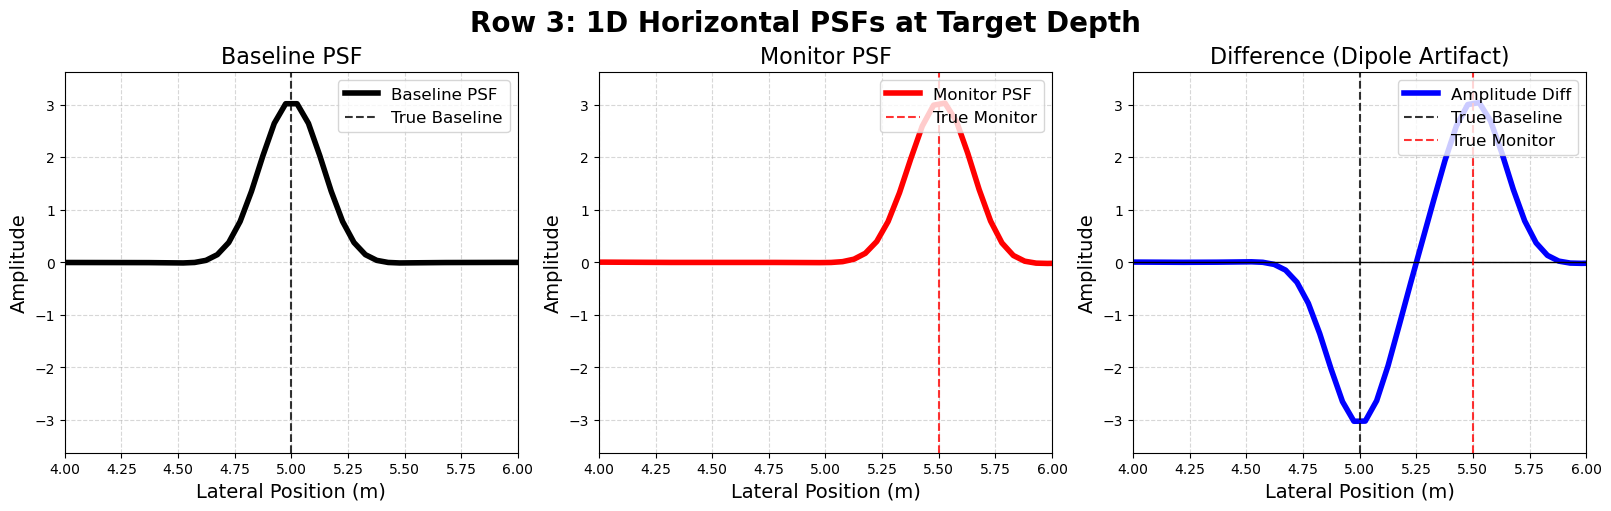

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

# ==========================================
# Parameters & Precomputation 
# ==========================================
num_frames = 150
v, f_c = 0.1, 0.1
wavelength = v / f_c
lateral_shifts = np.linspace(0.0, 0.5 * wavelength, num_frames)

nx, nz = 200, 200
x_pos, z_pos = np.linspace(0, 10, nx), np.linspace(0, 8, nz)
dx, dz = x_pos[1] - x_pos[0], z_pos[1] - z_pos[0]
time_axis = np.linspace(0, 160, 400)
dt = time_axis[1] - time_axis[0]
nt = len(time_axis)

x_base, z_target = 5.0, 4.0
iz_target = np.argmin(np.abs(z_pos - z_target)) 

v_mig = v / 2
pad_t, pad_x = nt, nx // 2
nt_pad, nx_pad = nt + pad_t, nx + 2 * pad_x
KX, F = np.meshgrid(np.fft.fftfreq(nx_pad, d=dx), np.fft.fftfreq(nt_pad, d=dt))
omega, kx = 2 * np.pi * F, 2 * np.pi * KX
kz_sq = (omega / v_mig)**2 - kx**2
kz = np.where(kz_sq >= 0, np.sqrt(np.maximum(kz_sq, 0)), 0) * np.sign(omega)

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def migrate_slice(x_tgt):
    b_scan = np.zeros((nt, nx))
    for i, x in enumerate(x_pos):
        dist = np.sqrt((x - x_tgt)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
    
    b_padded = np.pad(b_scan, ((0, pad_t), (pad_x, pad_x)), mode='constant')
    P_fk = np.fft.fft2(b_padded)
    # Extract only the exact depth slice needed
    return np.real(np.fft.ifft2(P_fk * np.exp(1j * kz * z_target)))[0, pad_x:pad_x+nx]

slice_base = migrate_slice(x_base)
y_max = np.max(np.abs(slice_base)) * 1.2

# ==========================================
# Figure Setup
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle('Row 3: 1D Horizontal PSFs at Target Depth', fontsize=20, fontweight='bold')

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(4, 6)
    ax.set_xlabel('Lateral Position (m)', fontsize=14)
    ax.set_ylabel('Amplitude', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)

# Panel 1: Baseline PSF + Baseline vline only
ax1.set_title('Baseline PSF', fontsize=16)
ax1.set_ylim(-y_max, y_max)
ax1.plot(x_pos, slice_base, 'k-', linewidth=4, label='Baseline PSF')
base_vline_1 = ax1.axvline(x_base, color='black', linestyle='--', linewidth=1.5, alpha=0.8, label='True Baseline')
ax1.legend(loc='upper right', fontsize=12)

# Panel 2: Monitor PSF + Monitor vline only
ax2.set_title('Monitor PSF', fontsize=16)
ax2.set_ylim(-y_max, y_max)
line2, = ax2.plot(x_pos, slice_base, 'r-', linewidth=4, label='Monitor PSF')
mon_vline_2 = ax2.axvline(x_base, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='True Monitor')
ax2.legend(loc='upper right', fontsize=12)

# Panel 3: Difference Artifact + Both vlines
ax3.set_title('Difference (Dipole Artifact)', fontsize=16)
ax3.set_ylim(-y_max * 1, y_max * 1) 
line3, = ax3.plot(x_pos, np.zeros_like(slice_base), 'b-', linewidth=4, label='Amplitude Diff')
ax3.axhline(0, color='black', linewidth=1, linestyle='-')

base_vline_3 = ax3.axvline(x_base, color='black', linestyle='--', linewidth=1.5, alpha=0.8, label='True Baseline')
mon_vline_3 = ax3.axvline(x_base, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='True Monitor')
ax3.legend(loc='upper right', fontsize=12)

# ==========================================
# Animation Logic
# ==========================================
def update(frame):
    print(f"Row 3: Frame {frame+1}/{num_frames}")
    current_x = x_base + lateral_shifts[frame]
    slice_mon = migrate_slice(current_x)
    
    # Update PSF lines
    line2.set_ydata(slice_mon)
    line3.set_ydata(slice_mon - slice_base)
    
    # Update monitor true location vertical lines in Panel 2 and Panel 3
    mon_vline_2.set_xdata([current_x, current_x])
    mon_vline_3.set_xdata([current_x, current_x])
    
    return line2, line3, mon_vline_2, mon_vline_3

ani = FuncAnimation(fig, update, frames=num_frames, blit=True, interval=100, repeat=False)

print("Exporting Row 3...")
writer = FFMpegWriter(fps=10, bitrate=8000)
# Uncomment to save
ani.save('Row3_PSF_Slices_Isolated_Vlines.mp4', writer=writer, dpi=300)
print("Row 3 Complete.")
plt.show()

# Time-Lapse Cross-Spectrum

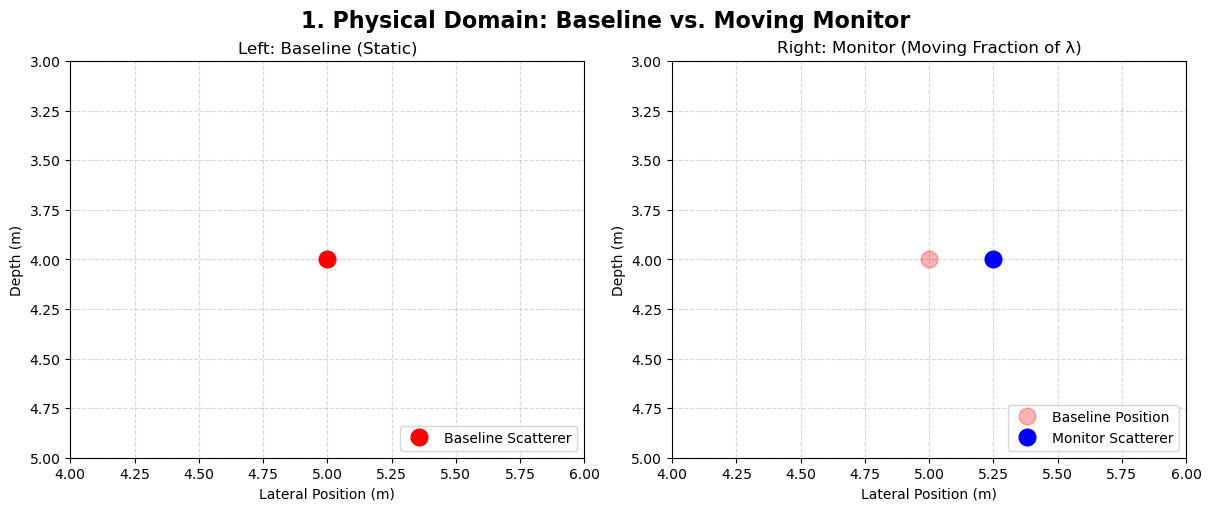

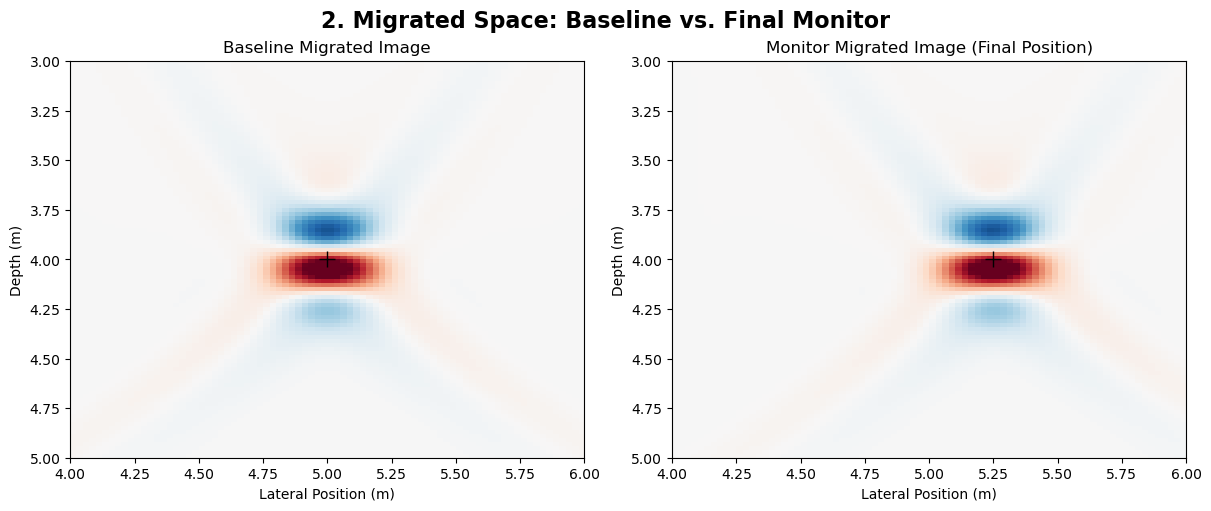

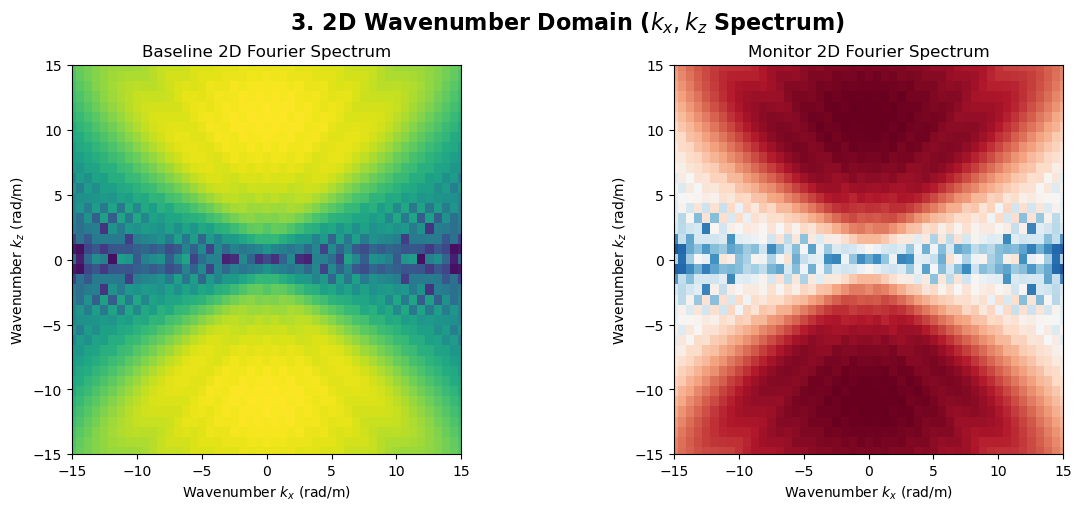

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
v = 0.1                      # Velocity (m/ns)
f_c = 0.1                    # Center frequency (GHz)
wavelength = v / f_c         # Dominant Wavelength (m) -> 1.0 m

nx, nz = 400, 400
x_start, x_end = 0, 10
z_start, z_end = 0, 8
x_pos = np.linspace(x_start, x_end, nx)
z_pos = np.linspace(z_start, z_end, nz)
dx = x_pos[1] - x_pos[0]
dz = z_pos[1] - z_pos[0]

t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)
dt = time_axis[1] - time_axis[0]

x_base = 5.0
z_target = 4.0
final_shift = 0.25 * wavelength # Final shift of 0.25 lambda

# Gazdag Migration Precomputation
v_mig = v / 2  
pad_t = nt
pad_x = nx // 2
nt_pad = nt + pad_t
nx_pad = nx + (2 * pad_x)

freqs = np.fft.fftfreq(nt_pad, d=dt)
kxs = np.fft.fftfreq(nx_pad, d=dx)
KX, F = np.meshgrid(kxs, freqs)
omega = 2 * np.pi * F
kx = 2 * np.pi * KX
kz_sq = (omega / v_mig)**2 - kx**2
kz = np.where(kz_sq >= 0, np.sqrt(np.maximum(kz_sq, 0)), 0)
kz = np.sign(omega) * kz 

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def migrate_bscan(x_tgt):
    b_scan = np.zeros((nt, nx))
    for i, x in enumerate(x_pos):
        dist = np.sqrt((x - x_tgt)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
    
    b_padded = np.pad(b_scan, ((0, pad_t), (pad_x, pad_x)), mode='constant')
    P_fk = np.fft.fft2(b_padded)
    migrated = np.zeros((nz, nx))
    for iz, z in enumerate(z_pos):
        migrated[iz, :] = np.real(np.fft.ifft2(P_fk * np.exp(1j * kz * z)))[0, pad_x:pad_x+nx]
    return migrated

# Precompute baseline and final monitor images
mig_base = migrate_bscan(x_base)
mig_mon = migrate_bscan(x_base + final_shift)

vmax_mig = np.max(np.abs(mig_base)) * 0.8

# ==========================================
# OUTPUT 1: Animation (Physical Domain)
# ==========================================
num_frames = 40
shifts = np.linspace(0.0, final_shift, num_frames)

fig1, (ax1_a, ax1_b) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig1.suptitle('1. Physical Domain: Baseline vs. Moving Monitor', fontsize=16, fontweight='bold')

for ax in [ax1_a, ax1_b]:
    ax.set_xlim(4, 6)
    ax.set_ylim(5, 3) # Inverted depth
    ax.set_xlabel('Lateral Position (m)')
    ax.set_ylabel('Depth (m)')
    ax.grid(True, linestyle='--', alpha=0.5)

ax1_a.set_title('Left: Baseline (Static)')
ax1_a.plot(x_base, z_target, 'ro', markersize=12, label='Baseline Scatterer')
ax1_a.legend(loc='lower right')

ax1_b.set_title('Right: Monitor (Moving Fraction of \u03BB)')
ax1_b.plot(x_base, z_target, 'ro', markersize=12, alpha=0.3, label='Baseline Position')
mon_dot, = ax1_b.plot([], [], 'bo', markersize=12, label='Monitor Scatterer')
ax1_b.legend(loc='lower right')

def update(frame):
    current_x = x_base + shifts[frame]
    mon_dot.set_data([current_x], [z_target])
    return mon_dot,

ani = FuncAnimation(fig1, update, frames=num_frames, blit=True, interval=100, repeat=False)
ani.save('Physical_Animation.mp4', writer=FFMpegWriter(fps=10, bitrate=5000), dpi=300)

# ==========================================
# OUTPUT 2: Static Migrated Images
# ==========================================
fig2, (ax2_a, ax2_b) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig2.suptitle('2. Migrated Space: Baseline vs. Final Monitor', fontsize=16, fontweight='bold')

ax2_a.set_title('Baseline Migrated Image')
ax2_a.set_xlabel('Lateral Position (m)')
ax2_a.set_ylabel('Depth (m)')
ax2_a.set_xlim(4, 6)
ax2_a.set_ylim(5, 3)
ax2_a.imshow(mig_base, aspect='auto', cmap='RdBu_r', extent=[x_start, x_end, z_end, z_start], vmin=-vmax_mig, vmax=vmax_mig)
ax2_a.plot(x_base, z_target, 'k+', markersize=12)

ax2_b.set_title('Monitor Migrated Image (Final Position)')
ax2_b.set_xlabel('Lateral Position (m)')
ax2_b.set_ylabel('Depth (m)')
ax2_b.set_xlim(4, 6)
ax2_b.set_ylim(5, 3)
ax2_b.imshow(mig_mon, aspect='auto', cmap='RdBu_r', extent=[x_start, x_end, z_end, z_start], vmin=-vmax_mig, vmax=vmax_mig)
ax2_b.plot(x_base + final_shift, z_target, 'k+', markersize=12)
# cbar_a = fig2.colorbar(im1, ax=ax2_a, orientation='vertical', fraction=0.046, pad=0.04)
# cbar_a.set_label('Amplitude', rotation=270, labelpad=15)
# cbar_b = fig2.colorbar(im2, ax=ax2_b, orientation='vertical', fraction=0.046, pad=0.04)
# cbar_b.set_label('Amplitude', rotation=270, labelpad=15)

# ==========================================
# OUTPUT 3: Static 2D Fourier Transform (Wavenumber Domain)
# ==========================================
# Compute 2D FFT of the migrated images and shift zero-frequency to center
F_base = np.fft.fftshift(np.fft.fft2(mig_base))
F_mon = np.fft.fftshift(np.fft.fft2(mig_mon))

pow_base = np.log(np.abs(F_base) + 1)
pow_mon = np.log(np.abs(F_mon) + 1)

kx_axis = np.fft.fftshift(np.fft.fftfreq(nx, d=dx)) * 2 * np.pi
kz_axis = np.fft.fftshift(np.fft.fftfreq(nz, d=dz)) * 2 * np.pi
extent_k = [kx_axis.min(), kx_axis.max(), kz_axis.min(), kz_axis.max()]

fig3, (ax3_a, ax3_b) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig3.suptitle('3. 2D Wavenumber Domain ($k_x, k_z$ Spectrum)', fontsize=16, fontweight='bold')

zoom_k = 15

ax3_a.set_title('Baseline 2D Fourier Spectrum')
ax3_a.set_xlabel('Wavenumber $k_x$ (rad/m)')
ax3_a.set_ylabel('Wavenumber $k_z$ (rad/m)')
ax3_a.set_xlim(-zoom_k, zoom_k)
ax3_a.set_ylim(-zoom_k, zoom_k)
im_f1 = ax3_a.imshow(pow_base, extent=extent_k, origin='lower', cmap='RdBu_r')

ax3_b.set_title('Monitor 2D Fourier Spectrum')
ax3_b.set_xlabel('Wavenumber $k_x$ (rad/m)')
ax3_b.set_ylabel('Wavenumber $k_z$ (rad/m)')
ax3_b.set_xlim(-zoom_k, zoom_k)
ax3_b.set_ylim(-zoom_k, zoom_k)
im_f2 = ax3_b.imshow(pow_mon, extent=extent_k, origin='lower', cmap='RdBu_r')
# cbar1 = fig3.colorbar(im_f1, ax=ax3_a, orientation='vertical', fraction=0.046, pad=0.04)
# cbar1.set_label('log Power', rotation=270, labelpad=15)
# cbar2 = fig3.colorbar(im_f2, ax=ax3_b, orientation='vertical', fraction=0.046, pad=0.04)
# cbar2.set_label('log Power', rotation=270, labelpad=15)

plt.show()

<>:116: SyntaxWarning: invalid escape sequence '\p'
<>:116: SyntaxWarning: invalid escape sequence '\p'
<>:116: SyntaxWarning: invalid escape sequence '\p'
<>:116: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8900\2097011539.py:116: SyntaxWarning: invalid escape sequence '\p'
  cbar2.set_ticklabels(['$-\pi$', '0', '$\pi$'])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8900\2097011539.py:116: SyntaxWarning: invalid escape sequence '\p'
  cbar2.set_ticklabels(['$-\pi$', '0', '$\pi$'])


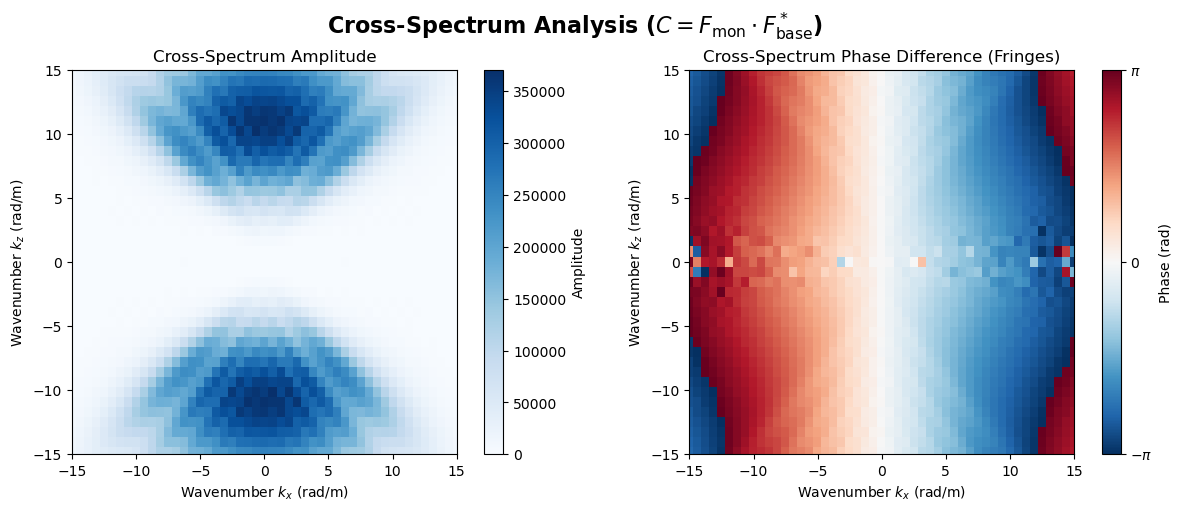

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
v = 0.1                      # Velocity (m/ns)
f_c = 0.1                    # Center frequency (GHz)
wavelength = v / f_c         # Dominant Wavelength (m) -> 1.0 m

nx, nz = 400, 400
x_start, x_end = 0, 10
z_start, z_end = 0, 8
x_pos = np.linspace(x_start, x_end, nx)
z_pos = np.linspace(z_start, z_end, nz)
dx = x_pos[1] - x_pos[0]
dz = z_pos[1] - z_pos[0]

t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)
dt = time_axis[1] - time_axis[0]

x_base = 5.0
z_target = 4.0
final_shift = 0.25 * wavelength # Final shift of 0.25 lambda

# Gazdag Migration Precomputation
v_mig = v / 2  
pad_t = nt
pad_x = nx // 2
nt_pad = nt + pad_t
nx_pad = nx + (2 * pad_x)

freqs = np.fft.fftfreq(nt_pad, d=dt)
kxs = np.fft.fftfreq(nx_pad, d=dx)
KX, F = np.meshgrid(kxs, freqs)
omega = 2 * np.pi * F
kx = 2 * np.pi * KX
kz_sq = (omega / v_mig)**2 - kx**2
kz = np.where(kz_sq >= 0, np.sqrt(np.maximum(kz_sq, 0)), 0)
kz = np.sign(omega) * kz 

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def migrate_bscan(x_tgt):
    b_scan = np.zeros((nt, nx))
    for i, x in enumerate(x_pos):
        dist = np.sqrt((x - x_tgt)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
    
    b_padded = np.pad(b_scan, ((0, pad_t), (pad_x, pad_x)), mode='constant')
    P_fk = np.fft.fft2(b_padded)
    migrated = np.zeros((nz, nx))
    for iz, z in enumerate(z_pos):
        migrated[iz, :] = np.real(np.fft.ifft2(P_fk * np.exp(1j * kz * z)))[0, pad_x:pad_x+nx]
    return migrated

# Precompute baseline and final monitor migrated images
mig_base = migrate_bscan(x_base)
mig_mon = migrate_bscan(x_base + final_shift)

# ==========================================
# 2. 2D Fourier Transform & Cross-Spectrum
# ==========================================
# Compute 2D FFT (without fftshift first to keep proper mathematical pairing for multiplication)
F_base = np.fft.fft2(mig_base)
F_mon = np.fft.fft2(mig_mon)

# Cross-Spectrum: Monitor * Baseline_Conjugate
cross_spectrum = F_mon * np.conj(F_base)

# Extract Amplitude and Phase from the cross-spectrum[cite: 1]
cross_amplitude = np.abs(cross_spectrum)
cross_phase = np.angle(cross_spectrum)

# Apply fftshift for centered wavenumber visualization
cross_amplitude_shifted = np.fft.fftshift(cross_amplitude)
cross_phase_shifted = np.fft.fftshift(cross_phase)

# Wavenumber axes (rad/m)
kx_axis = np.fft.fftshift(np.fft.fftfreq(nx, d=dx)) * 2 * np.pi
kz_axis = np.fft.fftshift(np.fft.fftfreq(nz, d=dz)) * 2 * np.pi
extent_k = [kx_axis.min(), kx_axis.max(), kz_axis.min(), kz_axis.max()]

# ==========================================
# 3. Figure Setup (Cross-Spectrum Amplitude & Phase)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle('Cross-Spectrum Analysis ($C = F_{\\text{mon}} \\cdot F_{\\text{base}}^*$)', fontsize=16, fontweight='bold')

zoom_k = 15

# --- Panel 1: Cross-Spectrum Amplitude ---
ax1.set_title('Cross-Spectrum Amplitude')
ax1.set_xlabel('Wavenumber $k_x$ (rad/m)')
ax1.set_ylabel('Wavenumber $k_z$ (rad/m)')
ax1.set_xlim(-zoom_k, zoom_k)
ax1.set_ylim(-zoom_k, zoom_k)
im1 = ax1.imshow(cross_amplitude_shifted, extent=extent_k, origin='lower', cmap='Blues')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label='Amplitude')

# --- Panel 2: Cross-Spectrum Phase Difference ---
ax2.set_title('Cross-Spectrum Phase Difference (Fringes)')
ax2.set_xlabel('Wavenumber $k_x$ (rad/m)')
ax2.set_ylabel('Wavenumber $k_z$ (rad/m)')
ax2.set_xlim(-zoom_k, zoom_k)
ax2.set_ylim(-zoom_k, zoom_k)
# Using 'twilight' colormap which is cyclic from -pi to pi
im2 = ax2.imshow(cross_phase_shifted, extent=extent_k, origin='lower', cmap='RdBu_r', vmin=-np.pi, vmax=np.pi)
# fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label='Phase (rad)', ticks=[-np.pi, 0, np.pi])
# ax2.set_yticklabels([])
# ax2.set_xticklabels([])
cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label='Phase (rad)')
cbar2.set_ticks([-np.pi, 0, np.pi])
cbar2.set_ticklabels(['$-\pi$', '0', '$\pi$'])
plt.show()

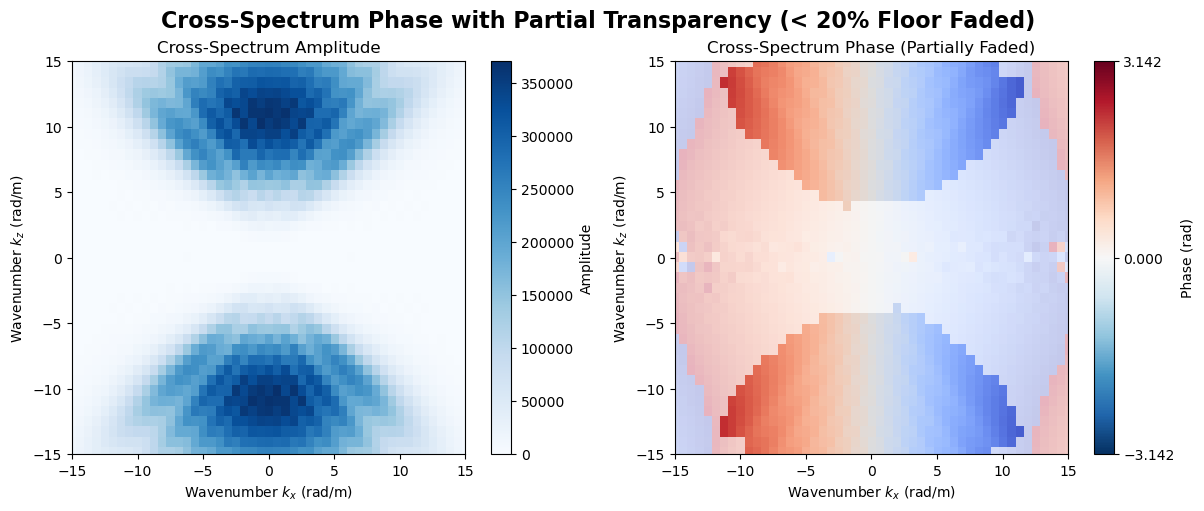

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
v = 0.1                      # Velocity (m/ns)
f_c = 0.1                    # Center frequency (GHz)
wavelength = v / f_c         # Dominant Wavelength (m) -> 1.0 m

nx, nz = 400, 400
x_start, x_end = 0, 10
z_start, z_end = 0, 8
x_pos = np.linspace(x_start, x_end, nx)
z_pos = np.linspace(z_start, z_end, nz)
dx = x_pos[1] - x_pos[0]
dz = z_pos[1] - z_pos[0]

t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)
dt = time_axis[1] - time_axis[0]

x_base = 5.0
z_target = 4.0
final_shift = 0.25 * wavelength # Final shift of 0.25 lambda

# Gazdag Migration Precomputation
v_mig = v / 2  
pad_t = nt
pad_x = nx // 2
nt_pad = nt + pad_t
nx_pad = nx + (2 * pad_x)

freqs = np.fft.fftfreq(nt_pad, d=dt)
kxs = np.fft.fftfreq(nx_pad, d=dx)
KX, F = np.meshgrid(kxs, freqs)
omega = 2 * np.pi * F
kx = 2 * np.pi * KX
kz_sq = (omega / v_mig)**2 - kx**2
kz = np.where(kz_sq >= 0, np.sqrt(np.maximum(kz_sq, 0)), 0)
kz = np.sign(omega) * kz 

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def migrate_bscan(x_tgt):
    b_scan = np.zeros((nt, nx))
    for i, x in enumerate(x_pos):
        dist = np.sqrt((x - x_tgt)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
    
    b_padded = np.pad(b_scan, ((0, pad_t), (pad_x, pad_x)), mode='constant')
    P_fk = np.fft.fft2(b_padded)
    migrated = np.zeros((nz, nx))
    for iz, z in enumerate(z_pos):
        migrated[iz, :] = np.real(np.fft.ifft2(P_fk * np.exp(1j * kz * z)))[0, pad_x:pad_x+nx]
    return migrated

# Precompute baseline and final monitor migrated images
mig_base = migrate_bscan(x_base)
mig_mon = migrate_bscan(x_base + final_shift)

# ==========================================
# 2. 2D Fourier Transform & Cross-Spectrum
# ==========================================
F_base = np.fft.fft2(mig_base)
F_mon = np.fft.fft2(mig_mon)

cross_spectrum = F_mon * np.conj(F_base)
cross_amplitude = np.abs(cross_spectrum)
cross_phase = np.angle(cross_spectrum)

cross_amplitude_shifted = np.fft.fftshift(cross_amplitude)
cross_phase_shifted = np.fft.fftshift(cross_phase)

# ==========================================
# 3. Create Partially Transparent Phase Map
# ==========================================
amp_threshold = 0.20 * np.max(cross_amplitude_shifted)

# Normalize phase from [-pi, pi] to [0, 1] for colormap mapping
norm_phase = (cross_phase_shifted + np.pi) / (2 * np.pi)
cmap_phase = plt.get_cmap('coolwarm')
rgba_phase = cmap_phase(norm_phase) # Generates an (H, W, 4) RGBA array

# Modify the alpha (transparency) channel based on the threshold
# Valid high-amplitude regions get alpha = 1.0 (fully opaque)
# Low-amplitude regions get alpha = 0.2 (partially transparent/faded)
alpha_channel = np.where(cross_amplitude_shifted >= amp_threshold, 1.0, 0.3)
rgba_phase[..., 3] = alpha_channel

# Wavenumber axes (rad/m)
kx_axis = np.fft.fftshift(np.fft.fftfreq(nx, d=dx)) * 2 * np.pi
kz_axis = np.fft.fftshift(np.fft.fftfreq(nz, d=dz)) * 2 * np.pi
extent_k = [kx_axis.min(), kx_axis.max(), kz_axis.min(), kz_axis.max()]
zoom_k = 15

# ==========================================
# 4. Figure: Amplitude & Partially Faded Phase
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle('Cross-Spectrum Phase with Partial Transparency (< 20% Floor Faded)', fontsize=16, fontweight='bold')

ax1.set_title('Cross-Spectrum Amplitude')
ax1.set_xlabel('Wavenumber $k_x$ (rad/m)')
ax1.set_ylabel('Wavenumber $k_z$ (rad/m)')
ax1.set_xlim(-zoom_k, zoom_k)
ax1.set_ylim(-zoom_k, zoom_k)
im1 = ax1.imshow(cross_amplitude_shifted, extent=extent_k, origin='lower', cmap='Blues')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label='Amplitude')

ax2.set_title('Cross-Spectrum Phase (Partially Faded)')
ax2.set_xlabel('Wavenumber $k_x$ (rad/m)')
ax2.set_ylabel('Wavenumber $k_z$ (rad/m)')
ax2.set_xlim(-zoom_k, zoom_k)
ax2.set_ylim(-zoom_k, zoom_k)

# Display the custom RGBA array directly
im2 = ax2.imshow(rgba_phase, extent=extent_k, origin='lower')
sm = ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=-np.pi, vmax=np.pi))
sm.set_array([])
fig.colorbar(sm, ax=ax2, fraction=0.046, pad=0.04, label='Phase (rad)', ticks=[-np.pi, 0, np.pi])

plt.show()

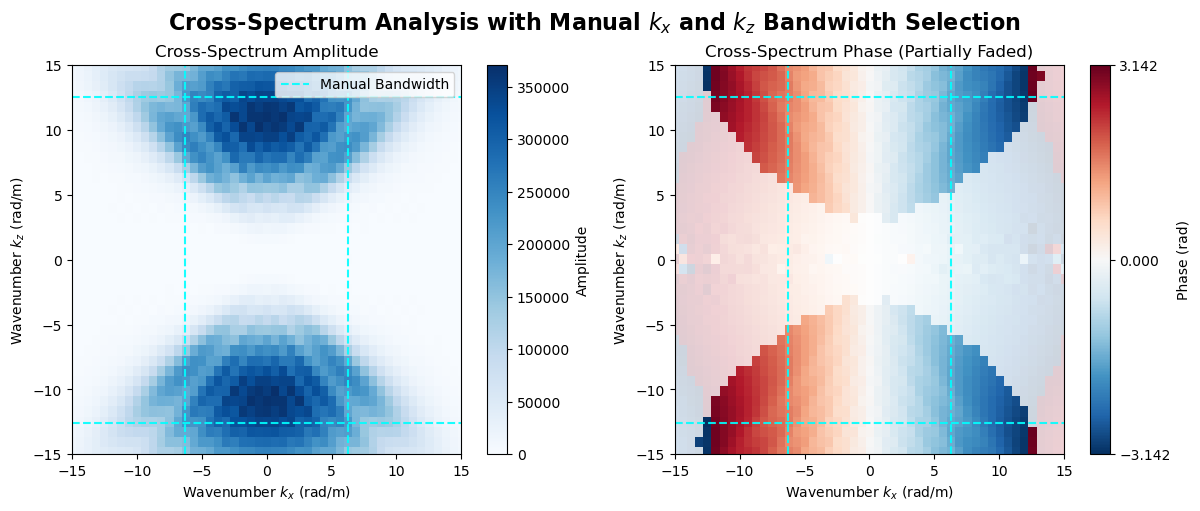

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Setup Parameters & Physics
# ==========================================
v = 0.1                      # Velocity (m/ns)
f_c = 0.1                    # Center frequency (GHz)
wavelength = v / f_c         # Dominant Wavelength (m) -> 1.0 m
k_center = 2 * np.pi / wavelength  # Central wavenumber (~6.28 rad/m)

nx, nz = 400, 400
x_start, x_end = 0, 10
z_start, z_end = 0, 8
x_pos = np.linspace(x_start, x_end, nx)
z_pos = np.linspace(z_start, z_end, nz)
dx = x_pos[1] - x_pos[0]
dz = z_pos[1] - z_pos[0]

t_max, nt = 160, 400
time_axis = np.linspace(0, t_max, nt)
dt = time_axis[1] - time_axis[0]

x_base = 5.0
z_target = 4.0
final_shift = 0.25 * wavelength # Final shift of 0.25 lambda

# Gazdag Migration Precomputation
v_mig = v / 2  
pad_t = nt
pad_x = nx // 2
nt_pad = nt + pad_t
nx_pad = nx + (2 * pad_x)

freqs = np.fft.fftfreq(nt_pad, d=dt)
kxs = np.fft.fftfreq(nx_pad, d=dx)
KX, F = np.meshgrid(kxs, freqs)
omega = 2 * np.pi * F
kx = 2 * np.pi * KX
kz_sq = (omega / v_mig)**2 - kx**2
kz = np.where(kz_sq >= 0, np.sqrt(np.maximum(kz_sq, 0)), 0)
kz = np.sign(omega) * kz 

def ricker(t, f):
    return (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)

def migrate_bscan(x_tgt):
    b_scan = np.zeros((nt, nx))
    for i, x in enumerate(x_pos):
        dist = np.sqrt((x - x_tgt)**2 + z_target**2)
        b_scan[:, i] = ricker(time_axis - (2 * dist / v), f_c) * (z_target / dist)**2
    
    b_padded = np.pad(b_scan, ((0, pad_t), (pad_x, pad_x)), mode='constant')
    P_fk = np.fft.fft2(b_padded)
    migrated = np.zeros((nz, nx))
    for iz, z in enumerate(z_pos):
        migrated[iz, :] = np.real(np.fft.ifft2(P_fk * np.exp(1j * kz * z)))[0, pad_x:pad_x+nx]
    return migrated

# Precompute baseline and final monitor migrated images
mig_base = migrate_bscan(x_base)
mig_mon = migrate_bscan(x_base + final_shift)

# ==========================================
# 2. 2D Fourier Transform & Cross-Spectrum
# ==========================================
F_base = np.fft.fft2(mig_base)
F_mon = np.fft.fft2(mig_mon)

cross_spectrum = F_mon * np.conj(F_base)
cross_amplitude = np.abs(cross_spectrum)
cross_phase = np.angle(cross_spectrum)

cross_amplitude_shifted = np.fft.fftshift(cross_amplitude)
cross_phase_shifted = np.fft.fftshift(cross_phase)

# ==========================================
# 3. Create Partially Transparent Phase Map
# ==========================================
amp_threshold = 0.10 * np.max(cross_amplitude_shifted)

norm_phase = (cross_phase_shifted + np.pi) / (2 * np.pi)
cmap_phase = plt.get_cmap('RdBu_r')
rgba_phase = cmap_phase(norm_phase) 

alpha_channel = np.where(cross_amplitude_shifted >= amp_threshold, 1.0, 0.2)
rgba_phase[..., 3] = alpha_channel

# Wavenumber axes (rad/m)
kx_axis = np.fft.fftshift(np.fft.fftfreq(nx, d=dx)) * 2 * np.pi
kz_axis = np.fft.fftshift(np.fft.fftfreq(nz, d=dz)) * 2 * np.pi
extent_k = [kx_axis.min(), kx_axis.max(), kz_axis.min(), kz_axis.max()]
zoom_k = 15

# ==========================================
# 4. Manual Bandwidth Limits for X and Z directions
# ==========================================
kx_limit = k_center    # Bounds for lateral wavenumber (around kx = 0)
kz_max = k_center * 2    # Upper bound for vertical lobes

# ==========================================
# 5. Figure: Amplitude & Partially Faded Phase with Manual Boxes
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle('Cross-Spectrum Analysis with Manual $k_x$ and $k_z$ Bandwidth Selection', fontsize=16, fontweight='bold')

for ax, title, img_data in zip([ax1, ax2], 
                               ['Cross-Spectrum Amplitude', 'Cross-Spectrum Phase (Partially Faded)'], 
                               [cross_amplitude_shifted, rgba_phase]):
    ax.set_title(title)
    ax.set_xlabel('Wavenumber $k_x$ (rad/m)')
    ax.set_ylabel('Wavenumber $k_z$ (rad/m)')
    ax.set_xlim(-zoom_k, zoom_k)
    ax.set_ylim(-zoom_k, zoom_k)
    
    # Render image
    if img_data.ndim == 3:
        ax.imshow(img_data, extent=extent_k, origin='lower')
    else:
        im = ax.imshow(img_data, extent=extent_k, origin='lower', cmap='Blues')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Amplitude')

    # Draw Manual Bandwidth Box (Isolating lobes near kx=0 and kz=±10)
    # Vertical bounds for kx
    ax.axvline(-kx_limit, color='cyan', linestyle='--', linewidth=1.5, alpha=0.9, label='Manual Bandwidth')
    ax.axvline(kx_limit, color='cyan', linestyle='--', linewidth=1.5, alpha=0.9)
    
    # Horizontal bounds for positive and negative kz lobes (~±10)
    ax.axhline(kz_max, color='cyan', linestyle='--', linewidth=1.5, alpha=0.9)
    ax.axhline(-kz_max, color='cyan', linestyle='--', linewidth=1.5, alpha=0.9)

# Add colorbar for the phase plot manually
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=-np.pi, vmax=np.pi))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax2, fraction=0.046, pad=0.04, ticks=[-np.pi, 0, np.pi])
cbar.set_label('Phase (rad)')

ax1.legend(loc='upper right', fontsize=10)
plt.show()